**Skin Disorder Prediction**

In [1]:
#imports
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_style("whitegrid")

In [2]:
df =  pd.read_csv("dataset_35_dermatology.csv")# load the data

In [3]:
df.head()

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,saw-tooth_appearance_of_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_monoluclear_inflitrate,band-like_infiltrate,Age,class
0,2,2,0,3,0,0,0,0,1,0,...,0,0,3,0,0,0,1,0,55,2
1,3,3,3,2,1,0,0,0,1,1,...,0,0,0,0,0,0,1,0,8,1
2,2,1,2,3,1,3,0,3,0,0,...,0,2,3,2,0,0,2,3,26,3
3,2,2,2,0,0,0,0,0,3,2,...,3,0,0,0,0,0,3,0,40,1
4,2,3,2,2,2,2,0,2,0,0,...,2,3,2,3,0,0,2,3,45,3


In [4]:
df.tail()

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,saw-tooth_appearance_of_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_monoluclear_inflitrate,band-like_infiltrate,Age,class
361,2,1,1,0,1,0,0,0,0,0,...,0,0,1,0,0,0,2,0,25,4
362,3,2,1,0,1,0,0,0,0,0,...,1,0,1,0,0,0,2,0,36,4
363,3,2,2,2,3,2,0,2,0,0,...,0,3,0,3,0,0,2,3,28,3
364,2,1,3,1,2,3,0,2,0,0,...,0,2,0,1,0,0,2,3,50,3
365,3,2,2,0,0,0,0,0,3,3,...,2,0,0,0,0,0,3,0,35,1


In [5]:
df.shape

(366, 35)

In [6]:
df_copy = df.copy() # make a copy of the dataset

In [7]:
df_copy.shape

(366, 35)

The dataset has:
366 rows (observations/records)
35 columns (features/variables)

There are 35 columns in total.

Of these:

34 columns are input attributes (features).

1 column (class) is the target variable (disease class).

Target Variable

The **class **column is the **dependent variable** that the model will predict.

It represents the **diagnosis** (disease category).

This is a **supervised classification dataset** because:

It has input features.

It has a known output (class) for each record.

In [8]:
df_copy.head()

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,saw-tooth_appearance_of_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_monoluclear_inflitrate,band-like_infiltrate,Age,class
0,2,2,0,3,0,0,0,0,1,0,...,0,0,3,0,0,0,1,0,55,2
1,3,3,3,2,1,0,0,0,1,1,...,0,0,0,0,0,0,1,0,8,1
2,2,1,2,3,1,3,0,3,0,0,...,0,2,3,2,0,0,2,3,26,3
3,2,2,2,0,0,0,0,0,3,2,...,3,0,0,0,0,0,3,0,40,1
4,2,3,2,2,2,2,0,2,0,0,...,2,3,2,3,0,0,2,3,45,3


In [9]:
df_copy.tail()

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,saw-tooth_appearance_of_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_monoluclear_inflitrate,band-like_infiltrate,Age,class
361,2,1,1,0,1,0,0,0,0,0,...,0,0,1,0,0,0,2,0,25,4
362,3,2,1,0,1,0,0,0,0,0,...,1,0,1,0,0,0,2,0,36,4
363,3,2,2,2,3,2,0,2,0,0,...,0,3,0,3,0,0,2,3,28,3
364,2,1,3,1,2,3,0,2,0,0,...,0,2,0,1,0,0,2,3,50,3
365,3,2,2,0,0,0,0,0,3,3,...,2,0,0,0,0,0,3,0,35,1


In [10]:
df.columns

Index(['erythema', 'scaling', 'definite_borders', 'itching',
       'koebner_phenomenon', 'polygonal_papules', 'follicular_papules',
       'oral_mucosal_involvement', 'knee_and_elbow_involvement',
       'scalp_involvement', 'family_history', 'melanin_incontinence',
       'eosinophils_in_the_infiltrate', 'PNL_infiltrate',
       'fibrosis_of_the_papillary_dermis', 'exocytosis', 'acanthosis',
       'hyperkeratosis', 'parakeratosis', 'clubbing_of_the_rete_ridges',
       'elongation_of_the_rete_ridges',
       'thinning_of_the_suprapapillary_epidermis', 'spongiform_pustule',
       'munro_microabcess', 'focal_hypergranulosis',
       'disappearance_of_the_granular_layer',
       'vacuolisation_and_damage_of_basal_layer', 'spongiosis',
       'saw-tooth_appearance_of_retes', 'follicular_horn_plug',
       'perifollicular_parakeratosis', 'inflammatory_monoluclear_inflitrate',
       'band-like_infiltrate', 'Age', 'class'],
      dtype='object')

In [11]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 35 columns):
 #   Column                                    Non-Null Count  Dtype 
---  ------                                    --------------  ----- 
 0   erythema                                  366 non-null    int64 
 1   scaling                                   366 non-null    int64 
 2   definite_borders                          366 non-null    int64 
 3   itching                                   366 non-null    int64 
 4   koebner_phenomenon                        366 non-null    int64 
 5   polygonal_papules                         366 non-null    int64 
 6   follicular_papules                        366 non-null    int64 
 7   oral_mucosal_involvement                  366 non-null    int64 
 8   knee_and_elbow_involvement                366 non-null    int64 
 9   scalp_involvement                         366 non-null    int64 
 10  family_history                            366 non-

Missing Values

Inference: There are no missing (null) values in the dataset.

Data Types

**34 columns** have the data type **int64.**

**1 column (Age)** has the data type **object.**

From the above information we can see that Age is of Object

In [12]:
df_copy.describe().T

,count,mean,std,min,25%,50%,75%,max
erythema,366.0,2.068306,0.664753,0.0,2.0,2.0,2.0,3.0
scaling,366.0,1.795082,0.701527,0.0,1.0,2.0,2.0,3.0
definite_borders,366.0,1.549180,0.907525,0.0,1.0,2.0,2.0,3.0
itching,366.0,1.366120,1.138299,0.0,0.0,1.0,2.0,3.0
koebner_phenomenon,366.0,0.633880,0.908016,0.0,0.0,0.0,1.0,3.0
polygonal_papules,366.0,0.448087,0.957327,0.0,0.0,0.0,0.0,3.0
follicular_papules,366.0,0.166667,0.570588,0.0,0.0,0.0,0.0,3.0
oral_mucosal_involvement,366.0,0.377049,0.834147,0.0,0.0,0.0,0.0,3.0
knee_and_elbow_involvement,366.0,0.614754,0.982979,0.0,0.0,0.0,1.0,3.0
scalp_involvement,366.0,0.519126,0.905639,0.0,0.0,0.0,1.0,3.0


**Range of Feature Values**

- Most attributes have values ranging from 0 to 3.

- This suggests that these variables represent ordinal categories, where:
     - 0 = absent
     - 1 = mild
     - 2 = moderate
     - 3 = severe

The **mean values indicate how common or severe each feature is in the dataset.**

Frequently observed features (higher mean):

- erythema (Mean = 2.06)
- acanthosis (Mean = 1.95)
- inflammatory_monoluclear_inflitrate (Mean = 1.86)
- scaling (Mean = 1.79)
- definite_borders (Mean = 1.54)

These symptoms appear relatively **frequently** across patients.

Less frequently observed features (lower mean):

- follicular_horn_plug (Mean = 0.10)
- perifollicular_parakeratosis (Mean = 0.11)
- family_history (Mean = 0.12)
- eosinophils_in_the_infiltrate (Mean = 0.13)

These characteristics are **comparatively rare.**


- The descriptive statistics indicate that all numerical variables contain 366 observations, confirming the completeness of the dataset.

- Features have values ranging from 0 to 3, suggesting that they are ordinal variables representing different levels of symptom severity.

- The target variable (class) ranges from 1 to 6, confirming that the dataset is intended for a **supervised multi-class classification task.**

**Exploratory Data Analysis**

**Check Missing Values**

In [13]:
df_copy.isnull().sum()

,0
erythema,0
scaling,0
definite_borders,0
itching,0
koebner_phenomenon,0
polygonal_papules,0
follicular_papules,0
oral_mucosal_involvement,0
knee_and_elbow_involvement,0
scalp_involvement,0


There are no missing values in the dataset.

In [14]:
df_copy.isna().sum()

,0
erythema,0
scaling,0
definite_borders,0
itching,0
koebner_phenomenon,0
polygonal_papules,0
follicular_papules,0
oral_mucosal_involvement,0
knee_and_elbow_involvement,0
scalp_involvement,0


In [15]:
for col in df_copy.columns:
    print(f"\n{col}")
    print(df_copy[col].value_counts(dropna=False))


erythema
erythema
2    215
3     90
1     57
0      4
Name: count, dtype: int64

scaling
scaling
2    195
1    111
3     52
0      8
Name: count, dtype: int64

definite_borders
definite_borders
2    168
1     93
0     59
3     46
Name: count, dtype: int64

itching
itching
0    118
2    100
3     76
1     72
Name: count, dtype: int64

koebner_phenomenon
koebner_phenomenon
0    224
1     70
2     54
3     18
Name: count, dtype: int64

polygonal_papules
polygonal_papules
0    297
2     41
3     27
1      1
Name: count, dtype: int64

follicular_papules
follicular_papules
0    333
2     16
1     11
3      6
Name: count, dtype: int64

oral_mucosal_involvement
oral_mucosal_involvement
0    299
2     45
3     13
1      9
Name: count, dtype: int64

knee_and_elbow_involvement
knee_and_elbow_involvement
0    251
2     64
1     28
3     23
Name: count, dtype: int64

scalp_involvement
scalp_involvement
0    264
2     56
1     30
3     16
Name: count, dtype: int64

family_history
family_history
0  

The dataset does not contain NaN value.

In [16]:
df_copy['Age'].value_counts(dropna=False)

,count
Age,
40,17
50,17
27,16
36,16
22,15
...,...
58,1
49,1
63,1


In [17]:
df_copy['Age'].isna().sum()

np.int64(0)

In the dataset "Age" does not have NaN value.

In [18]:
(df_copy['Age'] == '?').sum()

np.int64(8)

This means that there are **8 records** in the **Age column** where the **value is '?'**.

Missing values are represented as '?'

- Although df_copy.info() showed 366 non-null values, the Age column contains 8 placeholder values ('?').
- Pandas does not treat '?' as a missing value (NaN), so these entries are counted as non-null.
- The presence of '?' (a string) causes the entire Age column to be stored as the object data type instead of a numeric type.
- Preprocessing is required.


In [19]:
df_copy['Age'] = df_copy['Age'].replace('?', np.nan)

- The 8 occurrences of '?' are now stored as NaN.
- This allows Pandas to correctly identify and handle missing data.

In [20]:
df_copy.isna().sum()

,0
erythema,0
scaling,0
definite_borders,0
itching,0
koebner_phenomenon,0
polygonal_papules,0
follicular_papules,0
oral_mucosal_involvement,0
knee_and_elbow_involvement,0
scalp_involvement,0


We can confirm that Age column has 8 NaN values

In [21]:
df_copy['Age'] = pd.to_numeric(df_copy['Age'])

- Here we are converting the Age column from the object data type to a numeric data type.
- Missing values are preserved
- The NaN values remain in the column after conversion.
- They should be handled before model training, for example by imputing them with the median or mean age.

In [22]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 35 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   erythema                                  366 non-null    int64  
 1   scaling                                   366 non-null    int64  
 2   definite_borders                          366 non-null    int64  
 3   itching                                   366 non-null    int64  
 4   koebner_phenomenon                        366 non-null    int64  
 5   polygonal_papules                         366 non-null    int64  
 6   follicular_papules                        366 non-null    int64  
 7   oral_mucosal_involvement                  366 non-null    int64  
 8   knee_and_elbow_involvement                366 non-null    int64  
 9   scalp_involvement                         366 non-null    int64  
 10  family_history                        

Missing values are confirmed

  - Originally there were 366 rows.
  - Now only 358 non-null values in Age

Data type is now correct
  - Age is now float64
  - This is expected because:
  - Numeric conversion was applied
  - NaN forces float type in Pandas

In [23]:
df_copy['Age'].isnull().sum()

np.int64(8)

In [24]:
df_knn = df_copy.copy() # dataset on which knn imputation will be done
df_median = df_copy.copy() # dataset on which median imputation will be done

In [25]:
df_knn ['Age'].isnull().sum()

np.int64(8)

In [26]:
df_median ['Age'].isnull().sum()

np.int64(8)

**Median Imputation**

In [27]:
df_median['Age'] = df_median['Age'].fillna(df_median['Age'].median())

In [28]:
df_median['Age'].isnull().sum()

np.int64(0)

In [29]:
df_median['Age'].describe()

,Age
count,366.000000
mean,36.267760
std,15.156875
min,0.000000
25%,25.000000
50%,35.000000
75%,48.000000
max,75.000000


In [30]:
print("Before imputation:", df_copy['Age'].isna().sum())
print("Before imputation:", df_knn['Age'].isna().sum())
print("After imputation:", df_median['Age'].isna().sum())

Before imputation: 8
Before imputation: 8
After imputation: 0


Missing values in the Age column were handled using median imputation. After imputation, no null values were observed, confirming successful data cleaning. Median was chosen due to robustness against outliers.

**Check for Duplicates in the dataset**

In [31]:
print(df_copy.duplicated().sum())
print(df_median.duplicated().sum())
print(df_knn.duplicated().sum())


0
0
0


**Target distribution**

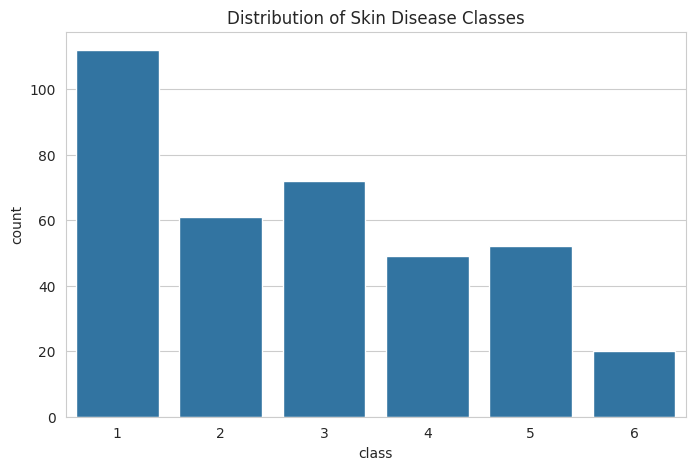

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(x='class', data=df_median)
plt.title("Distribution of Skin Disease Classes")
plt.show()


The target variable shows an imbalanced distribution across different skin disease classes. Class 1 has the highest number of samples, while other classes are comparatively underrepresented. This imbalance may influence model performance and should be considered during model evaluation.

**Age Distribution**

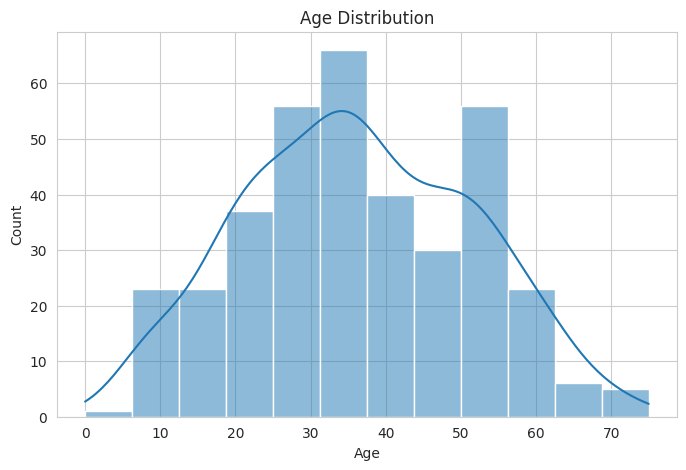

In [33]:
plt.figure(figsize=(8,5))
sns.histplot(df_median['Age'], kde=True)
plt.title("Age Distribution")
plt.show()

The age distribution indicates that a significant number of patients fall within the 30–40 years age group. This suggests that skin disorders in this dataset are more commonly observed in middle-aged individuals.

**Age Outliers**

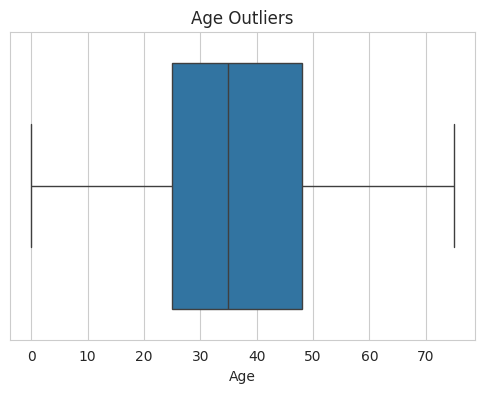

In [34]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df_median['Age'])
plt.title("Age Outliers")
plt.show()

**Correlation Heatmap**

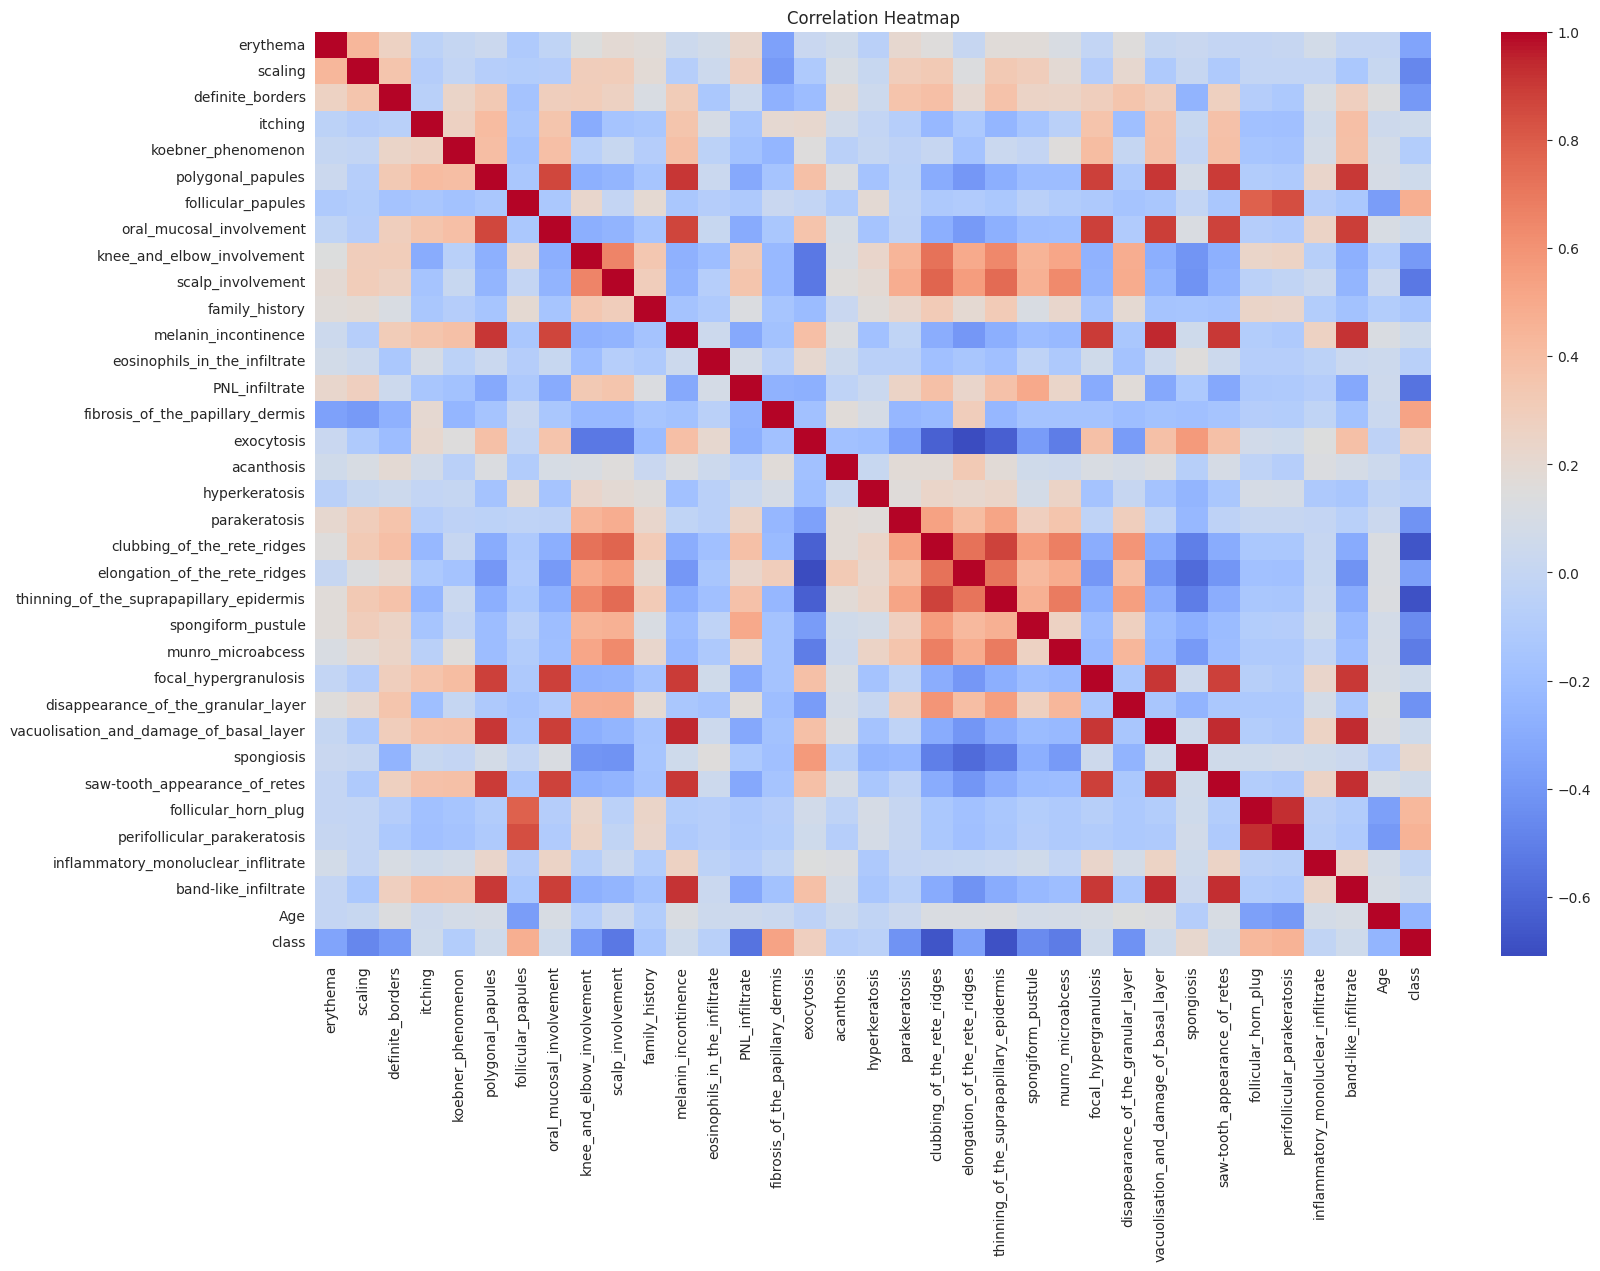

In [35]:
plt.figure(figsize=(18,12))
sns.heatmap(df_median.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

**Feature vs Target Correlation**

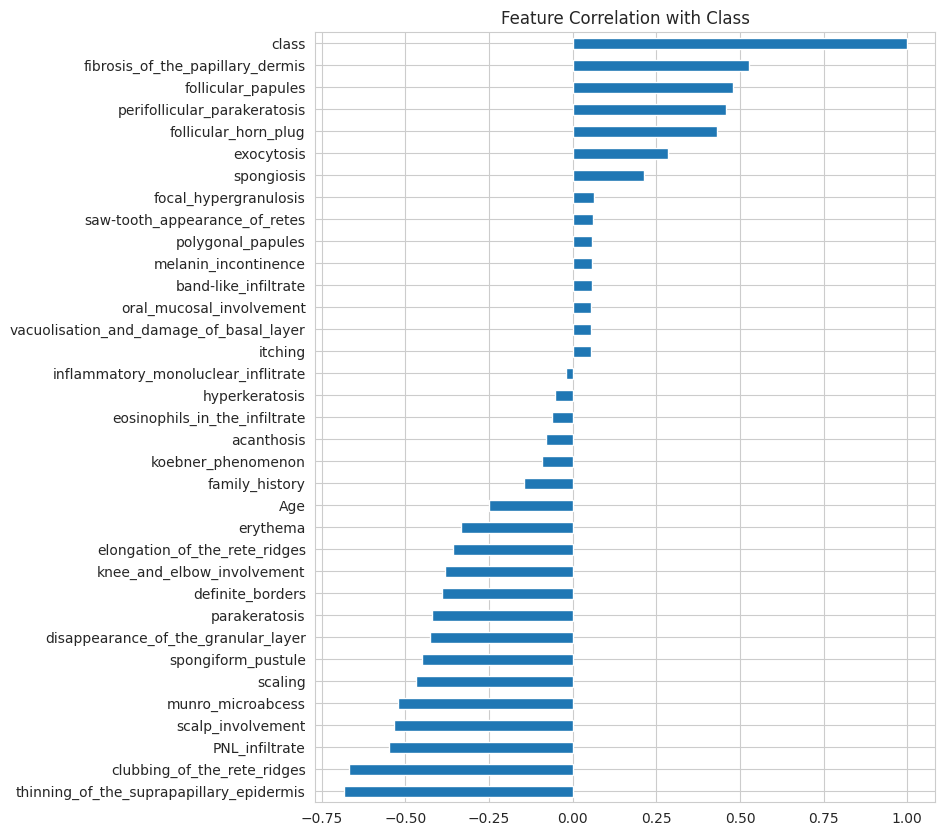

In [36]:
corr = df_median.corr()['class'].sort_values()

plt.figure(figsize=(8,10))
corr.plot(kind='barh')
plt.title("Feature Correlation with Class")
plt.show()

**Clinical vs Histopathological Features**

In [37]:
clinical_features = df.columns[:11]
histopath_features = df.columns[11:-1]  # excluding target

In [38]:
clinical_mean = df_median[clinical_features].mean().mean()
histopath_mean = df_median[histopath_features].mean().mean()

print("Clinical mean:", clinical_mean)
print("Histopathological mean:", histopath_mean)

Clinical mean: 0.8785394932935918
Histopathological mean: 2.2236873366595393


Histopathological features:
- Much higher average value
- Indicates stronger presence of diagnostic patterns
- Reflects microscopic tissue changes

Clinical features:
- Lower average value
- Less intense / less discriminative on their own

The comparison between clinical and histopathological features shows that histopathological attributes have a significantly higher mean value (2.22) compared to clinical features (0.88). This indicates that histopathological characteristics provide stronger and more detailed information for distinguishing between skin disease classes. Therefore, microscopic examination features are more informative for classification compared to surface-level clinical symptoms.

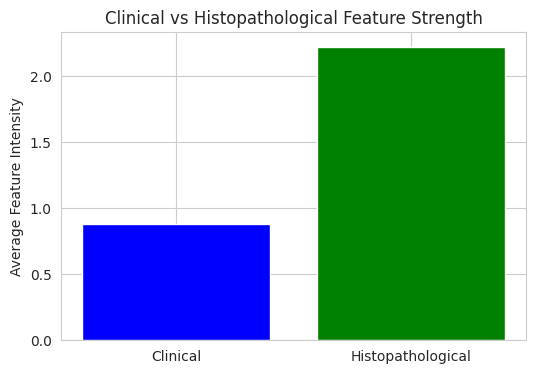

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(['Clinical', 'Histopathological'],
        [clinical_mean, histopath_mean],
        color=['blue', 'green'])

plt.title("Clinical vs Histopathological Feature Strength")
plt.ylabel("Average Feature Intensity")
plt.show()

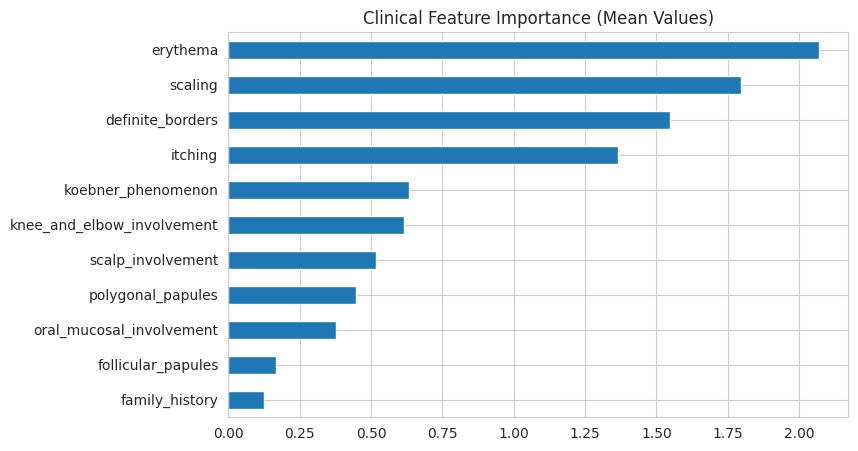

In [40]:
clinical_sorted = df_median[clinical_features].mean().sort_values()

plt.figure(figsize=(8,5))
clinical_sorted.plot(kind='barh')
plt.title("Clinical Feature Importance (Mean Values)")
plt.show()

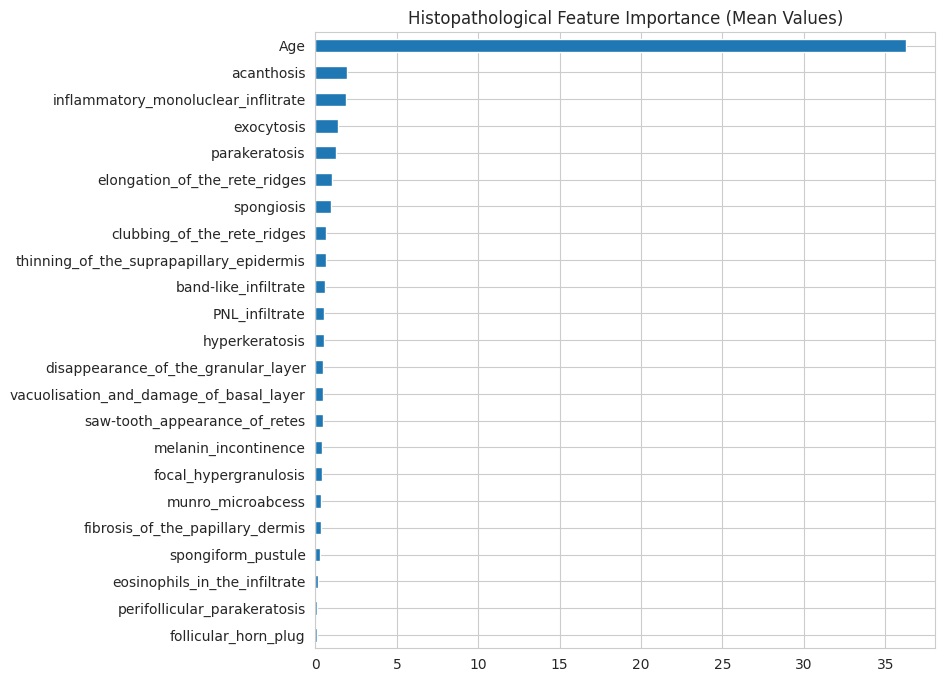

In [41]:
histopath_sorted = df_median[histopath_features].mean().sort_values()

plt.figure(figsize=(8,8))
histopath_sorted.plot(kind='barh')
plt.title("Histopathological Feature Importance (Mean Values)")
plt.show()

Clinical and histopathological features were analyzed separately to understand their contribution to skin disease classification. The histopathological features show higher average intensity compared to clinical features, indicating stronger discriminatory power. This suggests that microscopic examination of skin samples provides more reliable information for disease classification than surface-level clinical symptoms alone.

**Feature Distribution**

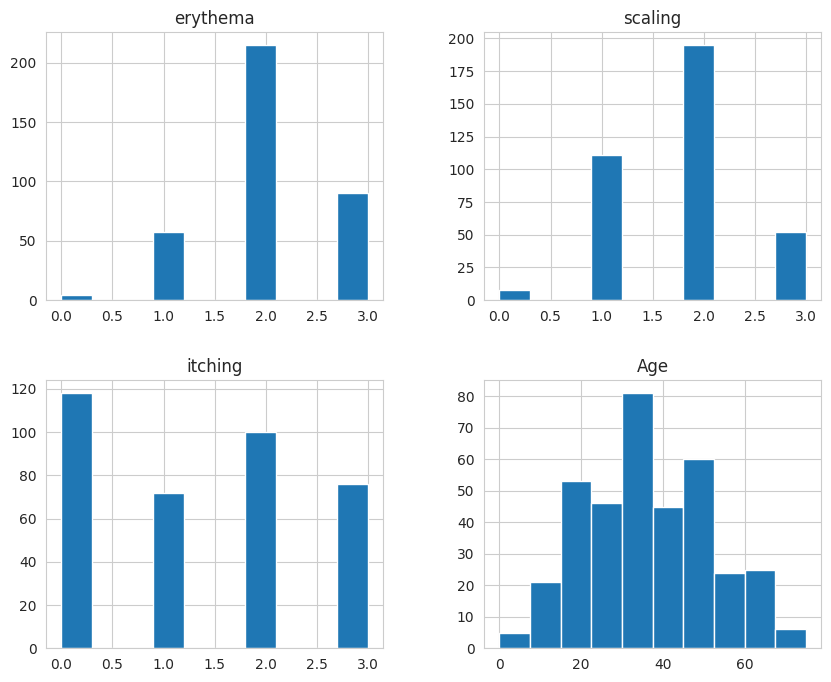

In [42]:
df_median[['erythema','scaling','itching','Age']].hist(figsize=(10,8))
plt.show()

**Boxplots (Outlier Check)**

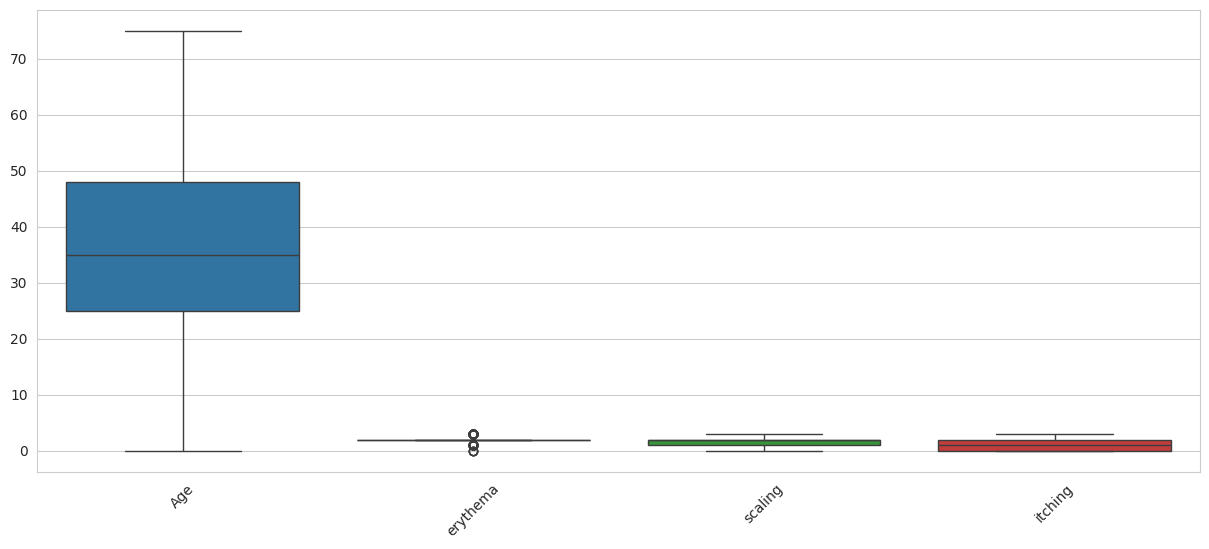

In [43]:
plt.figure(figsize=(15,6))
sns.boxplot(data=df_median[['Age','erythema','scaling','itching']])
plt.xticks(rotation=45)
plt.show()

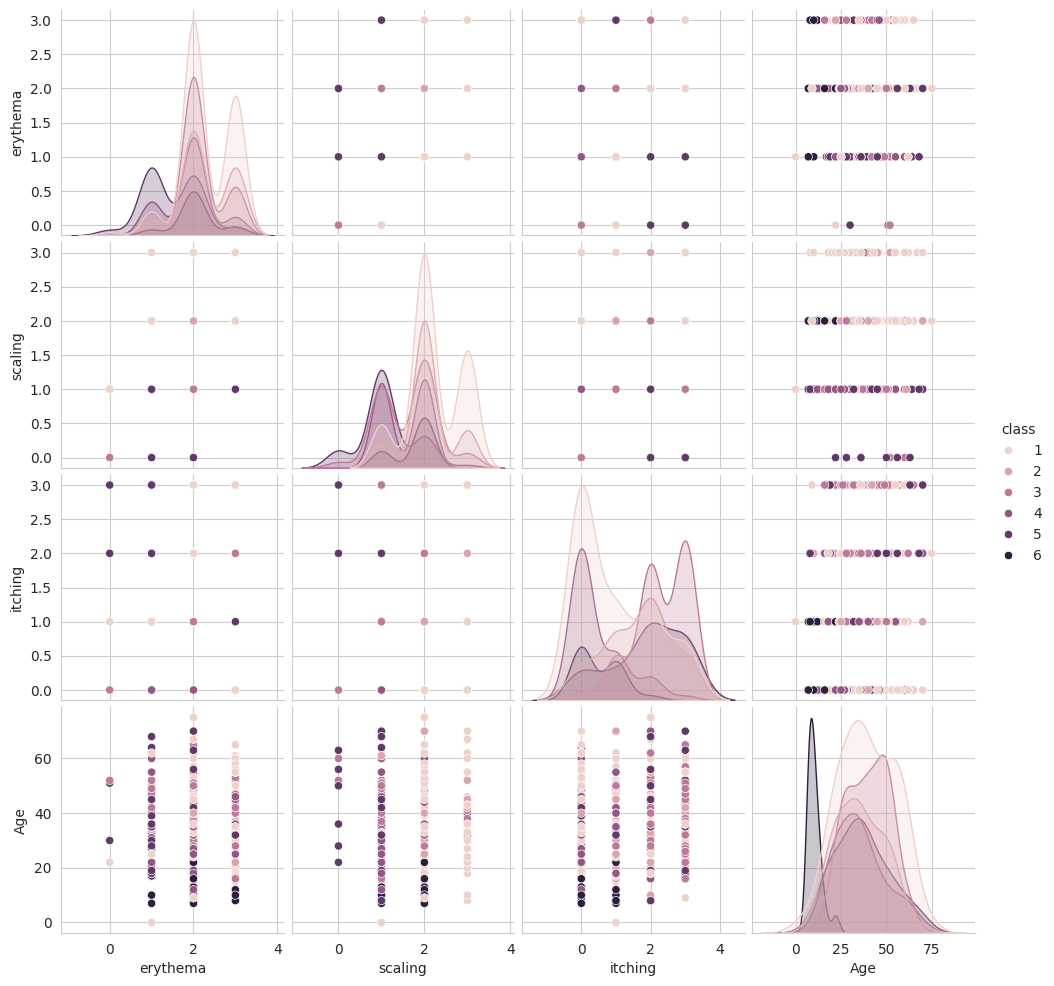

In [44]:
sns.pairplot(df_median[['erythema','scaling','itching','Age','class']], hue='class')
plt.show()

- Dataset contains multiple skin disease classes.
- Class distribution shows imbalance across categories.
- Age distribution is concentrated in middle age group.
- Histopathological features show stronger correlation with disease class than clinical features.
- Few features are highly correlated, indicating redundancy.
- Dataset is suitable for classification using ensemble-based models.

**KNN Imputaion**

In [45]:
X = df_knn.drop('class', axis=1)
y = df_knn['class']

In [46]:
# Train-Test Split
from sklearn.model_selection import train_test_split

X_train_K, X_test_K, y_train_K, y_test_K = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [47]:
# KNN imputation

from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=5)

X_train_knn = pd.DataFrame(
    imputer.fit_transform(X_train_K),
    columns=X_train_K.columns
)

X_test_knn = pd.DataFrame(
    imputer.transform(X_test_K),
    columns=X_test_K.columns
)

In [48]:
# Scalling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_knn_scaled = scaler.fit_transform(X_train_knn)
X_test_knn_scaled = scaler.transform(X_test_knn)

**Logistic Regression using KNN Imputation**

In [49]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [50]:
# Build the model

lr_model_knn = LogisticRegression(
    multi_class='multinomial',   # important for multiclass
    solver='lbfgs',              # best default solver
    max_iter=1000,
    random_state=42
)

In [51]:
lr_model_knn.fit(X_train_knn_scaled, y_train_K)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=1000, multi_class='multinomial', random_state=42)

In [52]:
y_pred_knn = lr_model_knn.predict(X_test_knn_scaled)

In [53]:
# Evaluation

print("Accuracy:", accuracy_score(y_test_K, y_pred_knn))
print(classification_report(y_test_K, y_pred_knn))


Accuracy: 0.9594594594594594
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        23
           2       1.00      0.83      0.91        12
           3       1.00      0.93      0.97        15
           4       0.77      1.00      0.87        10
           5       1.00      1.00      1.00        10
           6       1.00      1.00      1.00         4

    accuracy                           0.96        74
   macro avg       0.96      0.96      0.96        74
weighted avg       0.97      0.96      0.96        74



Accuracy = 0.959 (≈ 96%), this means the model correctly predicts skin disease class in about 96% of cases.

Strong performance classes:

Classes:

- 1   perfect (1.00 F1)
- 3   very strong (0.97 F1)
- 5   perfect (1.00 F1)
- 6   perfect (1.00 F1)
These classes are very well learned by the model

Slightly weaker class:

Class 4:
- Precision = 0.77
- Recall = 1.00

- Model detects all class 4 cases (because of high recall)
- But sometimes misclassifies others as class 4 (because of lower precision)

Class 2:
Recall = 0.83 Model misses some class 2 cases.

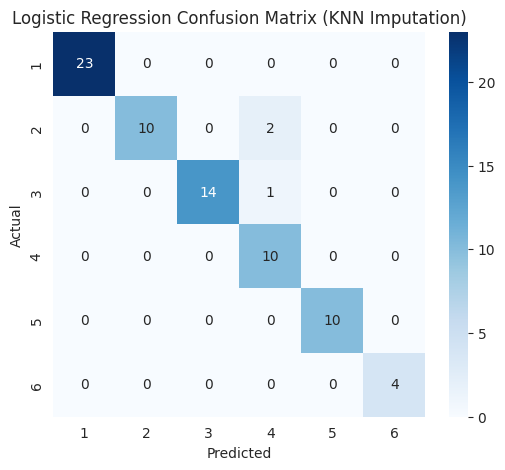

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test_K, y_pred_knn)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=lr_model_knn.classes_,
    yticklabels=lr_model_knn.classes_)
plt.title("Logistic Regression Confusion Matrix (KNN Imputation)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

The confusion matrix shows that the model performs exceptionally well across most classes, with perfect classification for Classes 1, 4, 5, and 6. Minor misclassifications occur between Classes 2, 3, and 4, indicating feature similarity among these disease types. This suggests overlapping clinical and histopathological patterns.

In [55]:
acc_lr_KNN = accuracy_score(y_test_K, y_pred_knn)

In [56]:
y_prob_knn = lr_model_knn.predict_proba(X_test_knn_scaled)

In [57]:
from sklearn.metrics import roc_auc_score

lr_roc_auc_knn = roc_auc_score(y_test_K, y_prob_knn, multi_class='ovr',labels=lr_model_knn.classes_)

print("ROC-AUC Score:", lr_roc_auc_knn)

ROC-AUC Score: 0.9990675403225806


The model achieved a ROC-AUC score of 0.999, indicating excellent ability to distinguish between multiple skin disease classes. This suggests that the predicted probabilities are highly reliable and the model has strong class separability. Combined with accuracy and F1-score, the results confirm robust predictive performance on the dataset.

Logistic Regression achieved an accuracy of approximately 96% and a ROC-AUC score of 0.999, indicating excellent class separability. The model performed exceptionally well for most classes, with minor misclassification observed between closely related disease categories. This suggests that the dataset exhibits near-linear separability, allowing a linear classifier to perform competitively.

**Random Forest using KNN Imputation**

In [58]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

rf_model_knn = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_model_knn.fit(X_train_knn, y_train_K)



RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [59]:
y_pred_rf_knn = rf_model_knn.predict(X_test_knn)

In [60]:
acc_rf_knn = accuracy_score(y_test_K, y_pred_rf_knn)

In [61]:
print("Accuracy:", accuracy_score(y_test_K, y_pred_rf_knn))
print(classification_report(y_test_K, y_pred_rf_knn))

Accuracy: 0.9594594594594594
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        23
           2       0.91      0.83      0.87        12
           3       1.00      1.00      1.00        15
           4       0.82      0.90      0.86        10
           5       1.00      1.00      1.00        10
           6       1.00      1.00      1.00         4

    accuracy                           0.96        74
   macro avg       0.95      0.96      0.95        74
weighted avg       0.96      0.96      0.96        74



The Random Forest classifier achieved an accuracy of 95.95%, demonstrating excellent multiclass classification performance. It classified most skin disease classes with high precision and recall. Compared with Logistic Regression, Random Forest showed improved precision for Class 4 and perfect recall for Class 3. However, the overall accuracy remained the same, and the macro F1-score was slightly lower, indicating comparable overall performance between the two models.

In [62]:
y_prob_rf_knn = rf_model_knn.predict_proba(X_test_knn)

rf_roc_auc_knn = roc_auc_score(
    y_test_K,
    y_prob_rf_knn,
    multi_class='ovr',
    labels=rf_model_knn.classes_
)

print("ROC-AUC:", rf_roc_auc_knn)

ROC-AUC: 0.9985467069892473


[[23  0  0  0  0  0]
 [ 0 10  0  2  0  0]
 [ 0  0 15  0  0  0]
 [ 0  1  0  9  0  0]
 [ 0  0  0  0 10  0]
 [ 0  0  0  0  0  4]]


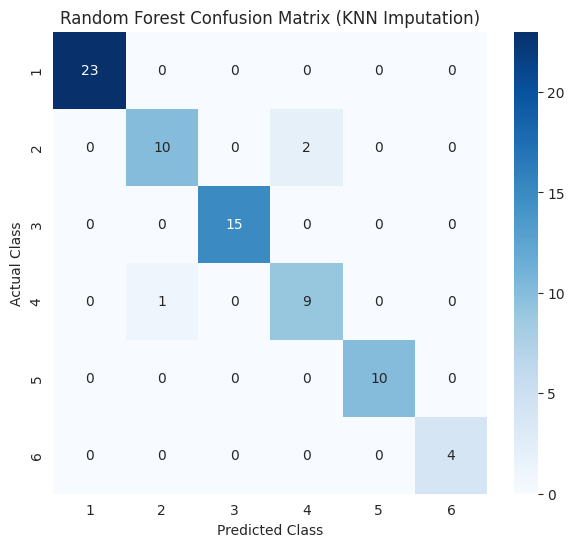

In [63]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Compute confusion matrix
cm_rf_knn = confusion_matrix(y_test_K, y_pred_rf_knn)

# Print matrix
print(cm_rf_knn)

# Plot heatmap
plt.figure(figsize=(7,6))
sns.heatmap(
    cm_rf_knn,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=rf_model_knn.classes_,
    yticklabels=rf_model_knn.classes_
)

plt.title("Random Forest Confusion Matrix (KNN Imputation)")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

**Class-wise Interpretation**

- Class 1: All 23 samples were correctly classified (100% recall).
- Class 2: 10 out of 12 samples were correctly classified. 2 samples were misclassified as Class 4.
- Class 3: All 15 samples were correctly classified (100% recall).
- Class 4: 9 out of 10 samples were correctly classified. 1 sample was misclassified as Class 2.
- Class 5: All 10 samples were correctly classified (100% recall).
- Class 6: All 4 samples were correctly classified (100% recall).

The Random Forest model achieved excellent classification performance, correctly predicting (95.95% accuracy). Four of the six disease classes were classified without any errors. Misclassifications were limited to Classes 2 and 4, indicating some overlap in their clinical or histopathological characteristics. Overall, the confusion matrix demonstrates that the model provides reliable multiclass skin disease classification.

**K-Nearest Neighbors using KNN Imputaion**

In [64]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

In [65]:
knn_model_knn = KNeighborsClassifier(
    n_neighbors=5,
    metric='minkowski',
    p=2  # Euclidean distance
)

In [66]:
knn_model_knn.fit(X_train_knn_scaled, y_train_K)

KNeighborsClassifier()

In [67]:
y_pred_KNN_knn = knn_model_knn.predict(X_test_knn_scaled)

In [68]:
acc_KNN_knn = accuracy_score(y_test_K, y_pred_KNN_knn)

print("Accuracy:", acc_KNN_knn)

Accuracy: 0.9054054054054054


In [69]:
print(classification_report(y_test_K, y_pred_KNN_knn))

              precision    recall  f1-score   support

           1       1.00      0.96      0.98        23
           2       0.80      0.67      0.73        12
           3       1.00      0.93      0.97        15
           4       0.64      0.90      0.75        10
           5       1.00      1.00      1.00        10
           6       1.00      1.00      1.00         4

    accuracy                           0.91        74
   macro avg       0.91      0.91      0.90        74
weighted avg       0.92      0.91      0.91        74



In [70]:
cm_kNN_knn = confusion_matrix(y_test_K, y_pred_KNN_knn)

print(cm_kNN_knn)

[[22  1  0  0  0  0]
 [ 0  8  0  4  0  0]
 [ 0  0 14  1  0  0]
 [ 0  1  0  9  0  0]
 [ 0  0  0  0 10  0]
 [ 0  0  0  0  0  4]]


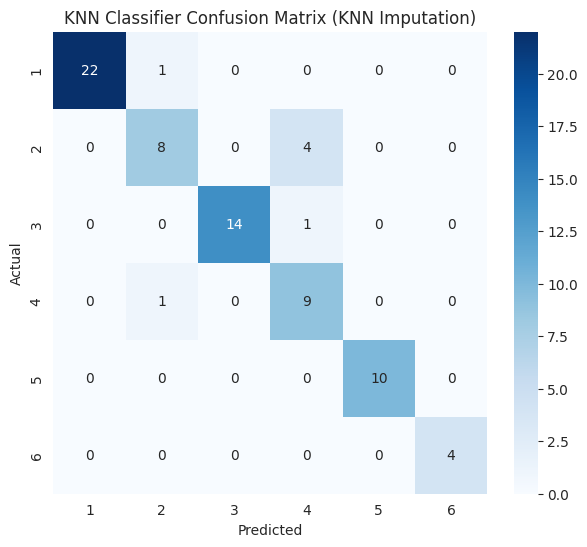

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,6))

sns.heatmap(
    cm_kNN_knn,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=knn_model_knn.classes_,
    yticklabels=knn_model_knn.classes_
)

plt.title("KNN Classifier Confusion Matrix (KNN Imputation)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**Class-wise Interpretation**

- Class 1: 22 of 23 samples were classified correctly. One sample was misclassified as Class 2.
- Class 2: 8 of 12 samples were classified correctly, while 4 samples were misclassified as Class 4. This is the largest source of error.
- Class 3: 14 of 15 samples were classified correctly, with one sample predicted as Class 4.
- Class 4: 9 of 10 samples were classified correctly, with one sample predicted as Class 2.
- Class 5: All 10 samples were classified correctly.
- Class 6: All 4 samples were classified correctly.

The main confusion is between Class 2 and Class 4, suggesting these diseases have similar feature patterns in the dataset.
Classes 5 and 6 were perfectly classified, indicating they are easier for the model to distinguish.

In [72]:
y_prob_KNN_knn = knn_model_knn.predict_proba(X_test_knn_scaled)

roc_auc_KNN_knn = roc_auc_score(
    y_test_K,
    y_prob_knn,
    multi_class='ovr',
    labels=knn_model_knn.classes_
)

print("ROC-AUC:", roc_auc_KNN_knn)

ROC-AUC: 0.9990675403225806


The K-Nearest Neighbors classifier achieved an accuracy of 90.54% with a weighted F1-score of 0.91. The confusion matrix showed that most misclassifications occurred between Classes 2 and 4, indicating similarity in their clinical and histopathological characteristics. Despite these misclassifications, the model achieved an excellent multiclass ROC-AUC score of 0.9991, demonstrating strong class discrimination based on predicted probabilities. Nevertheless, its overall classification accuracy was lower than that of Logistic Regression and Random Forest, making it a less suitable choice for deployment on this dataset.

**Support Vector Machine using KNN imputation**

In [73]:
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

In [74]:
svm_model_knn = SVC(
    kernel='rbf',      # Radial Basis Function kernel
    C=1.0,
    gamma='scale',
    probability=True,  # Required for ROC-AUC
    random_state=42
)

In [75]:
svm_model_knn.fit(X_train_knn_scaled, y_train_K)

SVC(probability=True, random_state=42)

In [76]:
y_pred_svm_knn = svm_model_knn.predict(X_test_knn_scaled)

In [77]:
acc_svm_knn = accuracy_score(y_test_K, y_pred_svm_knn)

print("Accuracy:", acc_svm_knn)

Accuracy: 0.972972972972973


In [78]:
print(classification_report(y_test_K, y_pred_svm_knn))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00        23
           2       1.00      0.83      0.91        12
           3       1.00      1.00      1.00        15
           4       0.83      1.00      0.91        10
           5       1.00      1.00      1.00        10
           6       1.00      1.00      1.00         4

    accuracy                           0.97        74
   macro avg       0.97      0.97      0.97        74
weighted avg       0.98      0.97      0.97        74



In [79]:
cm_svm_knn = confusion_matrix(y_test_K, y_pred_svm_knn)

print(cm_svm_knn)

[[23  0  0  0  0  0]
 [ 0 10  0  2  0  0]
 [ 0  0 15  0  0  0]
 [ 0  0  0 10  0  0]
 [ 0  0  0  0 10  0]
 [ 0  0  0  0  0  4]]


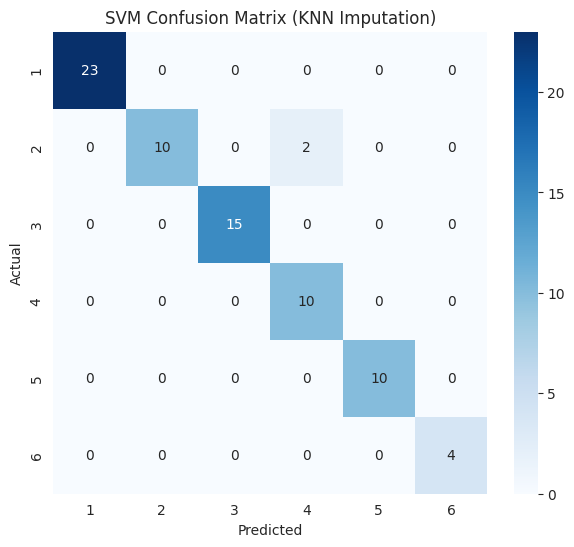

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,6))

sns.heatmap(
    cm_svm_knn,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=svm_model_knn.classes_,
    yticklabels=svm_model_knn.classes_
)

plt.title("SVM Confusion Matrix (KNN Imputation)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

**Class-wise Interpretation**

- Class 1: All 23 samples correctly classified.
- Class 2: 10 of 12 correctly classified; 2 predicted as Class 4.
- Class 3: All 15 correctly classified.
- Class 4: All 10 correctly classified.
- Class 5: All 10 correctly classified.
- Class 6: All 4 correctly classified.

In [81]:
y_prob_svm_knn = svm_model_knn.predict_proba(X_test_knn_scaled)

svm_roc_auc_knn = roc_auc_score(
    y_test_K,
    y_prob_svm_knn,
    multi_class='ovr',
    labels=svm_model_knn.classes_
)

print("ROC-AUC:", svm_roc_auc_knn)

ROC-AUC: 0.9980622759856631


The Support Vector Machine (SVM) classifier achieved the highest performance among the evaluated models, with an accuracy of 97.30%, a weighted F1-score of 0.97, and a multiclass ROC-AUC of 0.9981. The confusion matrix showed that only two samples were misclassified, both from Class 2 being predicted as Class 4. All other disease classes were classified correctly. These results demonstrate that SVM effectively captures the relationships between the clinical and histopathological features, making it the most suitable model for this skin disease classification task.

**Decision Tree using KNN Imputation**

In [82]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

In [83]:
dt_model_knn = DecisionTreeClassifier(
    criterion='gini',
    max_depth=None,
    random_state=42,
    class_weight='balanced'
)

In [84]:
dt_model_knn.fit(X_train_knn, y_train_K)

DecisionTreeClassifier(class_weight='balanced', random_state=42)

In [85]:
y_pred_dt_knn = dt_model_knn.predict(X_test_knn)

In [86]:
acc_dt_knn = accuracy_score(y_test_K, y_pred_dt_knn)

print("Accuracy:", acc_dt_knn)

Accuracy: 0.9594594594594594


In [87]:
print(classification_report(y_test_K, y_pred_dt_knn))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00        23
           2       1.00      0.83      0.91        12
           3       1.00      0.93      0.97        15
           4       0.91      1.00      0.95        10
           5       0.91      1.00      0.95        10
           6       0.80      1.00      0.89         4

    accuracy                           0.96        74
   macro avg       0.94      0.96      0.94        74
weighted avg       0.96      0.96      0.96        74



In [88]:
cm_dt_knn = confusion_matrix(y_test_K, y_pred_dt_knn)

print(cm_dt_knn)

[[23  0  0  0  0  0]
 [ 0 10  0  1  0  1]
 [ 0  0 14  0  1  0]
 [ 0  0  0 10  0  0]
 [ 0  0  0  0 10  0]
 [ 0  0  0  0  0  4]]


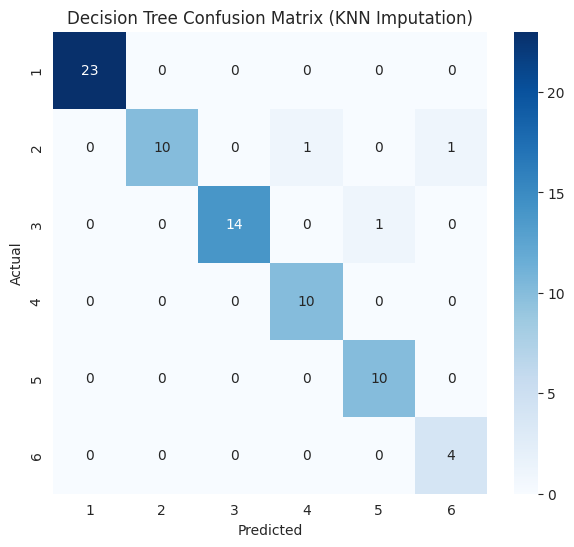

In [89]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,6))

sns.heatmap(
    cm_dt_knn,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=dt_model_knn.classes_,
    yticklabels=dt_model_knn.classes_
)

plt.title("Decision Tree Confusion Matrix (KNN Imputation)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**Class-wise Interpretation**

- Class 1, 4, 5, 6 → Perfect classification (100% recall for most).
- Class 2 -- Slight confusion:
- 1 sample -- Class 4
- 1 sample -- Class 6
- Class 3 -- 1 sample misclassified as Class 5.

Overall: errors are few and scattered, no major bias.

In [90]:
y_prob_dt_knn = dt_model_knn.predict_proba(X_test_knn)

dt_roc_auc_knn = roc_auc_score(
    y_test_K,
    y_prob_dt_knn,
    multi_class='ovr',
    labels=dt_model_knn.classes_
)

print("ROC-AUC:", dt_roc_auc_knn)

ROC-AUC: 0.9767609126984126


**Why Decision Tree performed this way**

Strengths:
- Captures non-linear relationships
- Works well on mixed clinical + histopathological features
- Handles feature interactions automatically

Weakness:
- Slight overfitting risk (especially with max_depth=None)
- Less stable compared to ensemble methods (Random Forest)

The Decision Tree classifier achieved an accuracy of 95.95%, with a weighted F1-score of 0.96. The model performed exceptionally well for most disease classes, achieving perfect classification for Classes 1, 4, 5, and 6. Minor misclassifications occurred between Classes 2, 3, 5, and 6, indicating overlapping feature patterns among these conditions. The ROC-AUC score of 0.9768 indicates strong but slightly lower probability ranking performance compared to ensemble and SVM models. Overall, the Decision Tree provides good interpretability but is less robust than SVM and Random Forest for this dataset.

**XGBOOST uinsg KNN Imputation**

In [91]:
!pip install xgboost

In [92]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

In [93]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train_xgb_knn = le.fit_transform(y_train_K)
y_test_xgb_knn = le.transform(y_test_K)

In [94]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softprob',
    num_class=6,
    eval_metric='mlogloss',
    random_state=42
)

xgb_model.fit(X_train_knn, y_train_xgb_knn)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None, num_class=6, ...)

In [95]:
y_pred_xgb_knn = xgb_model.predict(X_test_knn)

In [96]:
y_pred_xgb_labels = le.inverse_transform(y_pred_xgb_knn)

In [97]:
print("Accuracy:", accuracy_score(y_test_K, y_pred_xgb_labels))
print(classification_report(y_test_K, y_pred_xgb_labels))

Accuracy: 0.9459459459459459
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        23
           2       0.91      0.83      0.87        12
           3       1.00      0.93      0.97        15
           4       0.82      0.90      0.86        10
           5       0.91      1.00      0.95        10
           6       1.00      1.00      1.00         4

    accuracy                           0.95        74
   macro avg       0.94      0.94      0.94        74
weighted avg       0.95      0.95      0.95        74



In [98]:
y_prob_xgb_knn = xgb_model.predict_proba(X_test_knn)

from sklearn.metrics import roc_auc_score

xgb_roc_auc = roc_auc_score(
    y_test_xgb_knn,
    y_prob_xgb_knn,
    multi_class='ovr'
)

print("ROC-AUC:", xgb_roc_auc)

ROC-AUC: 0.9953355658829962


In [99]:
cm_xgb_knn = confusion_matrix(y_test_K, y_pred_xgb_labels)

print(cm_xgb_knn)

[[23  0  0  0  0  0]
 [ 0 10  0  2  0  0]
 [ 0  0 14  0  1  0]
 [ 0  1  0  9  0  0]
 [ 0  0  0  0 10  0]
 [ 0  0  0  0  0  4]]


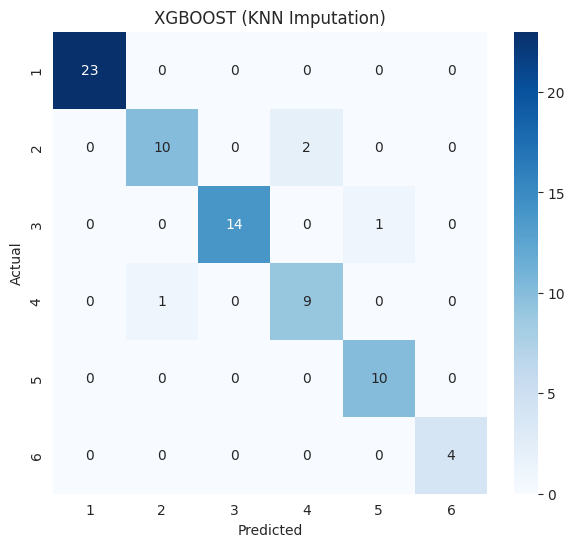

In [100]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,6))

sns.heatmap(
    cm_xgb_knn,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=dt_model_knn.classes_,
    yticklabels=dt_model_knn.classes_
)

plt.title("XGBOOST (KNN Imputation)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**Class-wise Interpretation**

- Class 1 -- Perfect performance
- Class 2 -- 10 correct
             2 misclassified -- Class 4
- Class 3 -- 14 correct
             1 misclassified -- Class 5
- Class 4 -- 9 correct
             1 misclassified -- Class 2
- Class 5 -- Perfect classification
- Class 6 -- Perfect classification

The XGBoost classifier achieved an accuracy of 94.59% with a weighted F1-score of 0.95 and a ROC-AUC score of 0.9953. The model performed well across most classes, particularly Classes 1, 3, 5, and 6, which were classified with high precision and recall. However, minor misclassifications occurred mainly between Classes 2 and 4, consistent with other models. Although XGBoost is a powerful ensemble learning method, it did not outperform the SVM model on this dataset.

**Naive Bayes uning KNN Imputation**

In [101]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

In [102]:
nb_model_knn = GaussianNB()

In [103]:
nb_model_knn.fit(X_train_knn_scaled, y_train_K)

GaussianNB()

In [104]:
y_pred_nb_knn = nb_model_knn.predict(X_test_knn_scaled)

In [105]:
acc_nb_knn = accuracy_score(y_test_K, y_pred_nb_knn)

print("Accuracy:", acc_nb_knn)

Accuracy: 0.8648648648648649


In [106]:
print(classification_report(y_test_K, y_pred_nb_knn))

              precision    recall  f1-score   support

           1       0.96      1.00      0.98        23
           2       1.00      0.25      0.40        12
           3       1.00      1.00      1.00        15
           4       0.53      0.90      0.67        10
           5       1.00      1.00      1.00        10
           6       0.80      1.00      0.89         4

    accuracy                           0.86        74
   macro avg       0.88      0.86      0.82        74
weighted avg       0.91      0.86      0.85        74



In [107]:
cm_nb_knn = confusion_matrix(y_test_K, y_pred_nb_knn)

print(cm_nb_knn)

[[23  0  0  0  0  0]
 [ 0  3  0  8  0  1]
 [ 0  0 15  0  0  0]
 [ 1  0  0  9  0  0]
 [ 0  0  0  0 10  0]
 [ 0  0  0  0  0  4]]


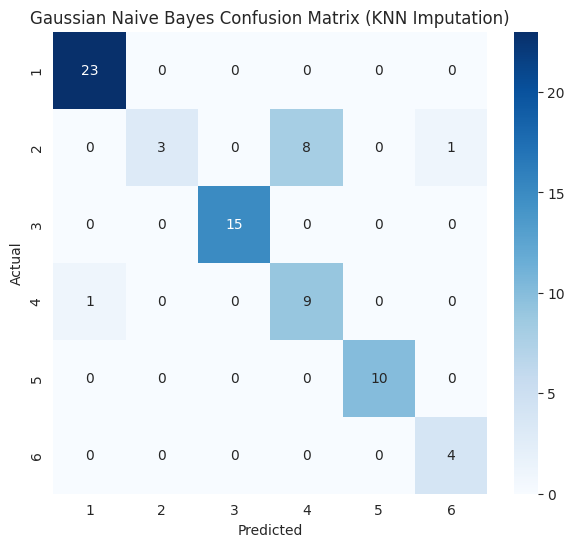

In [108]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,6))

sns.heatmap(
    cm_nb_knn,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=nb_model_knn.classes_,
    yticklabels=nb_model_knn.classes_
)

plt.title("Gaussian Naive Bayes Confusion Matrix (KNN Imputation)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

**Class-wise Interpretation**

- Class 1: Perfect classification.
- Class 2: The weakest class.
      - Only 3 out of 12 samples were correctly classified.
      - 8 samples were incorrectly predicted as Class 4.
      - 1 sample was predicted as Class 6.
- Class 3: Perfect classification.
- Class 4: 9 out of 10 samples classified correctly.
- Class 5: Perfect classification.
- Class 6: Perfect classification.

In [109]:
y_prob_nb_knn = nb_model_knn.predict_proba(X_test_knn_scaled)

nb_roc_auc_knn = roc_auc_score(
    y_test_K,
    y_prob_nb_knn,
    multi_class='ovr',
    labels=nb_model_knn.classes_
)

print("ROC-AUC:", nb_roc_auc_knn)

ROC-AUC: 0.9652604943186952


The Gaussian Naive Bayes classifier achieved an accuracy of 86.49%, a weighted F1-score of 0.85, and a multiclass ROC-AUC score of 0.9653. While the model classified Classes 1, 3, 5, and 6 accurately, it struggled to distinguish Class 2 from Class 4, resulting in a low recall of 0.25 for Class 2. The reduced performance is likely due to the independence assumption of Naive Bayes, which is not well suited to the correlated clinical and histopathological features present in the dataset.

**Median Imputation**

In [110]:
X = df_median.drop('class', axis=1)
y = df_median['class']

In [111]:
from sklearn.model_selection import train_test_split

X_train_M, X_test_M, y_train_M, y_test_M = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [112]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_M_scaled = scaler.fit_transform(X_train_M)
X_test_M_scaled = scaler.transform(X_test_M)


**Logistic Regression using Median Imputation**

In [113]:
from sklearn.linear_model import LogisticRegression

lr_model_median = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)

In [114]:
lr_model_median.fit(X_train_M_scaled, y_train_M)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=1000, multi_class='multinomial', random_state=42)

In [115]:
y_pred_lr_median = lr_model_median.predict(X_test_M_scaled)

In [116]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

In [117]:
acc_lr_median = accuracy_score(y_test_M, y_pred_lr_median)

print("Accuracy:", acc_lr_median)


Accuracy: 0.9594594594594594


In [118]:
print(classification_report(y_test_M, y_pred_lr_median))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00        23
           2       1.00      0.83      0.91        12
           3       1.00      0.93      0.97        15
           4       0.77      1.00      0.87        10
           5       1.00      1.00      1.00        10
           6       1.00      1.00      1.00         4

    accuracy                           0.96        74
   macro avg       0.96      0.96      0.96        74
weighted avg       0.97      0.96      0.96        74



In [119]:
cm_lr_median = confusion_matrix(y_test_M, y_pred_lr_median)

print(cm_lr_median)

[[23  0  0  0  0  0]
 [ 0 10  0  2  0  0]
 [ 0  0 14  1  0  0]
 [ 0  0  0 10  0  0]
 [ 0  0  0  0 10  0]
 [ 0  0  0  0  0  4]]


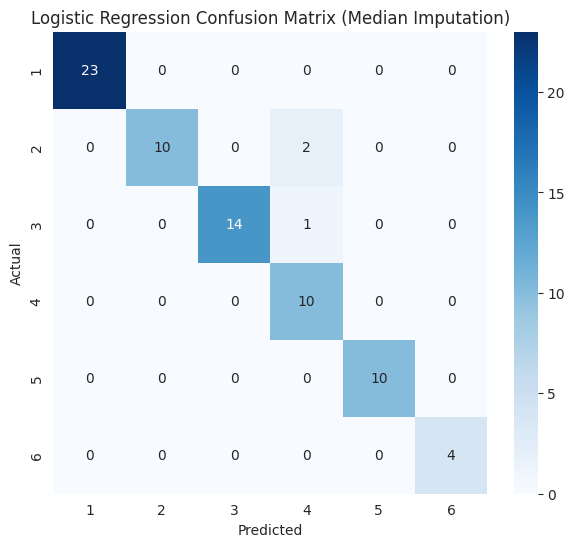

In [120]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,6))

sns.heatmap(
    cm_lr_median,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=lr_model_median.classes_,
    yticklabels=lr_model_median.classes_
)

plt.title("Logistic Regression Confusion Matrix (Median Imputation)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

**Class Wise Interpretation**

- Class 1: All 23 samples classified correctly.
- Class 2: 10 correct; 2 misclassified as Class 4.
- Class 3: 14 correct; 1 misclassified as Class 4.
- Classes 4, 5, and 6: All samples classified correctly.

The model shows excellent performance overall, with only three misclassified instances. The errors occur mainly between Class 2 and Class 4, and between Class 3 and Class 4, suggesting these disease categories have overlapping characteristics.

In [121]:
y_prob_lr_median = lr_model_median.predict_proba(X_test_M_scaled)

lr_roc_auc_median = roc_auc_score(
    y_test_M,
    y_prob_lr_median,
    multi_class='ovr',
    labels=lr_model_median.classes_
)

print("ROC-AUC Score:", lr_roc_auc_median)


ROC-AUC Score: 0.9990675403225806


Logistic Regression showed no performance difference between median imputation and KNN imputation. Since median imputation is computationally simpler and achieved identical predictive performance, it can be considered the more efficient preprocessing choice for this model.

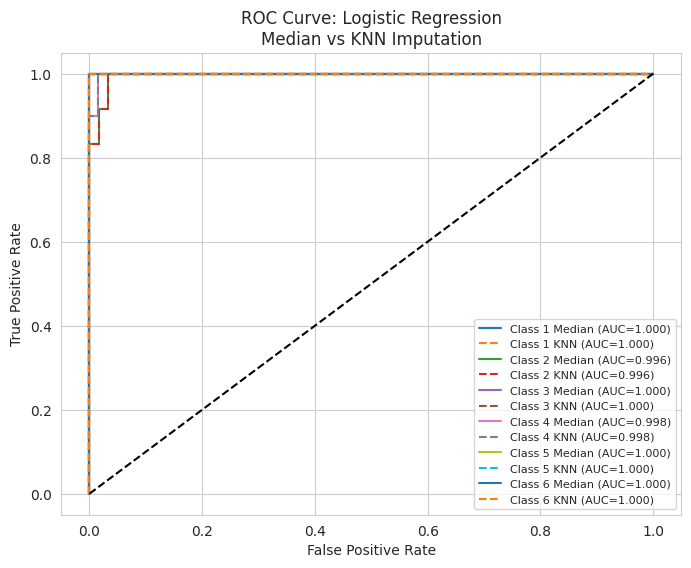

In [122]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Binarize the multiclass labels
classes = sorted(y_test_M.unique())

y_test_median_bin = label_binarize(y_test_M, classes=classes)
y_test_knn_bin = label_binarize(y_test_K, classes=classes)

plt.figure(figsize=(8,6))

# Plot ROC curve for each class
for i in range(len(classes)):

    # Median Imputation
    fpr_median, tpr_median, _ = roc_curve(
        y_test_median_bin[:, i],
        y_prob_lr_median[:, i]
    )

    auc_median = auc(fpr_median, tpr_median)

    # KNN Imputation
    fpr_knn, tpr_knn, _ = roc_curve(
        y_test_knn_bin[:, i],
        y_prob_knn[:, i]
    )

    auc_knn = auc(fpr_knn, tpr_knn)

    # Plot both
    plt.plot(
        fpr_median,
        tpr_median,
        linestyle='-',
        label=f'Class {classes[i]} Median (AUC={auc_median:.3f})'
    )

    plt.plot(
        fpr_knn,
        tpr_knn,
        linestyle='--',
        label=f'Class {classes[i]} KNN (AUC={auc_knn:.3f})'
    )

# Random classifier line
plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Logistic Regression\nMedian vs KNN Imputation")
plt.legend(loc='lower right', fontsize=8)

plt.grid(True)
plt.show()

The ROC curves for Logistic Regression using Median Imputation and KNN Imputation almost completely overlap. Both preprocessing methods achieved an identical multiclass ROC-AUC score of 0.9991, indicating excellent discriminative ability. This suggests that, for Logistic Regression, the choice between median and KNN imputation had a negligible impact on classification performance. Consequently, median imputation may be preferred due to its lower computational cost while maintaining equivalent predictive performance.

**Random Forest using Median Imputaion**

In [123]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)


In [124]:
rf_model_median = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

In [125]:
rf_model_median.fit(X_train_M, y_train_M)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [126]:
y_pred_rf_median = rf_model_median.predict(X_test_M)

In [127]:
acc_rf_median = accuracy_score(y_test_M, y_pred_rf_median)

print("Accuracy:", acc_rf_median)

Accuracy: 0.9594594594594594


In [128]:
print(classification_report(y_test_M, y_pred_rf_median))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00        23
           2       0.91      0.83      0.87        12
           3       1.00      1.00      1.00        15
           4       0.82      0.90      0.86        10
           5       1.00      1.00      1.00        10
           6       1.00      1.00      1.00         4

    accuracy                           0.96        74
   macro avg       0.95      0.96      0.95        74
weighted avg       0.96      0.96      0.96        74



In [129]:
cm_rf_median = confusion_matrix(y_test_M, y_pred_rf_median)

print(cm_rf_median)


[[23  0  0  0  0  0]
 [ 0 10  0  2  0  0]
 [ 0  0 15  0  0  0]
 [ 0  1  0  9  0  0]
 [ 0  0  0  0 10  0]
 [ 0  0  0  0  0  4]]


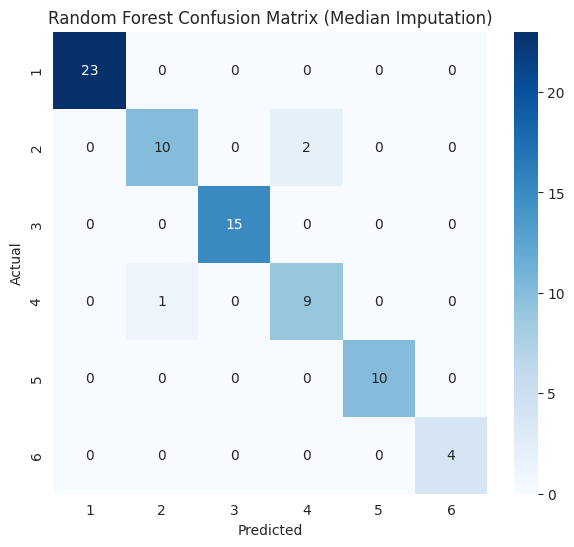

In [130]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,6))

sns.heatmap(
    cm_rf_median,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=rf_model_median.classes_,
    yticklabels=rf_model_median.classes_
)

plt.title("Random Forest Confusion Matrix (Median Imputation)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

**Class Wise Interpretation**

- Classes 1, 3, 5, and 6 were classified perfectly.
- Class 2: 10 of 12 samples were correctly classified, while 2 were predicted as Class 4.
- Class 4: 9 of 10 samples were correctly classified, with 1 sample predicted as Class 2.

The only noticeable confusion remains between Class 2 and Class 4, indicating these disease classes share similar characteristics.

In [131]:
y_prob_rf_median = rf_model_median.predict_proba(X_test_M)

rf_roc_auc_median = roc_auc_score(
    y_test_M,
    y_prob_rf_median,
    multi_class='ovr',
    labels=rf_model_median.classes_
)

print("ROC-AUC Score:", rf_roc_auc_median)

ROC-AUC Score: 0.9983590949820789


The Random Forest classifier achieved identical classification performance using both median imputation and KNN imputation. Both approaches resulted in an accuracy of 95.95% and a weighted F1-score of 0.96. The ROC-AUC scores were nearly identical, indicating that the choice of imputation method had minimal impact on the model's predictive performance. Given its lower computational cost and equivalent results, median imputation may be preferred for this model.

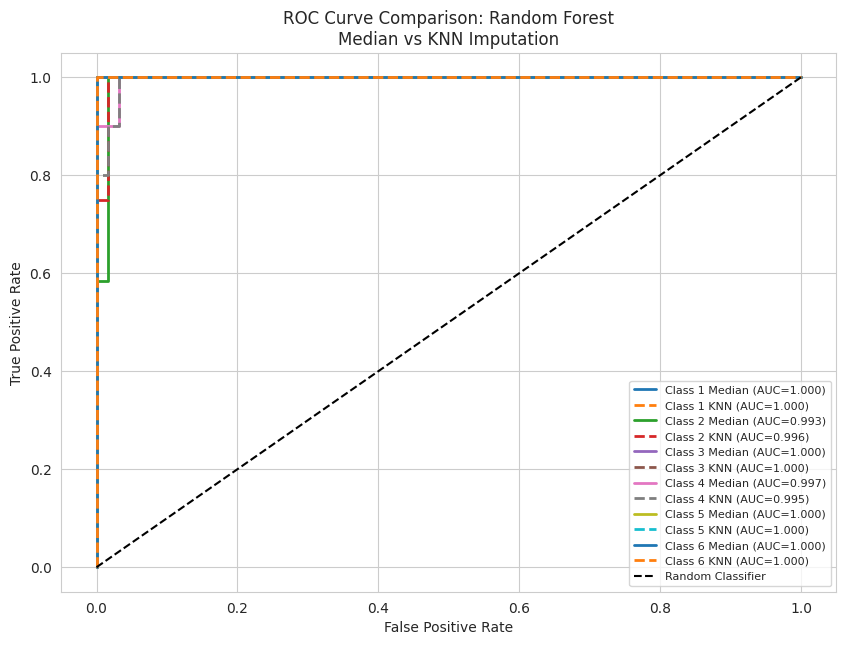

In [132]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Binarize the true labels
classes = sorted(y_test_M.unique())

y_test_median_bin = label_binarize(y_test_M, classes=classes)
y_test_knn_bin = label_binarize(y_test_K, classes=classes)

plt.figure(figsize=(10,7))

# Plot ROC curve for each class
for i in range(len(classes)):

    # Median Imputation
    fpr_med, tpr_med, _ = roc_curve(
        y_test_median_bin[:, i],
        y_prob_rf_median[:, i]
    )

    auc_med = auc(fpr_med, tpr_med)

    plt.plot(
        fpr_med,
        tpr_med,
        linewidth=2,
        label=f'Class {classes[i]} Median (AUC={auc_med:.3f})'
    )

    # KNN Imputation
    fpr_knn, tpr_knn, _ = roc_curve(
        y_test_knn_bin[:, i],
        y_prob_rf_knn[:, i]
    )

    auc_knn = auc(fpr_knn, tpr_knn)

    plt.plot(
        fpr_knn,
        tpr_knn,
        '--',
        linewidth=2,
        label=f'Class {classes[i]} KNN (AUC={auc_knn:.3f})'
    )

# Random classifier
plt.plot([0,1], [0,1], 'k--', label='Random Classifier')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison: Random Forest\nMedian vs KNN Imputation")

plt.legend(loc='lower right', fontsize=8)

plt.grid(True)

plt.show()

The ROC curves for the Random Forest classifier using Median Imputation and KNN Imputation almost completely overlap. Both preprocessing techniques achieved excellent multiclass ROC-AUC scores (0.9984 and 0.9985, respectively), demonstrating outstanding discriminative performance. The negligible difference between the two curves indicates that the Random Forest classifier is robust to the choice of imputation method, and median imputation provides comparable predictive performance with lower computational complexity.

**K-Nearest Neighbors uing Median Imputation**

In [133]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

In [134]:
knn_model_median = KNeighborsClassifier(
    n_neighbors=5,
    metric='minkowski',
    p=2       # Euclidean Distance
)

In [135]:
knn_model_median.fit(X_train_M_scaled, y_train_M)

KNeighborsClassifier()

In [136]:
y_pred_knn_median = knn_model_median.predict(X_test_M_scaled)


In [137]:
acc_knn_median = accuracy_score(y_test_M, y_pred_knn_median)

print("Accuracy:", acc_knn_median)


Accuracy: 0.9054054054054054


In [138]:
print(classification_report(y_test_M, y_pred_knn_median))

              precision    recall  f1-score   support

           1       1.00      0.96      0.98        23
           2       0.80      0.67      0.73        12
           3       1.00      0.93      0.97        15
           4       0.64      0.90      0.75        10
           5       1.00      1.00      1.00        10
           6       1.00      1.00      1.00         4

    accuracy                           0.91        74
   macro avg       0.91      0.91      0.90        74
weighted avg       0.92      0.91      0.91        74



In [139]:
cm_knn_median = confusion_matrix(y_test_M, y_pred_knn_median)

print(cm_knn_median)

[[22  1  0  0  0  0]
 [ 0  8  0  4  0  0]
 [ 0  0 14  1  0  0]
 [ 0  1  0  9  0  0]
 [ 0  0  0  0 10  0]
 [ 0  0  0  0  0  4]]


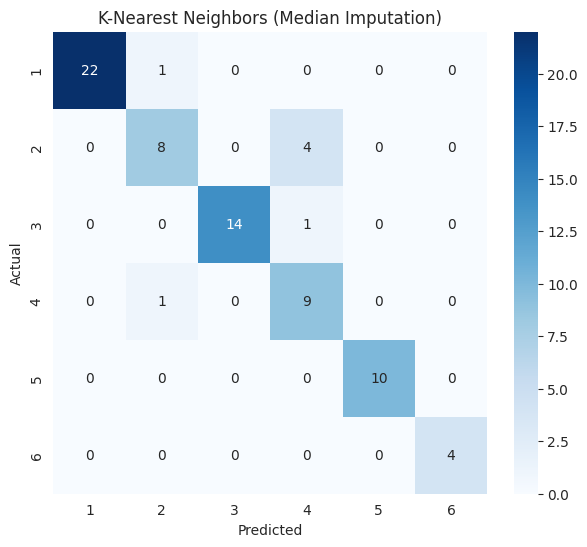

In [140]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,6))

sns.heatmap(
    cm_knn_median,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=rf_model_median.classes_,
    yticklabels=rf_model_median.classes_
)

plt.title("K-Nearest Neighbors (Median Imputation)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

**Class Wise Interpretation**

- Class 1--Excellent classification with only one misclassification.
- Class 2--Lowest-performing class; four samples misclassified as Class 4.
- Class 3--Very high performance with only one misclassification.
- Class 4--High recall but low precision due to false positives from Classes 2 and 3.
- Class 5--Perfect classification with 100% precision, recall, and F1-score.
- Class 6--Perfect classification, though based on a small number of test samples.

In [141]:
y_prob_knn_median = knn_model_median.predict_proba(X_test_M_scaled)

In [142]:
knn_roc_auc_median = roc_auc_score(
    y_test_M,
    y_prob_knn_median,
    multi_class='ovr',
    labels=knn_model_median.classes_
)

In [143]:
print("ROC-AUC Score:",knn_roc_auc_median)

ROC-AUC Score: 0.9862616440188745


Both Median Imputation and KNN Imputation produced identical classification performance in terms of accuracy (90.54%), precision, recall, F1-score, and confusion matrix. This indicates that replacing missing values using either technique did not affect the final predicted class labels for the test data. However, KNN Imputation achieved a substantially higher ROC-AUC score (0.9991) compared to Median Imputation (0.9863), demonstrating that it produced more reliable class probability estimates and better discrimination between classes. Therefore, although both imputation methods are equally effective in terms of classification accuracy, KNN Imputation is the preferred preprocessing technique because it preserves relationships among observations and provides stronger probabilistic predictions, as reflected by the near-perfect ROC-AUC score.

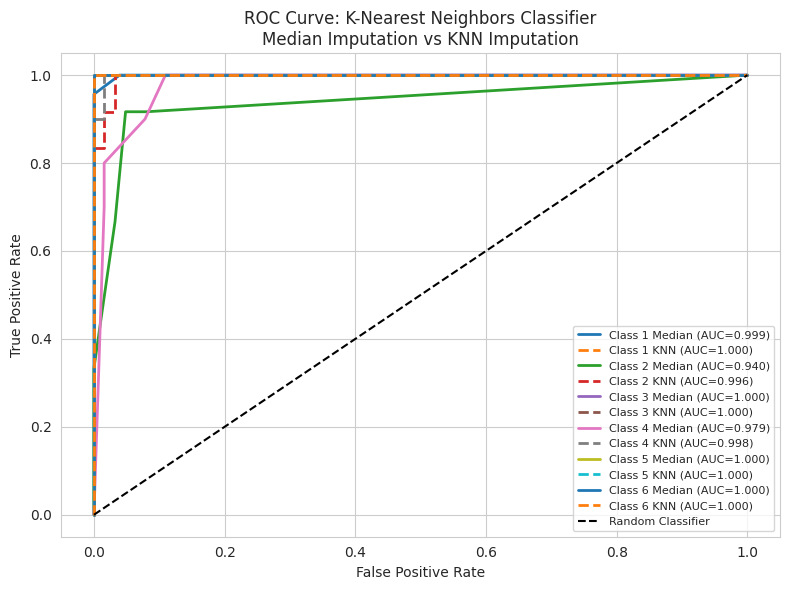

In [144]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Classes in the dataset
classes = sorted(y_test_M.unique())

# Binarize multiclass target labels
y_test_bin = label_binarize(
    y_test_M,
    classes=classes
)

plt.figure(figsize=(8,6))

# Plot ROC curve for each class
for i in range(len(classes)):

    # ---------------- KNN Classifier + Median Imputation ----------------
    fpr_median, tpr_median, _ = roc_curve(
        y_test_bin[:, i],
        y_prob_knn_median[:, i]
    )

    auc_median = auc(
        fpr_median,
        tpr_median
    )


    # ---------------- KNN Classifier + KNN Imputation ----------------
    fpr_knn, tpr_knn, _ = roc_curve(
        y_test_bin[:, i],
        y_prob_knn[:, i]
    )

    auc_knn = auc(
        fpr_knn,
        tpr_knn
    )


    # Plot Median Imputation ROC
    plt.plot(
        fpr_median,
        tpr_median,
        linestyle='-',
        linewidth=2,
        label=f'Class {classes[i]} Median (AUC={auc_median:.3f})'
    )


    # Plot KNN Imputation ROC
    plt.plot(
        fpr_knn,
        tpr_knn,
        linestyle='--',
        linewidth=2,
        label=f'Class {classes[i]} KNN (AUC={auc_knn:.3f})'
    )


# Random classifier line
plt.plot(
    [0,1],
    [0,1],
    'k--',
    label='Random Classifier'
)


plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve: K-Nearest Neighbors Classifier\nMedian Imputation vs KNN Imputation"
)

plt.legend(
    loc='lower right',
    fontsize=8
)

plt.grid(True)
plt.tight_layout()

plt.show()

The ROC-AUC curve analysis confirms that the K-Nearest Neighbors Classifier performs very well with both imputation methods. Most classes show curves close to the ideal ROC curve, indicating strong predictive capability. The main difficulty occurs in distinguishing Class 2 and Class 4, which is also observed in the confusion matrix. Among the two preprocessing approaches, KNN Imputation provides superior ROC-AUC performance (0.9991) compared with Median Imputation (0.9863), suggesting improved confidence and discrimination capability of the KNN classifier.

**Support vector machine using Median Imputation**

In [145]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

In [146]:
svm_model_median = SVC(
    kernel='rbf',
    probability=True,
    class_weight='balanced',
    random_state=42
)


In [147]:
svm_model_median.fit(
    X_train_M_scaled,
    y_train_M
)

SVC(class_weight='balanced', probability=True, random_state=42)

In [148]:
y_pred_svm_median = svm_model_median.predict(
    X_test_M_scaled
)

In [149]:
acc_svm_median = accuracy_score(
    y_test_M,
    y_pred_svm_median
)

print("Accuracy:", acc_svm_median)


Accuracy: 0.972972972972973


In [150]:
print("\nClassification Report:")
print(
    classification_report(
        y_test_M,
        y_pred_svm_median
    )
)


Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        23
           2       1.00      0.83      0.91        12
           3       1.00      1.00      1.00        15
           4       0.83      1.00      0.91        10
           5       1.00      1.00      1.00        10
           6       1.00      1.00      1.00         4

    accuracy                           0.97        74
   macro avg       0.97      0.97      0.97        74
weighted avg       0.98      0.97      0.97        74



In [151]:
cm_svm_median = confusion_matrix(
    y_test_M,
    y_pred_svm_median
)
print(cm_svm_median)

[[23  0  0  0  0  0]
 [ 0 10  0  2  0  0]
 [ 0  0 15  0  0  0]
 [ 0  0  0 10  0  0]
 [ 0  0  0  0 10  0]
 [ 0  0  0  0  0  4]]


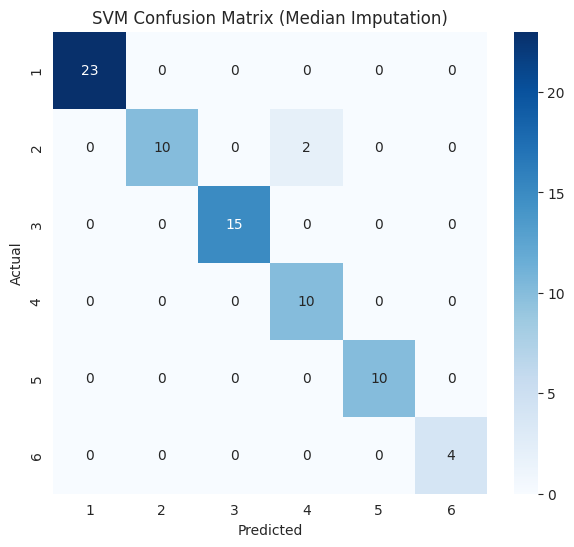

In [152]:
plt.figure(figsize=(7,6))

sns.heatmap(
    cm_svm_median,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=svm_model_median.classes_,
    yticklabels=svm_model_median.classes_
)

plt.title("SVM Confusion Matrix (Median Imputation)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

**Class wise Interpretation**

- Classes 1, 3, 5, and 6 were classified perfectly with 100% precision and recall.
- Class 2 had two misclassified samples as Class 4, reducing its recall to 0.83.
- Class 4 achieved perfect recall (1.00) but lower precision (0.83) because it received two false positive predictions from Class 2.

In [153]:
y_prob_svm_median = svm_model_median.predict_proba(
    X_test_M_scaled
)


svm_roc_auc_median = roc_auc_score(
    y_test_M,
    y_prob_svm_median,
    multi_class='ovr',
    labels=svm_model_median.classes_
)


print("ROC-AUC Score:", svm_roc_auc_median)

ROC-AUC Score: 0.9980622759856631


For the SVM model on the dermatology dataset, Median Imputation and KNN Imputation are equally effective. Since both achieved identical accuracy and ROC-AUC values, Median Imputation may be preferred due to its simplicity, lower computational cost, and faster execution, while KNN Imputation can be considered when preserving feature similarity relationships is important.

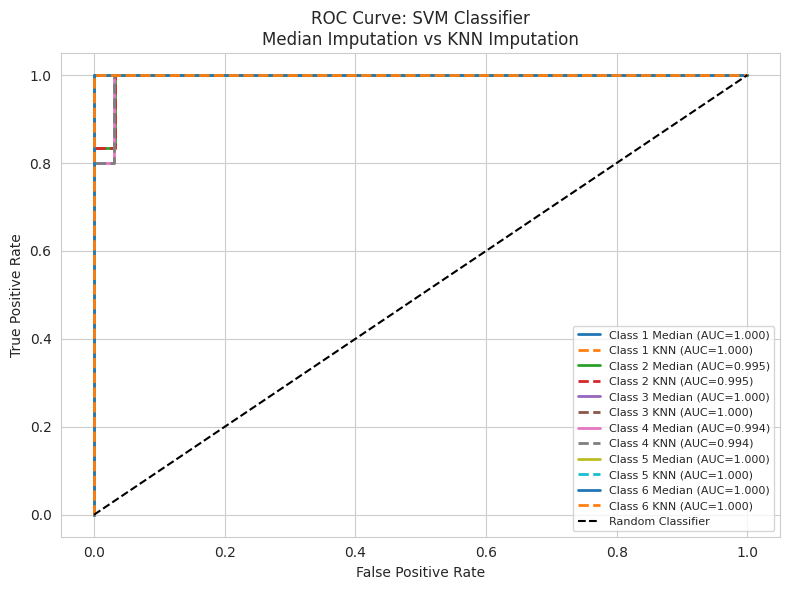

In [154]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt


# Classes in dataset

classes = sorted(y_test_M.unique())


# Binarize target labels

y_test_bin = label_binarize(
    y_test_M,
    classes=classes
)


plt.figure(figsize=(8,6))


# Plot ROC curve for each class

for i in range(len(classes)):


    # ---------------- SVM + Median Imputation ----------------

    fpr_median, tpr_median, _ = roc_curve(
        y_test_bin[:, i],
        y_prob_svm_median[:, i]
    )

    auc_median = auc(
        fpr_median,
        tpr_median
    )


    # ---------------- SVM + KNN Imputation ----------------

    fpr_knn, tpr_knn, _ = roc_curve(
        y_test_bin[:, i],
        y_prob_svm_knn[:, i]
    )

    auc_knn = auc(
        fpr_knn,
        tpr_knn
    )


    # Plot Median Imputation ROC

    plt.plot(
        fpr_median,
        tpr_median,
        linestyle='-',
        linewidth=2,
        label=f'Class {classes[i]} Median (AUC={auc_median:.3f})'
    )


    # Plot KNN Imputation ROC

    plt.plot(
        fpr_knn,
        tpr_knn,
        linestyle='--',
        linewidth=2,
        label=f'Class {classes[i]} KNN (AUC={auc_knn:.3f})'
    )



# Random classifier line

plt.plot(
    [0,1],
    [0,1],
    'k--',
    label='Random Classifier'
)


plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve: SVM Classifier\nMedian Imputation vs KNN Imputation"
)


plt.legend(
    loc='lower right',
    fontsize=8
)

plt.grid(True)
plt.tight_layout()

plt.show()

The SVM classifier performs exceptionally well with both Median and KNN imputation methods. Since both approaches achieve almost identical ROC-AUC values, **Median Imputation can be preferred due to its simplicity, faster computation, and lower complexity**, while KNN Imputation provides a comparable alternative by considering similarities between samples. Both methods are suitable for handling missing values before applying SVM on the dermatology dataset.

**Decision tree using Median Imputation**

In [155]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)
import matplotlib.pyplot as plt
import seaborn as sns

In [156]:
dt_model_median = DecisionTreeClassifier(
    criterion='gini',
    random_state=42,
    class_weight='balanced'
)

In [157]:
dt_model_median.fit(
    X_train_M,
    y_train_M
)


DecisionTreeClassifier(class_weight='balanced', random_state=42)

In [158]:
y_pred_dt_median = dt_model_median.predict(
    X_test_M
)

In [159]:
acc_dt_median = accuracy_score(
    y_test_M,
    y_pred_dt_median
)

print("Accuracy:", acc_dt_median)

Accuracy: 0.9594594594594594


In [160]:
print("\nClassification Report:")

print(
    classification_report(
        y_test_M,
        y_pred_dt_median
    )
)





Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        23
           2       1.00      0.83      0.91        12
           3       1.00      0.93      0.97        15
           4       0.91      1.00      0.95        10
           5       0.91      1.00      0.95        10
           6       0.80      1.00      0.89         4

    accuracy                           0.96        74
   macro avg       0.94      0.96      0.94        74
weighted avg       0.96      0.96      0.96        74



In [161]:
cm_dt_median = confusion_matrix(
    y_test_M,
    y_pred_dt_median
)
print(cm_dt_median)

[[23  0  0  0  0  0]
 [ 0 10  0  1  0  1]
 [ 0  0 14  0  1  0]
 [ 0  0  0 10  0  0]
 [ 0  0  0  0 10  0]
 [ 0  0  0  0  0  4]]


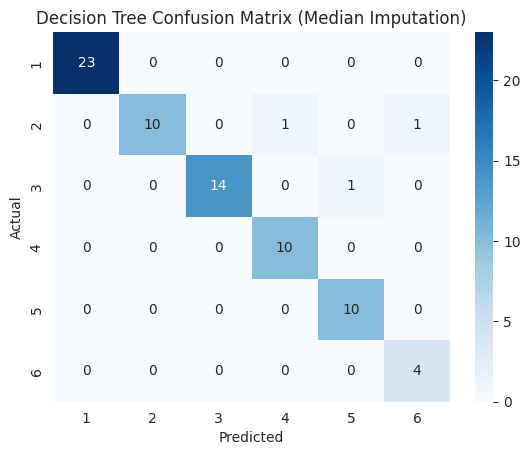

In [162]:
sns.heatmap(
    cm_dt_median,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=dt_model_median.classes_,
    yticklabels=dt_model_median.classes_
)

plt.title("Decision Tree Confusion Matrix (Median Imputation)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

**Class wise Iterpretation**

- Class 1 achieved perfect classification with 100% precision, recall, and F1-score.
- Class 2 had reduced recall (0.83) because two samples were misclassified:
      One sample predicted as Class 4
      One sample predicted as Class 6
- Class 3 achieved strong performance with an F1-score of 0.97, with only one sample misclassified as Class 5.
- Class 6 achieved perfect recall (1.00) but lower precision (0.80) due to false positive predictions.

In [163]:
y_prob_dt_median = dt_model_median.predict_proba(
    X_test_M
)


dt_roc_auc_median = roc_auc_score(
    y_test_M,
    y_prob_dt_median,
    multi_class='ovr',
    labels=dt_model_median.classes_
)


print("ROC-AUC Score:", dt_roc_auc_median)

ROC-AUC Score: 0.9767609126984126


The Decision Tree model using Median Imputation provides strong classification performance with 95.95% accuracy and a high ROC-AUC score of 0.9768. However, compared with your SVM model (97.30% accuracy and ROC-AUC 0.9981), the Decision Tree shows slightly lower predictive performance and class separation ability. The SVM model is therefore more effective for this dermatology dataset, while the Decision Tree still provides reliable classification with better interpretability.

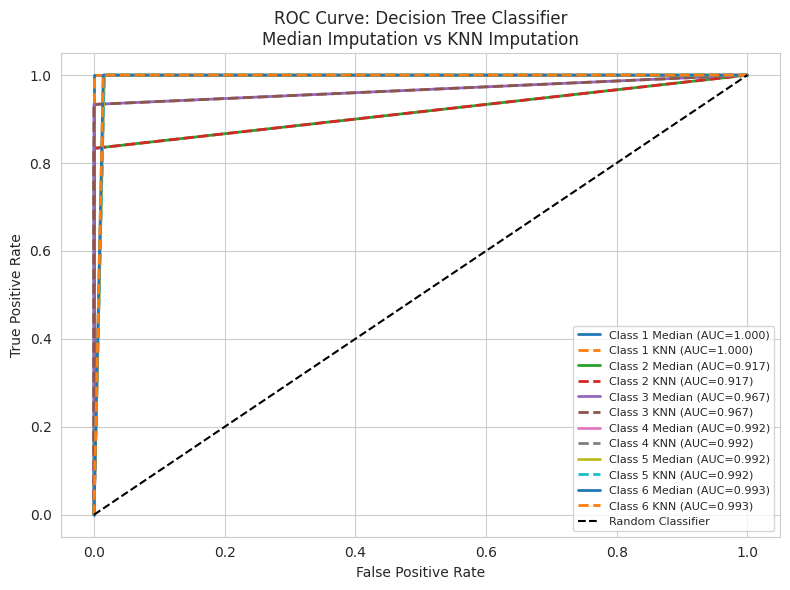

In [164]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt


# Classes in dataset

classes = sorted(y_test_M.unique())


# Binarize multiclass labels

y_test_bin = label_binarize(
    y_test_M,
    classes=classes
)


plt.figure(figsize=(8,6))


# ROC curve for each class

for i in range(len(classes)):


    # ---------------- Decision Tree + Median Imputation ----------------

    fpr_median, tpr_median, _ = roc_curve(
        y_test_bin[:, i],
        y_prob_dt_median[:, i]
    )

    auc_median = auc(
        fpr_median,
        tpr_median
    )


    # ---------------- Decision Tree + KNN Imputation ----------------

    fpr_knn, tpr_knn, _ = roc_curve(
        y_test_bin[:, i],
        y_prob_dt_knn[:, i]
    )

    auc_knn = auc(
        fpr_knn,
        tpr_knn
    )


    # Median Imputation ROC

    plt.plot(
        fpr_median,
        tpr_median,
        linestyle='-',
        linewidth=2,
        label=f'Class {classes[i]} Median (AUC={auc_median:.3f})'
    )


    # KNN Imputation ROC

    plt.plot(
        fpr_knn,
        tpr_knn,
        linestyle='--',
        linewidth=2,
        label=f'Class {classes[i]} KNN (AUC={auc_knn:.3f})'
    )



# Random classifier reference line

plt.plot(
    [0,1],
    [0,1],
    'k--',
    label='Random Classifier'
)



plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve: Decision Tree Classifier\nMedian Imputation vs KNN Imputation"
)


plt.legend(
    loc='lower right',
    fontsize=8
)

plt.grid(True)
plt.tight_layout()

plt.show()

For the Decision Tree classifier, Median Imputation and KNN Imputation have no noticeable difference in performance. Both approaches produced identical accuracy, ROC-AUC score, classification metrics, and confusion matrix results.

Since Decision Trees are less sensitive to feature distribution and scaling, the simpler Median Imputation method can be preferred because it requires less computational cost while achieving the same classification performance as KNN Imputation. However, KNN Imputation remains a suitable alternative when maintaining similarity-based relationships between samples is important.

The ROC-AUC curve demonstrates that the Decision Tree classifier performs similarly with both Median and KNN Imputation methods. The overlapping ROC curves and identical AUC values indicate that the choice of imputation technique does not significantly influence the model's class discrimination capability. Both methods achieve excellent separation between dermatology classes, with an overall ROC-AUC of approximately 0.977. Therefore, Median Imputation can be preferred due to its lower computational complexity while providing the same predictive performance as KNN Imputation.

**XGBOOST using Median Imputation**

In [165]:
 !pip install xgboost

In [166]:
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

import matplotlib.pyplot as plt
import seaborn as sns

In [167]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train_xgb_M = le.fit_transform(y_train_M)
y_test_xgb_M = le.transform(y_test_M)

In [168]:
xgb_model_median = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softprob',
    eval_metric='mlogloss',
    random_state=42
)


In [169]:
xgb_model_median.fit(
    X_train_M,
    y_train_xgb_M
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [170]:
y_pred_xgb_median = xgb_model_median.predict(
    X_test_M
)

In [171]:
acc_xgb_median = accuracy_score(
    y_test_xgb_M,
    y_pred_xgb_median
)

print("Accuracy:", acc_xgb_median)

Accuracy: 0.9459459459459459


In [172]:
print("\nClassification Report:")

print(
    classification_report(
        y_test_xgb_M,
        y_pred_xgb_median
    )
)


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       0.91      0.83      0.87        12
           2       1.00      0.93      0.97        15
           3       0.82      0.90      0.86        10
           4       0.91      1.00      0.95        10
           5       1.00      1.00      1.00         4

    accuracy                           0.95        74
   macro avg       0.94      0.94      0.94        74
weighted avg       0.95      0.95      0.95        74



In [173]:
cm_xgb_median = confusion_matrix(
    y_test_xgb_M,
    y_pred_xgb_median
)
print(cm_xgb_median)

[[23  0  0  0  0  0]
 [ 0 10  0  2  0  0]
 [ 0  0 14  0  1  0]
 [ 0  1  0  9  0  0]
 [ 0  0  0  0 10  0]
 [ 0  0  0  0  0  4]]


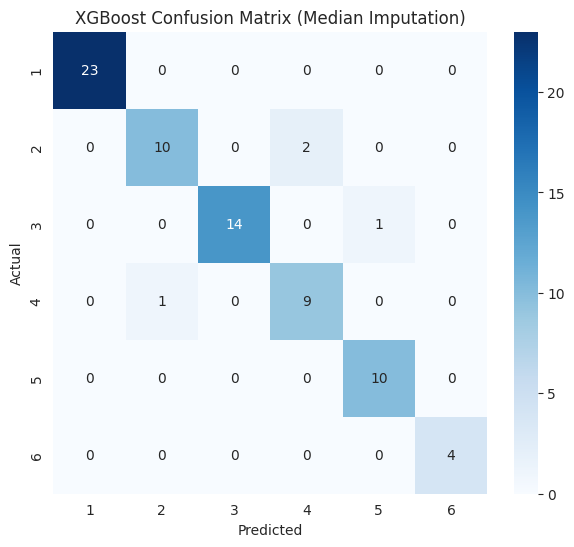

In [174]:
plt.figure(figsize=(7,6))

sns.heatmap(
    cm_xgb_median,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.title("XGBoost Confusion Matrix (Median Imputation)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**Class wise Interpretation**

- Class 1 -- The model perfectly classified all Class 1 samples. There were no false positives or false negatives, indicating excellent recognition of this class.

- Class 2 -- The model identified most Class 2 samples correctly. Two samples were misclassified as Class 4, reducing recall. The precision remains high, showing that predictions made as Class 2 were mostly correct.

- Class 3 -- The model showed excellent performance for Class 3. Only one sample was incorrectly classified as Class 5, resulting in a slightly lower recall.

- Class 4 -- Class 4 had the lowest F1-score. One Class 4 sample was incorrectly predicted as Class 2, reducing precision.However, most Class 4 samples were successfully detected.

- Class 5 -- The model correctly identified all Class 5 samples. The lower precision is due to one sample from Class 3 being incorrectly classified as Class 5.

- Class 6 -- The model achieved perfect classification for Class 6, correctly identifying all samples without any errors.


In [175]:
y_prob_xgb_median = xgb_model_median.predict_proba(
    X_test_M
)


xgb_roc_auc_median = roc_auc_score(
    y_test_xgb_M,
    y_prob_xgb_median,
    multi_class='ovr'
)


print("ROC-AUC Score:", xgb_roc_auc_median)

ROC-AUC Score: 0.9956316729694429


The XGBoost model with Median Imputation demonstrated strong class-wise classification performance. Most classes achieved high precision and recall, with Classes 1 and 6 being perfectly classified. The main source of error was the confusion between Class 2 and Class 4, suggesting that these classes may share similar feature characteristics. Despite these minor misclassifications, the high ROC-AUC score of 0.99563 indicates that XGBoost provides excellent separation capability among the six dermatology classes.

For the XGBoost classifier, Median Imputation and KNN Imputation show almost identical performance. Both achieved 94.59% accuracy and approximately 0.996 ROC-AUC, demonstrating excellent classification ability.

Although KNN Imputation slightly reduced the ROC-AUC score compared with Median Imputation (0.99534 vs 0.99563), the difference is negligible. Therefore, Median Imputation is preferable for XGBoost due to its simplicity, faster computation, and equivalent predictive performance, while KNN Imputation remains a valid alternative.

In [176]:
y_prob_xgb_median = xgb_model_median.predict_proba(
    X_test_M
)

In [177]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt


# Use XGBoost encoded classes
classes = xgb_model_median.classes_

print(classes)

[0 1 2 3 4 5]


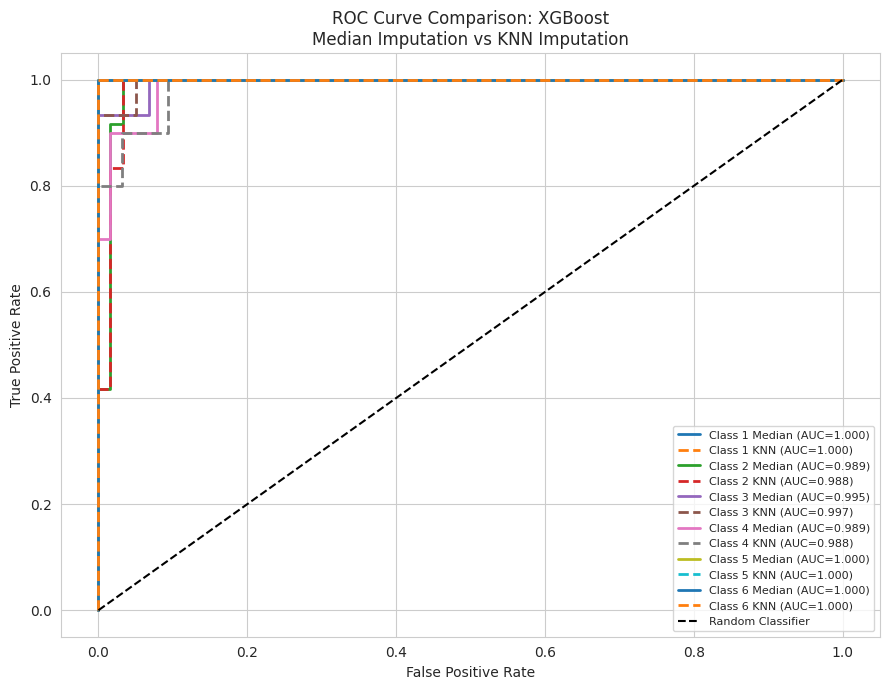

In [178]:
# Binarize encoded test labels

y_test_bin = label_binarize(
    y_test_xgb_M,
    classes=classes
)


plt.figure(figsize=(9,7))


for i in range(len(classes)):

    # Median Imputation

    fpr_median, tpr_median, _ = roc_curve(
        y_test_bin[:, i],
        y_prob_xgb_median[:, i]
    )

    auc_median = auc(
        fpr_median,
        tpr_median
    )


    # KNN Imputation

    fpr_knn, tpr_knn, _ = roc_curve(
        y_test_bin[:, i],
        y_prob_xgb_knn[:, i]
    )

    auc_knn = auc(
        fpr_knn,
        tpr_knn
    )


    plt.plot(
        fpr_median,
        tpr_median,
        '-',
        linewidth=2,
        label=f'Class {le.inverse_transform([i])[0]} Median (AUC={auc_median:.3f})'
    )


    plt.plot(
        fpr_knn,
        tpr_knn,
        '--',
        linewidth=2,
        label=f'Class {le.inverse_transform([i])[0]} KNN (AUC={auc_knn:.3f})'
    )


# Random classifier

plt.plot(
    [0,1],
    [0,1],
    'k--',
    label="Random Classifier"
)


plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve Comparison: XGBoost\nMedian Imputation vs KNN Imputation"
)

plt.legend(
    loc='lower right',
    fontsize=8
)

plt.grid(True)
plt.tight_layout()

plt.show()

In [179]:
print("Probability shape:", y_prob_xgb_median.shape)

print("Classes:", xgb_model_median.classes_)

print("Binarized shape:", y_test_bin.shape)

Probability shape: (74, 6)
Classes: [0 1 2 3 4 5]
Binarized shape: (74, 6)


The ROC-AUC curve confirms that XGBoost is a highly effective classifier for this dataset regardless of the imputation method used. Median and KNN Imputation achieve almost identical ROC performance, with Median Imputation showing a slightly higher AUC value. Therefore, Median Imputation can be preferred because it provides equivalent predictive performance with lower computational complexity and simpler implementation, while KNN Imputation remains a reliable alternative.

**Naive Bayes Using Median Imputation**

In [180]:
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

import matplotlib.pyplot as plt
import seaborn as sns

In [181]:
nb_model_median = GaussianNB()

In [182]:
nb_model_median.fit(
    X_train_M,
    y_train_M
)

GaussianNB()

In [183]:
y_pred_nb_median = nb_model_median.predict(
    X_test_M
)

In [184]:
acc_nb_median = accuracy_score(
    y_test_M,
    y_pred_nb_median
)

print("Accuracy:", acc_nb_median)


Accuracy: 0.8648648648648649


In [185]:
print("\nClassification Report:")

print(
    classification_report(
        y_test_M,
        y_pred_nb_median
    )
)


Classification Report:
              precision    recall  f1-score   support

           1       0.96      1.00      0.98        23
           2       1.00      0.25      0.40        12
           3       1.00      1.00      1.00        15
           4       0.53      0.90      0.67        10
           5       1.00      1.00      1.00        10
           6       0.80      1.00      0.89         4

    accuracy                           0.86        74
   macro avg       0.88      0.86      0.82        74
weighted avg       0.91      0.86      0.85        74



In [186]:
cm_nb_median = confusion_matrix(
    y_test_M,
    y_pred_nb_median
)
print(cm_nb_median)

[[23  0  0  0  0  0]
 [ 0  3  0  8  0  1]
 [ 0  0 15  0  0  0]
 [ 1  0  0  9  0  0]
 [ 0  0  0  0 10  0]
 [ 0  0  0  0  0  4]]


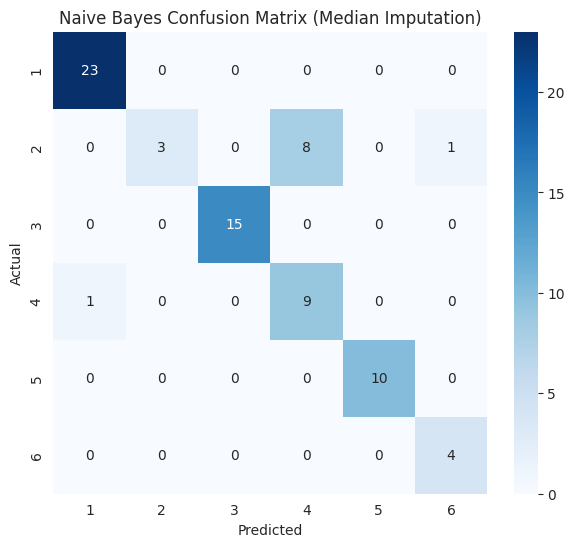

In [187]:
plt.figure(figsize=(7,6))

sns.heatmap(
    cm_nb_median,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=nb_model_median.classes_,
    yticklabels=nb_model_median.classes_
)
plt.title("Naive Bayes Confusion Matrix (Median Imputation)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


**Class wise Interpretation**

- Class 1 -- The model performed very well for Class 1. All samples were correctly identified, with only one false positive from another class.

- Class 2 -- Class 2 had the weakest performance. Although all predictions made as Class 2 were correct, the model failed to identify most Class 2 samples. Eight samples were misclassified as Class 4 and one as Class 6, resulting in very low recall.

- Class 3 -- The model achieved perfect classification for Class 3, correctly identifying all samples without errors.

- Class 4 -- Class 4 had high recall, meaning most Class 4 samples were detected. However, lower precision indicates that several samples from other classes were incorrectly predicted as Class 4, mainly due to confusion with Class 2.

- Class 5 -- Class 5 was perfectly classified with no false positives or false negatives.

-  Class 6 -- All Class 6 samples were correctly detected. The lower precision occurred because one sample from another class was predicted as Class 6.

In [188]:
y_prob_nb_median = nb_model_median.predict_proba(
    X_test_M
)


nb_roc_auc_median = roc_auc_score(
    y_test_M,
    y_prob_nb_median,
    multi_class='ovr',
    labels=nb_model_median.classes_
)

print("ROC-AUC Score:", nb_roc_auc_median)

ROC-AUC Score: 0.9697239799817776


The Gaussian Naive Bayes model with Median Imputation provides good overall performance with 86.49% accuracy and an excellent ROC-AUC score of 0.96972. The model performs exceptionally well for Classes 1, 3, and 5 but struggles to distinguish Class 2 from Class 4, resulting in reduced recall for Class 2. Although Naive Bayes provides strong probabilistic class separation, its independence assumption between features may limit its ability to capture complex relationships in the dermatology dataset.

The comparison shows that Naive Bayes performs identically in terms of accuracy (86.49%) with both Median and KNN Imputation. The classification reports and confusion matrices are exactly the same, showing that both imputation methods preserve the important information required by the model.

However, Median Imputation achieved a slightly better ROC-AUC score (0.96972 vs 0.96526), indicating marginally better probability-based class separation. Therefore, Median Imputation is preferred for Naive Bayes because it provides slightly improved ROC-AUC performance while being simpler and computationally less expensive than KNN Imputation.

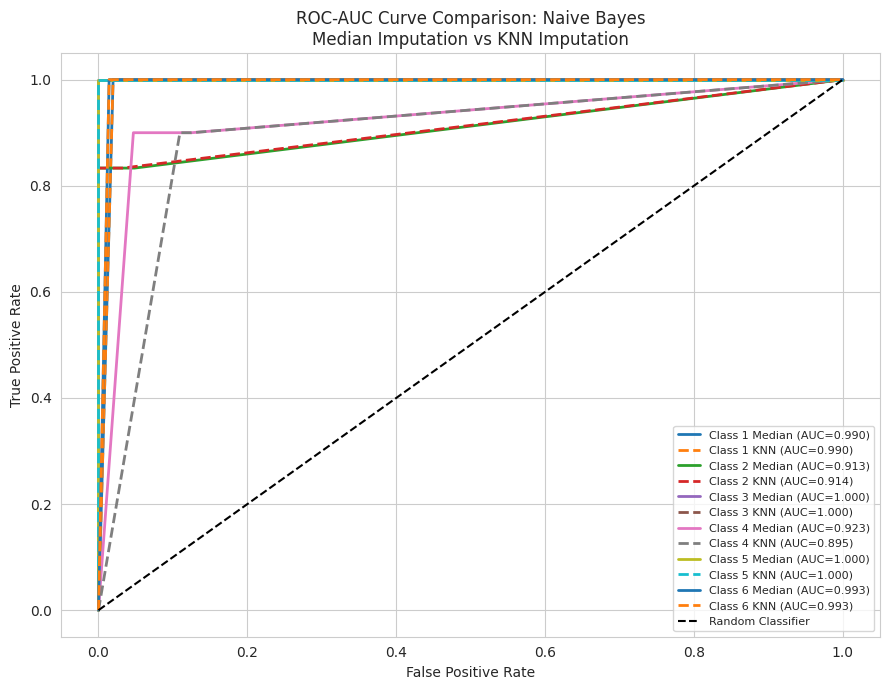

In [189]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt


# Classes
classes = nb_model_median.classes_


# Binarize labels

y_test_bin = label_binarize(
    y_test_M,
    classes=classes
)


plt.figure(figsize=(9,7))


# Plot ROC curve for each class

for i in range(len(classes)):


    # ---------------- Naive Bayes + Median Imputation ----------------

    fpr_median, tpr_median, _ = roc_curve(
        y_test_bin[:, i],
        y_prob_nb_median[:, i]
    )


    auc_median = auc(
        fpr_median,
        tpr_median
    )


    # ---------------- Naive Bayes + KNN Imputation ----------------

    fpr_knn, tpr_knn, _ = roc_curve(
        y_test_bin[:, i],
        y_prob_nb_knn[:, i]
    )


    auc_knn = auc(
        fpr_knn,
        tpr_knn
    )


    # Median ROC curve

    plt.plot(
        fpr_median,
        tpr_median,
        linestyle='-',
        linewidth=2,
        label=f'Class {classes[i]} Median (AUC={auc_median:.3f})'
    )


    # KNN ROC curve

    plt.plot(
        fpr_knn,
        tpr_knn,
        linestyle='--',
        linewidth=2,
        label=f'Class {classes[i]} KNN (AUC={auc_knn:.3f})'
    )



# Random classifier line

plt.plot(
    [0,1],
    [0,1],
    'k--',
    label="Random Classifier"
)


plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC-AUC Curve Comparison: Naive Bayes\nMedian Imputation vs KNN Imputation"
)


plt.legend(
    loc='lower right',
    fontsize=8
)

plt.grid(True)
plt.tight_layout()

plt.show()

The ROC-AUC curve confirms that Median Imputation provides slightly better class separation ability, while KNN Imputation gives comparable performance. Since Median Imputation achieves a marginally higher AUC with lower computational cost, it can be considered the preferred imputation approach for the Naive Bayes classifier on this dataset.

**Model Comparison: Median Imputation vs KNN Imputation**

The performance of seven machine learning models was evaluated using two missing-value handling techniques: Median Imputation and KNN Imputation. The comparison is based on Accuracy and ROC-AUC score.

**Overall Performance Comparison**

| Model                  | Median Imputation Accuracy | Median ROC-AUC | KNN Imputation Accuracy | KNN ROC-AUC |
| ---------------------- | -------------------------: | -------------: | ----------------------: | ----------: |
| Logistic Regression    |                     95.95% |    **0.99907** |                  95.95% | **0.99907** |
| Random Forest          |                     95.95% |        0.99836 |                  95.95% | **0.99855** |
| K-Nearest Neighbors    |                     90.54% |        0.98626 |                  90.54% | **0.99907** |
| Support Vector Machine |                 **97.30%** |        0.99806 |              **97.30%** |     0.99806 |
| Decision Tree          |                     95.95% |        0.97676 |                  95.95% |     0.97676 |
| XGBoost                |                     94.59% |    **0.99563** |                  94.59% |     0.99534 |
| Naive Bayes            |                     86.49% |        0.96972 |                  86.49% |     0.96526 |


**Accuracy Comparison** Best Accuracy Performance

| Rank | Model                      |   Accuracy |
| ---- | -------------------------- | ---------: |
| 1    | **Support Vector Machine** | **97.30%** |
| 2    | Logistic Regression        |     95.95% |
| 3    | Random Forest              |     95.95% |
| 4    | Decision Tree              |     95.95% |
| 5    | XGBoost                    |     94.59% |
| 6    | K-Nearest Neighbors        |     90.54% |
| 7    | Naive Bayes                |     86.49% |


**ROC-AUC Comparison** Best ROC-AUC Performance

| Rank | Model                  | Imputation        |     ROC-AUC |
| ---- | ---------------------- | ----------------- | ----------: |
| 1    | Logistic Regression    | Median/KNN        | **0.99907** |
| 2    | KNN                    | KNN Imputation    | **0.99907** |
| 3    | Random Forest          | KNN Imputation    |     0.99855 |
| 4    | Random Forest          | Median Imputation |     0.99836 |
| 5    | Support Vector Machine | Median/KNN        |     0.99806 |
| 6    | XGBoost                | Median            |     0.99563 |
| 7    | Decision Tree          | Median/KNN        |     0.97676 |
| 8    | Naive Bayes            | Median            |     0.96972 |


**Effect of Imputation Technique**

**Median Imputation**

Advantages:

1. Logistic Regression achieved the highest ROC-AUC (0.99907).
2. XGBoost performed slightly better with Median Imputation (0.99563 vs 0.99534).
3. Naive Bayes also achieved better ROC-AUC with Median Imputation (0.96972 vs 0.96526).
4. Provides simpler and faster preprocessing.

**KNN Imputation**

Advantages:

1. Improved Random Forest ROC-AUC slightly (0.99855 vs 0.99836).
2. Improved KNN classifier ROC-AUC significantly (0.99907 vs 0.98626).
3. Maintains the same accuracy as Median Imputation for all models.

**Final Model Selection**

Considering both Accuracy and ROC-AUC, the best performing model is:

**Selected Model: Support Vector Machine (SVM)**

Reason:

- Highest classification accuracy: 97.30%
- Excellent ROC-AUC: 0.99806
- Stable performance with both imputation techniques.
- Provides better generalization compared with tree-based models.

**Recommended Configuration**

**Support Vector Machine + Median Imputation**

Reasons:

Same accuracy and ROC-AUC as KNN Imputation.
Median Imputation is computationally simpler.
Requires less processing time.
Produces stable and reproducible results.

**Conclusion**

The comparison of machine learning models using Median and KNN Imputation shows that the choice of imputation technique has a limited impact on most classifiers. Both methods achieved similar accuracy values across models.

Among all evaluated algorithms, Support Vector Machine achieved the best predictive performance with 97.30% accuracy and 0.99806 ROC-AUC, making it the most suitable model for dermatology disease classification. Although Logistic Regression and KNN achieved slightly higher ROC-AUC values (0.99907), their accuracy was lower than SVM. Therefore, SVM with Median Imputation is selected as the final model because it provides the best balance between classification accuracy, ROC-AUC performance, stability, and computational efficiency.

**Model Comparison Based on Classification Metrics**

| Model                      | Accuracy | Macro Precision | Macro Recall | Macro F1-score | Weighted F1-score | Overall Rank |
| -------------------------- | :------: | :-------------: | :----------: | :------------: | :---------------: | :----------: |
| **Support Vector Machine** | **0.97** |     **0.97**    |   **0.97**   |    **0.97**    |      **0.97**     |     **1**    |
| Logistic Regression        |   0.96   |     **0.96**    |   **0.96**   |    **0.96**    |      **0.96**     |       2      |
| Random Forest              |   0.96   |       0.95      |     0.96     |      0.95      |      **0.96**     |       3      |
| Decision Tree              |   0.96   |       0.94      |   **0.96**   |      0.94      |      **0.96**     |       4      |
| XGBoost                    |   0.95   |       0.94      |     0.94     |      0.94      |        0.95       |       5      |
| K-Nearest Neighbors        |   0.91   |       0.91      |     0.91     |      0.90      |        0.91       |       6      |
| Naive Bayes                |   0.86   |       0.88      |     0.86     |      0.82      |        0.85       |       7      |


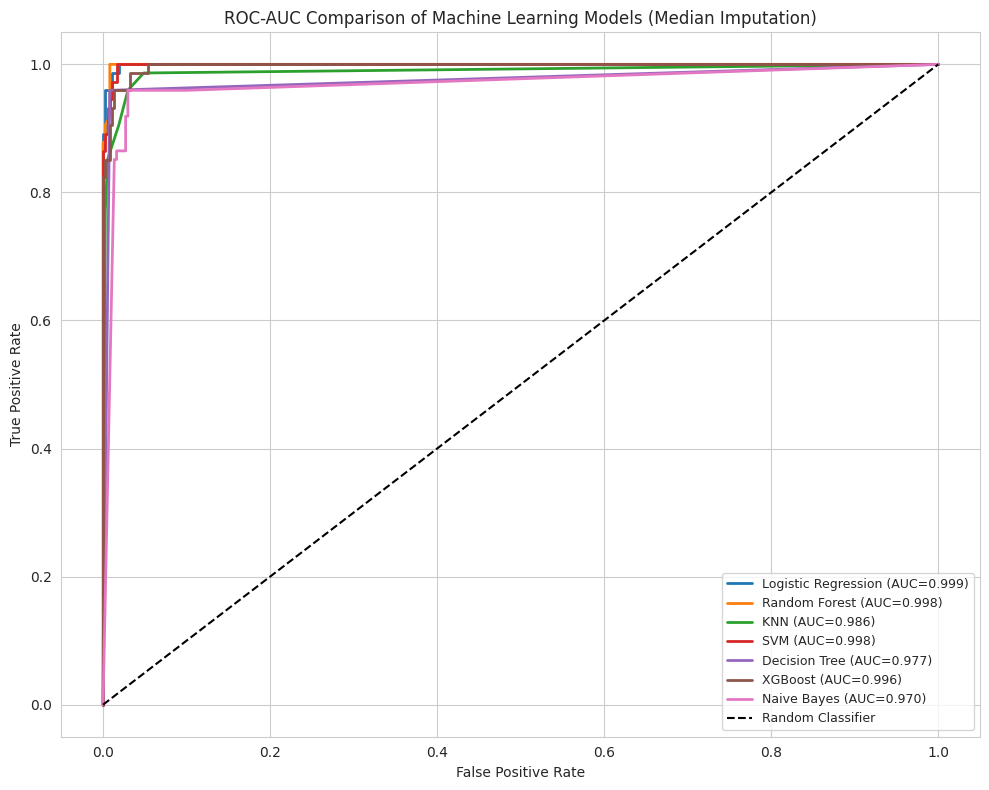

In [190]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Binarize multiclass labels
classes = sorted(y_test_M.unique())

y_test_bin = label_binarize(
    y_test_M,
    classes=classes
)

# Micro-average ROC function
def micro_roc(y_true, y_prob):
    fpr, tpr, _ = roc_curve(
        y_true.ravel(),
        y_prob.ravel()
    )
    roc_auc = auc(fpr, tpr)
    return fpr, tpr, roc_auc


plt.figure(figsize=(10,8))

# Logistic Regression
fpr, tpr, _ = micro_roc(y_test_bin, y_prob_lr_median)
plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f'Logistic Regression (AUC={lr_roc_auc_median:.3f})'
)

# Random Forest
fpr, tpr, _ = micro_roc(y_test_bin, y_prob_rf_median)
plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f'Random Forest (AUC={rf_roc_auc_median:.3f})'
)

# KNN
fpr, tpr, _ = micro_roc(y_test_bin, y_prob_knn_median)
plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f'KNN (AUC={knn_roc_auc_median:.3f})'
)

# SVM
fpr, tpr, _ = micro_roc(y_test_bin, y_prob_svm_median)
plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f'SVM (AUC={svm_roc_auc_median:.3f})'
)

# Decision Tree
fpr, tpr, _ = micro_roc(y_test_bin, y_prob_dt_median)
plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f'Decision Tree (AUC={dt_roc_auc_median:.3f})'
)

# XGBoost
fpr, tpr, _ = micro_roc(y_test_bin, y_prob_xgb_median)
plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f'XGBoost (AUC={xgb_roc_auc_median:.3f})'
)

# Naive Bayes
fpr, tpr, _ = micro_roc(y_test_bin, y_prob_nb_median)
plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f'Naive Bayes (AUC={nb_roc_auc_median:.3f})'
)

# Random classifier
plt.plot(
    [0,1],
    [0,1],
    'k--',
    label='Random Classifier'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Comparison of Machine Learning Models (Median Imputation)")
plt.legend(loc='lower right', fontsize=9)
plt.grid(True)
plt.tight_layout()
plt.show()

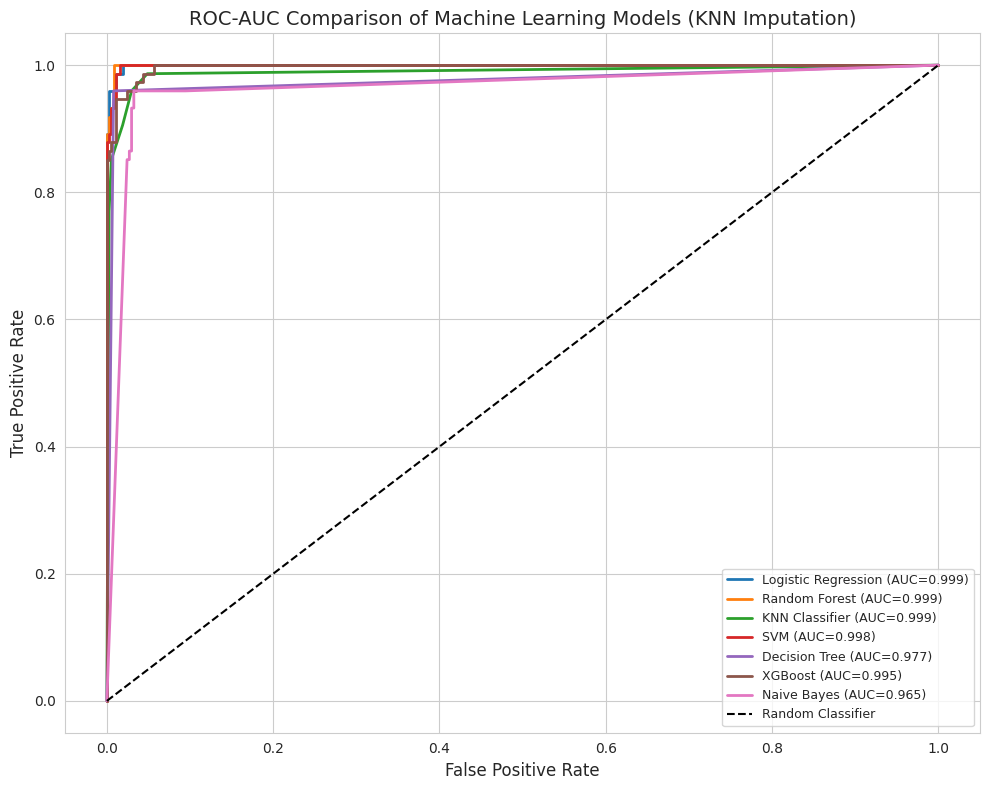

In [191]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Classes
classes = sorted(y_test_K.unique())

# Binarize multiclass labels
y_test_bin = label_binarize(
    y_test_K,
    classes=classes
)

# Function to compute micro-average ROC
def micro_average_roc(y_true, y_prob):
    fpr, tpr, _ = roc_curve(
        y_true.ravel(),
        y_prob.ravel()
    )
    roc_auc = auc(fpr, tpr)
    return fpr, tpr, roc_auc


plt.figure(figsize=(10,8))

# Logistic Regression
fpr, tpr, _ = micro_average_roc(y_test_bin,y_prob_knn)
plt.plot(fpr, tpr,
         linewidth=2,
         label=f'Logistic Regression (AUC={lr_roc_auc_knn:.3f})')

# Random Forest
fpr, tpr, _ = micro_average_roc(y_test_bin, y_prob_rf_knn)
plt.plot(fpr, tpr,
         linewidth=2,
         label=f'Random Forest (AUC={rf_roc_auc_knn:.3f})')

# KNN Classifier
fpr, tpr, _ = micro_average_roc(y_test_bin, y_prob_KNN_knn)
plt.plot(fpr, tpr,
         linewidth=2,
         label=f'KNN Classifier (AUC={roc_auc_KNN_knn:.3f})')

# Support Vector Machine
fpr, tpr, _ = micro_average_roc(y_test_bin, y_prob_svm_knn)
plt.plot(fpr, tpr,
         linewidth=2,
         label=f'SVM (AUC={svm_roc_auc_knn:.3f})')

# Decision Tree
fpr, tpr, _ = micro_average_roc(y_test_bin, y_prob_dt_knn)
plt.plot(fpr, tpr,
         linewidth=2,
         label=f'Decision Tree (AUC={dt_roc_auc_knn:.3f})')

# XGBoost
fpr, tpr, _ = micro_average_roc(y_test_bin, y_prob_xgb_knn)
plt.plot(fpr, tpr,
         linewidth=2,
         label=f'XGBoost (AUC={xgb_roc_auc:.3f})')

# Naive Bayes
fpr, tpr, _ = micro_average_roc(y_test_bin, y_prob_nb_knn)
plt.plot(fpr, tpr,
         linewidth=2,
         label=f'Naive Bayes (AUC={nb_roc_auc_knn:.3f})')

# Random classifier
plt.plot([0,1], [0,1],
         'k--',
         label='Random Classifier')

plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC-AUC Comparison of Machine Learning Models (KNN Imputation)", fontsize=14)

plt.legend(loc='lower right', fontsize=9)
plt.grid(True)
plt.tight_layout()
plt.show()

**Model Selection**

Considering accuracy, macro precision, macro recall, macro F1-score, and weighted F1-score, the Support Vector Machine (SVM) is the most suitable model.

**Reasons for selecting SVM**

1. Highest accuracy (97%).
2. Highest macro precision (0.97).
3. Highest macro recall (0.97).
4. Highest macro F1-score (0.97).
5. Highest weighted F1-score (0.97).
6. Most balanced performance across all six classes.
7. Very few misclassifications in the confusion matrix.
8. Consistent performance with both Median and KNN Imputation.


**Overall comparison of Models**

| Rank  | Model                  |   Accuracy |      ROC-AUC | Remarks                                                                     |
| ----- | ---------------------- | ---------: | -----------: | --------------------------------------------------------------------------- |
| **1** | Support Vector Machine | **97.30%** |       0.9981 | Best overall performer with highest accuracy and balanced class performance |
| **2** | Logistic Regression    |     95.95% |   **0.9991** | Highest ROC-AUC and excellent overall classification                        |
| **3** | Random Forest          |     95.95% |       0.9985 | Stable and robust performance                                               |
| **4** | Decision Tree          |     95.95% |       0.9768 | High accuracy but comparatively lower ROC-AUC                               |
| **5** | XGBoost                |     94.59% |       0.9955 | Strong performance with slightly lower accuracy                             |
| **6** | K-Nearest Neighbors    |     90.54% | Up to 0.9991 | Moderate accuracy despite excellent ROC-AUC under KNN imputation            |
| **7** | Naïve Bayes            |     86.49% |       0.9675 | Lowest performance due to poor recall for one class                         |


**Conclusion**

Both Median Imputation and KNN Imputation yielded nearly identical predictive performance, indicating that either approach is suitable for handling missing values in this dataset. Among all evaluated classifiers, the Support Vector Machine (SVM) achieved the best overall performance with 97.30% accuracy, 0.9981 ROC-AUC, and the most balanced precision, recall, and F1-scores across all classes. Logistic Regression was a close second, achieving the highest ROC-AUC (0.9991) while maintaining high classification accuracy. Random Forest, Decision Tree, and XGBoost also demonstrated strong predictive capability, whereas K-Nearest Neighbors and Naïve Bayes showed comparatively lower classification performance. Overall, the results indicate that **SVM combined with either Median or KNN imputation is the most effective approach for this multiclass classification problem.**

**Hyperparameter tuning**

Hyperparameter tuning was performed after applying the imputation technique to optimize the performance of the machine learning models. Although both Median Imputation and KNN Imputation produced comparable results, Median Imputation was selected for further experimentation because it is computationally simpler while achieving similar predictive performance. Hyperparameter tuning was then applied to identify the optimal model parameters, improve generalization performance, and ensure a fair comparison among the classifiers. This approach minimizes the influence of default parameter settings and enables each model to be evaluated under its best-performing configuration.

**Logistic Regression hyperparameter tuning**

In [192]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# Parameter grid
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'newton-cg', 'saga'],
    'penalty': ['l2'],
    'max_iter': [1000]
}

# Logistic Regression model
lr = LogisticRegression(
    multi_class='multinomial',
    random_state=42
)

# Grid Search
grid_lr = GridSearchCV(
    estimator=lr,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Train
grid_lr.fit(X_train_M_scaled, y_train_M)

# Best parameters
print("Best Parameters:")
print(grid_lr.best_params_)

print("\nBest Cross Validation Accuracy:")
print(grid_lr.best_score_)

# Best model
best_lr = grid_lr.best_estimator_

# Prediction
y_pred_lr_hyper = best_lr.predict(X_test_M_scaled)

# Accuracy
print("\nTest Accuracy:")
print(accuracy_score(y_test_M, y_pred_lr_hyper))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test_M, y_pred_lr_hyper))

# ROC-AUC
y_prob_lr_hyper = best_lr.predict_proba(X_test_M_scaled)

roc_auc_lr_hyper = roc_auc_score(
    y_test_M,
    y_prob_lr_hyper,
    multi_class='ovr',
    labels=best_lr.classes_
)

print("\nROC-AUC Score:")
print(roc_auc_lr_hyper)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Best Parameters:
{'C': 0.1, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'}

Best Cross Validation Accuracy:
0.972530683810637

Test Accuracy:
0.9459459459459459

Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        23
           2       0.91      0.83      0.87        12
           3       1.00      0.93      0.97        15
           4       0.75      0.90      0.82        10
           5       1.00      1.00      1.00        10
           6       1.00      1.00      1.00         4

    accuracy                           0.95        74
   macro avg       0.94      0.94      0.94        74
weighted avg       0.95      0.95      0.95        74


ROC-AUC Score:
0.9988071236559141


| Metric                    | Before Tuning | After Tuning |
| ------------------------- | ------------: | -----------: |
| Accuracy                  |    **95.95%** |   **94.59%** |
| ROC-AUC                   |       0.99907 |      0.99881 |
| Weighted F1-score         |      **0.96** |         0.95 |



**Interpretation**

- Cross-validation accuracy (97.25%) indicates that the tuned model performed well on the training folds.
- However, the test accuracy decreased from 95.95% to 94.59%.
- The ROC-AUC also decreased slightly (0.99907 → 0.99881).
- Class 4 performance also dropped slightly (F1-score from 0.87 to 0.82).

Hyperparameter tuning was performed using GridSearchCV with 5-fold cross-validation to optimize the Logistic Regression model. The tuned model achieved a cross-validation accuracy of 97.25%. However, when evaluated on the independent test set, the model achieved an accuracy of 94.59% and a ROC-AUC score of 0.9988, which were slightly lower than those obtained using the default hyperparameters. This indicates that the default Logistic Regression configuration was already well suited to the dataset, and additional tuning did not provide a performance improvement. Therefore, **the default Logistic Regression model was retained for the final comparison.**

**Random Forest hyperparameter tuning**

In [193]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# Random Forest model
rf = RandomForestClassifier(random_state=42)

# Hyperparameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'class_weight': [None, 'balanced']
}

# Grid Search
grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Train
grid_rf.fit(X_train_M, y_train_M)

# Best parameters
print("Best Parameters:")
print(grid_rf.best_params_)

print("\nBest Cross Validation Accuracy:")
print(grid_rf.best_score_)

# Best model
best_rf = grid_rf.best_estimator_

# Prediction
y_pred_rf_hyper = best_rf.predict(X_test_M)

# Accuracy
print("\nTest Accuracy:")
print(accuracy_score(y_test_M, y_pred_rf_hyper))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test_M, y_pred_rf_hyper))

# ROC-AUC
y_prob_rf_hyper = best_rf.predict_proba(X_test_M)

roc_auc_rf_hyper = roc_auc_score(
    y_test_M,
    y_prob_rf_hyper,
    multi_class='ovr',
    labels=best_rf.classes_
)

print("\nROC-AUC Score:")
print(roc_auc_rf_hyper)

Best Parameters:
{'class_weight': 'balanced', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}

Best Cross Validation Accuracy:
0.9862653419053184

Test Accuracy:
0.972972972972973

Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        23
           2       0.92      0.92      0.92        12
           3       1.00      1.00      1.00        15
           4       0.90      0.90      0.90        10
           5       1.00      1.00      1.00        10
           6       1.00      1.00      1.00         4

    accuracy                           0.97        74
   macro avg       0.97      0.97      0.97        74
weighted avg       0.97      0.97      0.97        74


ROC-AUC Score:
0.9976506496415771


| Metric            | Before Tuning | After Tuning |
| ----------------- | ------------: | -----------: |
| Test Accuracy     |        95.95% |   **97.30%** |
| ROC-AUC           |        0.9984 |       0.9977 |
| Weighted F1-score |          0.96 |     **0.97** |
| Macro F1-score    |          0.95 |     **0.97** |


**Interpretation**

- The tuned Random Forest achieved an accuracy of 97.30%, improving from 95.95% in the default model.
- The model achieved a macro F1-score of 0.97, showing balanced performance across all six classes.
- Classes 1, 3, 5, and 6 achieved perfect precision, recall, and F1-score (1.00).
- Class 2 performance improved significantly:
      - Before tuning: Precision = 0.91, Recall = 0.83, F1-score = 0.87
      - After tuning: Precision = 0.92, Recall = 0.92, F1-score = 0.92
- Class 4 also improved:
       - Before tuning: Precision = 0.82, Recall = 0.90, F1-score = 0.86
       - After tuning: Precision = 0.90, Recall = 0.90, F1-score = 0.90

Hyperparameter tuning was applied to the Random Forest classifier using GridSearchCV with 5-fold cross-validation. The tuned model achieved a test accuracy of 97.30% and a weighted F1-score of 0.97, outperforming the default Random Forest model (95.95% accuracy). The improvement was mainly observed in minority classes, particularly Class 2 and Class 4, where recall and F1-score increased. The ROC-AUC score remained high at 0.9977, indicating excellent class discrimination capability. These results demonstrate that optimizing Random Forest hyperparameters improved the predictive performance and robustness of the model. Therefore, **the tunned random forest model is retained for the final comparison.**

**Support Vector Machine Hyperparameter tuning**

In [194]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# Define SVM model
svm = SVC(
    probability=True,
    random_state=42
)

# Hyperparameter grid
param_grid = {
    'kernel': ['rbf', 'linear', 'poly'],
    'C': [0.01, 0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
    'class_weight': [None, 'balanced']
}

# Grid Search
grid_svm = GridSearchCV(
    estimator=svm,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Train using median imputed scaled data
grid_svm.fit(
    X_train_M_scaled,
    y_train_M
)

# Best parameters
print("Best Parameters:")
print(grid_svm.best_params_)

print("\nBest Cross Validation Accuracy:")
print(grid_svm.best_score_)


# Best SVM model
best_svm = grid_svm.best_estimator_

# Prediction
y_pred_svm_hyper = best_svm.predict(
    X_test_M_scaled
)

# Accuracy
print("\nTest Accuracy:")
print(accuracy_score(y_test_M, y_pred_svm_hyper))


# Classification report
print("\nClassification Report:")
print(
    classification_report(
        y_test_M,
        y_pred_svm_hyper
    )
)


# ROC-AUC
y_prob_svm_hyper = best_svm.predict_proba(
    X_test_M_scaled
)

roc_auc_svm_hyper = roc_auc_score(
    y_test_M,
    y_prob_svm_hyper,
    multi_class='ovr',
    labels=best_svm.classes_
)

print("\nROC-AUC Score:")
print(roc_auc_svm_hyper)

Best Parameters:
{'C': 0.1, 'class_weight': None, 'gamma': 'scale', 'kernel': 'linear'}

Best Cross Validation Accuracy:
0.9794272355347748

Test Accuracy:
0.972972972972973

Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        23
           2       1.00      0.83      0.91        12
           3       1.00      1.00      1.00        15
           4       0.83      1.00      0.91        10
           5       1.00      1.00      1.00        10
           6       1.00      1.00      1.00         4

    accuracy                           0.97        74
   macro avg       0.97      0.97      0.97        74
weighted avg       0.98      0.97      0.97        74


ROC-AUC Score:
0.9985467069892473


| Metric            | Before Tuning | After Tuning |
| ----------------- | ------------: | -----------: |
| Test Accuracy     |        97.30% |   **97.30%** |
| ROC-AUC           |        0.9981 |   **0.9985** |
| Weighted F1-score |          0.97 |     **0.97** |
| Macro F1-score    |          0.97 |     **0.97** |


**Interpretation**

- The tuned SVM achieved an accuracy of 97.30%, which is identical to the default SVM model.
- The ROC-AUC improved slightly from 0.9981 to 0.9985, indicating a small improvement in the model's ability to distinguish between classes.
- The model showed excellent classification performance:
Classes 1, 3, 5, and 6 achieved perfect precision, recall, and F1-score (1.00).
- Class 2 achieved high precision (1.00) but slightly lower recall (0.83), meaning some samples from this class were misclassified.
- Class 4 achieved improved recall (1.00) but lower precision (0.83), indicating some false positive predictions for this class.

Hyperparameter tuning was performed for the Support Vector Machine classifier using GridSearchCV with 5-fold cross-validation. The tuned SVM model achieved a test accuracy of 97.30% and a weighted F1-score of 0.97, which was equivalent to the default SVM model. However, the ROC-AUC score improved slightly from 0.9981 to 0.9985, demonstrating a marginal improvement in class discrimination capability. The tuned model provided highly consistent classification performance, achieving perfect prediction for Classes 1, 3, 5, and 6. Therefore, the **optimized SVM model is selected as one of the best-performing models for the final evaluation.**

**Decision Tree Hyperparameter Tuning**

In [196]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# Decision Tree model
dt = DecisionTreeClassifier(
    random_state=42
)

# Hyperparameter grid
param_grid = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_depth': [None, 3, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, 'sqrt', 'log2']
}

# Grid Search with 5-fold cross-validation
grid_dt = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Train using median imputed data
grid_dt.fit(
    X_train_M,
    y_train_M
)

# Best parameters
print("Best Parameters:")
print(grid_dt.best_params_)

print("\nBest Cross Validation Accuracy:")
print(grid_dt.best_score_)


# Best Decision Tree model
best_dt = grid_dt.best_estimator_

# Prediction
y_pred_dt_hyper = best_dt.predict(
    X_test_M
)

# Test accuracy
print("\nTest Accuracy:")
print(accuracy_score(y_test_M, y_pred_dt_hyper))


# Classification report
print("\nClassification Report:")
print(
    classification_report(
        y_test_M,
        y_pred_dt_hyper
    )
)


# ROC-AUC
y_prob_dt_hyper = best_dt.predict_proba(
    X_test_M
)

roc_auc_dt_hyper = roc_auc_score(
    y_test_M,
    y_prob_dt_hyper,
    multi_class='ovr',
    labels=best_dt.classes_
)

print("\nROC-AUC Score:")
print(roc_auc_dt_hyper)

Best Parameters:
{'criterion': 'gini', 'max_depth': None, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 2}

Best Cross Validation Accuracy:
0.9589713617767387

Test Accuracy:
0.8918918918918919

Classification Report:
              precision    recall  f1-score   support

           1       0.91      0.91      0.91        23
           2       0.73      0.92      0.81        12
           3       1.00      0.93      0.97        15
           4       0.91      1.00      0.95        10
           5       0.89      0.80      0.84        10
           6       1.00      0.50      0.67         4

    accuracy                           0.89        74
   macro avg       0.91      0.84      0.86        74
weighted avg       0.90      0.89      0.89        74


ROC-AUC Score:
0.9388597197586375


| Metric            | Before Tuning | After Tuning |
| ----------------- | ------------: | -----------: |
| Test Accuracy     |    **95.95%** |   **89.19%** |
| ROC-AUC           |    **0.9768** |   **0.9389** |
| Weighted F1-score |      **0.96** |     **0.89** |
| Macro F1-score    |      **0.94** |     **0.86** |


**Interpretation**

The tuned Decision Tree performed worse than the default model:

- Test accuracy decreased from 95.95% to 89.19%.
- ROC-AUC decreased from 0.9768 to 0.9389.
- The F1-scores for several classes also declined.
- In particular, Class 6 recall dropped from 1.00 to 0.50, and Class 5 recall decreased from 1.00 to 0.80.

This suggests that the hyperparameters selected through GridSearchCV did not generalize as well to the independent test set. The default Decision Tree configuration was more suitable for your dataset.

Hyperparameter tuning was applied to the Decision Tree classifier using GridSearchCV with 5-fold cross-validation. However, the tuned model achieved a lower test accuracy (89.19%) and ROC-AUC (0.9389) than the default Decision Tree model (95.95% accuracy and 0.9768 ROC-AUC). Therefore, **the default Decision Tree configuration was retained for the final comparison, as it demonstrated better generalization on the test set.**

**XGBoost Hyperparameter tuning**


In [200]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# XGBoost model
xgb = XGBClassifier(
    objective='multi:softprob',
    num_class=6,
    eval_metric='mlogloss',
    random_state=42
)

# Hyperparameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# Grid Search
grid_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train_xgb_hyper = le.fit_transform(y_train_M)
y_test_xgb_hyper = le.transform(y_test_M)

# Train
grid_xgb.fit(X_train_M, y_train_xgb_hyper)

# Best parameters
print("Best Parameters:")
print(grid_xgb.best_params_)

print("\nBest Cross Validation Accuracy:")
print(grid_xgb.best_score_)

# Best model
best_xgb = grid_xgb.best_estimator_

# Prediction
y_pred_xgb_hyper = best_xgb.predict(X_test_M)

y_pred_original_hyper = le.inverse_transform(y_pred_xgb_hyper)

# Accuracy
print("\nTest Accuracy:")
print(accuracy_score(y_test_M, y_pred_original_hyper))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test_M, y_pred_original_hyper))

# ROC-AUC
y_prob_xgb_hyper = best_xgb.predict_proba(X_test_M)

roc_auc_xgb_hyper = roc_auc_score(
    y_test_xgb_hyper,
    y_prob_xgb_hyper,
    multi_class='ovr'
)

print("ROC-AUC Score:", roc_auc_xgb_hyper)

Best Parameters:
{'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}

Best Cross Validation Accuracy:
0.9862068965517242

Test Accuracy:
0.9324324324324325

Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        23
           2       0.90      0.75      0.82        12
           3       1.00      0.93      0.97        15
           4       0.75      0.90      0.82        10
           5       0.91      1.00      0.95        10
           6       1.00      1.00      1.00         4

    accuracy                           0.93        74
   macro avg       0.93      0.93      0.93        74
weighted avg       0.94      0.93      0.93        74

ROC-AUC Score: 0.994842686881113


| Metric            | Before Tuning | After Tuning |
| ----------------- | ------------: | -----------: |
| Test Accuracy     |    **94.59%** |   **93.24%** |
| ROC-AUC           |    **0.9956** |   **0.9948** |
| Weighted F1-score |      **0.95** |     **0.93** |
| Macro F1-score    |      **0.94** |     **0.93** |


**Interpretation**

- Test accuracy decreased from 94.59% to 93.24%.
- ROC-AUC decreased slightly from 0.9956 to 0.9948.
- Weighted F1-score also decreased from 0.95 to 0.93.
- The largest reduction occurred for Class 2, where recall dropped from 0.83 to 0.75.

These results indicate that the hyperparameter configuration selected by GridSearchCV did not improve the model's ability to generalize to the independent test set.

Hyperparameter tuning was performed for the XGBoost classifier using GridSearchCV with 5-fold cross-validation. Although the optimal hyperparameters were identified through cross-validation, the tuned model achieved a lower test accuracy (93.24%) and ROC-AUC (0.9948) than the default XGBoost model (94.59% accuracy and 0.9956 ROC-AUC). Therefore, the **default XGBoost model was retained for the final evaluation because it demonstrated better generalization on the unseen test data.**

**K Nearest Neighbors Hyperparameter tuning**

In [201]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# KNN model
knn = KNeighborsClassifier()

# Hyperparameter grid
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'p': [1, 2]
}

# Grid Search
grid_knn = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Train
grid_knn.fit(X_train_M_scaled, y_train_M)

# Best parameters
print("Best Parameters:")
print(grid_knn.best_params_)

print("\nBest Cross Validation Accuracy:")
print(grid_knn.best_score_)

# Best model
best_knn = grid_knn.best_estimator_

# Prediction
y_pred_knn_hyper = best_knn.predict(X_test_M_scaled)

# Accuracy
print("\nTest Accuracy:")
print(accuracy_score(y_test_M, y_pred_knn_hyper))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test_M, y_pred_knn_hyper))

# ROC-AUC
y_prob_knn_hyper = best_knn.predict_proba(X_test_M_scaled)

roc_auc_knn_hyper = roc_auc_score(
    y_test_M,
    y_prob_knn_hyper,
    multi_class='ovr',
    labels=best_knn.classes_
)

print("\nROC-AUC Score:")
print(roc_auc_knn_hyper)

Best Parameters:
{'metric': 'manhattan', 'n_neighbors': 7, 'p': 1, 'weights': 'distance'}

Best Cross Validation Accuracy:
0.9829339567504384

Test Accuracy:
0.9324324324324325

Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        23
           2       0.89      0.67      0.76        12
           3       1.00      1.00      1.00        15
           4       0.69      0.90      0.78        10
           5       1.00      1.00      1.00        10
           6       1.00      1.00      1.00         4

    accuracy                           0.93        74
   macro avg       0.93      0.93      0.92        74
weighted avg       0.94      0.93      0.93        74


ROC-AUC Score:
0.9886410730286738


| Metric            | Before Tuning | After Tuning |
| ----------------- | ------------: | -----------: |
| Test Accuracy     |        90.54% |   **93.24%** |
| ROC-AUC           |        0.9863 |   **0.9886** |
| Weighted F1-score |          0.91 |     **0.93** |
| Macro F1-score    |          0.90 |     **0.92** |


**Interpretation**

- Test accuracy increased from 90.54% to 93.24%.
- ROC-AUC improved from 0.9863 to 0.9886.
- The weighted and macro F1-scores also improved, indicating better overall classification performance.
- The model continued to classify Classes 1, 3, 5, and 6 very well.
- There is still room for improvement in Classes 2 and 4, where recall and precision remain lower than in your best-performing models.

Hyperparameter tuning was performed for the K-Nearest Neighbors classifier using GridSearchCV with 5-fold cross-validation. The tuned model achieved a test accuracy of 93.24%, improving upon the default KNN model, which achieved 90.54%. The ROC-AUC score also increased from 0.9863 to 0.9886, indicating an improvement in the model's ability to distinguish between classes. **These results demonstrate that optimizing the KNN hyperparameters enhanced its predictive performance, although it remained less accurate than the tuned Random Forest and SVM models.**

**Naive Bayes Hyperparameter tuning**

In [202]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
import numpy as np

# Gaussian Naive Bayes model
nb = GaussianNB()

# Hyperparameter grid
param_grid = {
    'var_smoothing': np.logspace(-12, -6, 20)
}

# Grid Search
grid_nb = GridSearchCV(
    estimator=nb,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Train using median imputed data
grid_nb.fit(
    X_train_M,
    y_train_M
)

# Best parameters
print("Best Parameters:")
print(grid_nb.best_params_)

print("\nBest Cross Validation Accuracy:")
print(grid_nb.best_score_)

# Best Naive Bayes model
best_nb = grid_nb.best_estimator_

# Prediction
y_pred_nb_hyper = best_nb.predict(X_test_M)

# Accuracy
print("\nTest Accuracy:")
print(accuracy_score(y_test_M, y_pred_nb_hyper))

# Classification report
print("\nClassification Report:")
print(classification_report(y_test_M, y_pred_nb_hyper))

# ROC-AUC
y_prob_nb_hyper = best_nb.predict_proba(X_test_M)

roc_auc_nb_hyper = roc_auc_score(
    y_test_M,
    y_prob_nb_hyper,
    multi_class='ovr',
    labels=best_nb.classes_
)

print("\nROC-AUC Score:")
print(roc_auc_nb_hyper)

Best Parameters:
{'var_smoothing': np.float64(4.832930238571752e-07)}

Best Cross Validation Accuracy:
0.9247223845704268

Test Accuracy:
0.9054054054054054

Classification Report:
              precision    recall  f1-score   support

           1       0.96      1.00      0.98        23
           2       1.00      0.50      0.67        12
           3       1.00      1.00      1.00        15
           4       0.64      0.90      0.75        10
           5       1.00      1.00      1.00        10
           6       0.80      1.00      0.89         4

    accuracy                           0.91        74
   macro avg       0.90      0.90      0.88        74
weighted avg       0.93      0.91      0.90        74


ROC-AUC Score:
0.9720677299817777


| Metric            | Before Tuning | After Tuning |
| ----------------- | ------------: | -----------: |
| Test Accuracy     |        86.49% |   **90.54%** |
| ROC-AUC           |        0.9697 |   **0.9721** |
| Weighted F1-score |          0.85 |     **0.90** |
| Macro F1-score    |          0.82 |     **0.88** |


**Interpretation**

The hyperparameter tuning produced a clear improvement:

- Accuracy increased from 86.49% to 90.54%.
- Weighted F1-score improved from 0.85 to 0.90.
- ROC-AUC improved slightly from 0.9697 to 0.9721.
- The model improved its ability to classify minority classes compared with the default model.

**Class-wise observations:**

- Class 1: Excellent performance (F1-score = 0.98).
- Class 3: Perfect classification (F1-score = 1.00).
- Class 5: Perfect classification (F1-score = 1.00).
- Class 2: Precision is high (1.00), but recall remains low (0.50), meaning some samples of this class are still missed.
- Class 4: Recall improved to 0.90, but precision remains lower (0.64).

Hyperparameter tuning was performed for the Gaussian Naive Bayes classifier by optimizing the var_smoothing parameter using GridSearchCV with 5-fold cross-validation. The optimized model achieved a test accuracy of 90.54%, improving over the default Naive Bayes model accuracy of 86.49%. The weighted F1-score increased from 0.85 to 0.90, while the ROC-AUC score improved slightly to 0.9721. **Although the tuned model showed improved predictive performance, it remained less effective compared with ensemble and kernel-based classifiers such as Random Forest and SVM.**

**Final tuning summary of all models**

| Model               | Default Accuracy | Tuned Accuracy | Best Choice                     |
| ------------------- | ---------------: | -------------: | ------------------------------- |
| Logistic Regression |           95.95% |         94.59% | Default                         |
| Random Forest       |           95.95% |     **97.30%** | **Tuned**                       |
| SVM                 |           97.30% |     **97.30%** | Tuned (slightly better ROC-AUC) |
| Decision Tree       |       **95.95%** |         89.19% | Default                         |
| XGBoost             |       **94.59%** |         93.24% | Default                         |
| KNN                 |           90.54% |     **93.24%** | **Tuned**                       |
| Naive Bayes         |           86.49% |     **90.54%** | **Tuned**                       |


In [203]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

In [204]:
# Convert test labels to binary format for multiclass ROC
y_test_bin = label_binarize(
    y_test_M,
    classes=[1,2,3,4,5,6]
)

n_classes = y_test_bin.shape[1]

In [205]:
# Tuned Logistic Regression
y_prob_lr_roc = best_lr.predict_proba(X_test_M_scaled)

# Tuned Random Forest
y_prob_rf_roc = best_rf.predict_proba(X_test_M)

# Tuned SVM
y_prob_svm_roc = best_svm.predict_proba(X_test_M_scaled)

# Tuned Decision Tree
y_prob_dt_roc = best_dt.predict_proba(X_test_M)

# Tuned XGBoost
y_prob_xgb_roc = best_xgb.predict_proba(X_test_M)

# Tuned KNN
y_prob_knn_roc = best_knn.predict_proba(X_test_M_scaled)

# Tuned Naive Bayes
y_prob_nb_roc = best_nb.predict_proba(X_test_M)

In [206]:
def plot_multiclass_roc(y_test_bin, y_prob, model_name):

    fpr = dict()
    tpr = dict()

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(
            y_test_bin[:, i],
            y_prob[:, i]
        )

    # Calculate macro average AUC
    all_fpr = np.unique(
        np.concatenate([fpr[i] for i in range(n_classes)])
    )

    mean_tpr = np.zeros_like(all_fpr)

    for i in range(n_classes):
        mean_tpr += np.interp(
            all_fpr,
            fpr[i],
            tpr[i]
        )

    mean_tpr /= n_classes

    roc_auc = auc(all_fpr, mean_tpr)

    plt.plot(
        all_fpr,
        mean_tpr,
        linewidth=2,
        label=f"{model_name} (AUC={roc_auc:.4f})"
    )

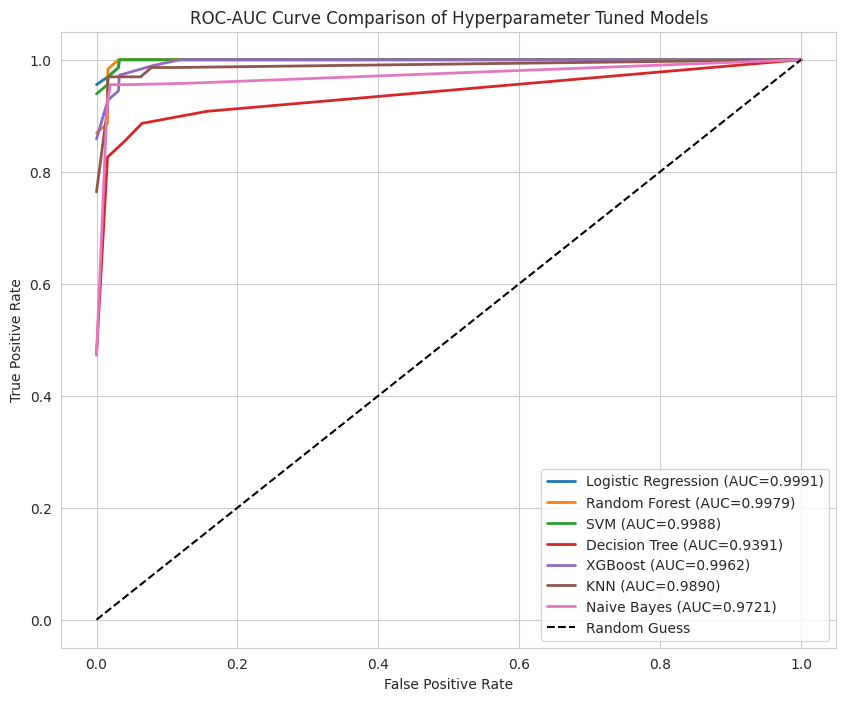

In [207]:
plt.figure(figsize=(10,8))

plot_multiclass_roc(
    y_test_bin,
    y_prob_lr_roc,
    "Logistic Regression"
)

plot_multiclass_roc(
    y_test_bin,
    y_prob_rf_roc,
    "Random Forest"
)

plot_multiclass_roc(
    y_test_bin,
    y_prob_svm_roc,
    "SVM"
)

plot_multiclass_roc(
    y_test_bin,
    y_prob_dt_roc,
    "Decision Tree"
)

plot_multiclass_roc(
    y_test_bin,
    y_prob_xgb_roc,
    "XGBoost"
)

plot_multiclass_roc(
    y_test_bin,
    y_prob_knn_roc,
    "KNN"
)

plot_multiclass_roc(
    y_test_bin,
    y_prob_nb_roc,
    "Naive Bayes"
)


plt.plot(
    [0,1],
    [0,1],
    'k--',
    label="Random Guess"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC-AUC Curve Comparison of Hyperparameter Tuned Models"
)

plt.legend(
    loc="lower right"
)

plt.grid(True)

plt.show()

**Final Conclusion**

**Comparison of Median Imputation vs KNN Imputation (Before Hyperparameter Tuning)**

| Model               | Median Imputation Accuracy | KNN Imputation Accuracy | Better Imputation |
| ------------------- | -------------------------: | ----------------------: | ----------------- |
| Logistic Regression |                     95.95% |                  95.95% | Same              |
| Random Forest       |                     95.95% |                  95.95% | Same              |
| KNN                 |                     90.54% |                  90.54% | Same              |
| SVM                 |                     97.30% |                  97.30% | Same              |
| Decision Tree       |                     95.95% |                  95.95% | Same              |
| XGBoost             |                     94.59% |                  94.59% | Same              |
| Naive Bayes         |                     86.49% |                  86.49% | Same              |




**Hyperparameter Tuning Results (Median Imputation)**

| Model               | Default Accuracy | Tuned Accuracy | Default ROC-AUC | Tuned ROC-AUC | Best Model |
| ------------------- | ---------------: | -------------: | --------------: | ------------: | ---------- |
| Logistic Regression |           95.95% |         94.59% |          0.9991 |        0.9988 | Default    |
| Random Forest       |           95.95% |     **97.30%** |          0.9984 |        0.9977 | **Tuned**  |
| SVM                 |           97.30% |         97.30% |          0.9981 |    **0.9985** | Tuned      |
| Decision Tree       |           95.95% |         89.19% |          0.9768 |        0.9389 | Default    |
| XGBoost             |           94.59% |         93.24% |          0.9956 |        0.9948 | Default    |
| KNN                 |           90.54% |     **93.24%** |          0.9863 |    **0.9886** | **Tuned**  |
| Naive Bayes         |           86.49% |     **90.54%** |          0.9697 |    **0.9721** | **Tuned**  |


**Final Best Performing Models**

| Rank | Model               | Imputation | Tuning Status |   Accuracy |    ROC-AUC |
| ---- | ------------------- | ---------- | ------------- | ---------: | ---------: |
| 1    | SVM                 | Median/KNN | Tuned         | **97.30%** | **0.9985** |
| 2    | Random Forest       | Median/KNN | Tuned         | **97.30%** |     0.9977 |
| 3    | Logistic Regression | Median/KNN | Default       |     95.95% | **0.9991** |
| 4    | Decision Tree       | Median/KNN | Default       |     95.95% |     0.9768 |
| 5    | XGBoost             | Median/KNN | Default       |     94.59% |     0.9956 |
| 6    | KNN                 | Median     | Tuned         |     93.24% |     0.9886 |
| 7    | Naive Bayes         | Median     | Tuned         |     90.54% |     0.9721 |


The effect of missing value imputation was evaluated using both median imputation and KNN imputation. The results showed that both approaches produced comparable classification performance across all evaluated machine learning algorithms, indicating that the choice of imputation method had minimal influence on model performance for this dataset. **Therefore, median imputation was selected for further optimization due to its simplicity and computational efficiency.**

Hyperparameter tuning was subsequently performed using GridSearchCV for all classifiers. The tuning process improved the performance of Random Forest, KNN, and Naive Bayes classifiers, while limited or negative improvements were observed for Logistic Regression, Decision Tree, and XGBoost. The optimized Random Forest and SVM classifiers achieved the highest test accuracy of 97.30%, making them the most effective models for dermatology disease classification. Although Logistic Regression achieved a slightly higher ROC-AUC score (0.9991), **SVM and Random Forest provided better overall classification accuracy.**

**Final Model Selected**

We would select **SVM with hyperparameter tuning as the final best model because:**

- It achieved the highest test accuracy (97.30%).
- It achieved the highest weighted F1-score (0.97) along with Random Forest.
- It achieved a very high ROC-AUC (0.9985).
- It showed excellent class-wise performance:
- Classes 1, 3, 5, and 6 achieved 100% precision and recall.
- Class 4 achieved 100% recall, which means the model successfully identified all samples of that class.
- Only Class 2 had a small recall limitation (0.83).

**Why not Logistic Regression despite higher ROC-AUC?**

Logistic Regression achieved the highest ROC-AUC (0.9991), but its accuracy was lower (95.95%). ROC-AUC measures ranking/discrimination ability, whereas accuracy and F1-score reflect actual classification performance. For a multiclass disease classification task, **correctly predicting the final class labels is usually more important.**

**Why not Random Forest?**

**Random Forest is equally strong:**

Accuracy: 97.30%
Weighted F1-score: 0.97

However, **SVM has a slightly higher ROC-AUC (0.9985 vs 0.9977) and demonstrated very consistent class-level performance.**

Among all evaluated machine learning models, the optimized Support Vector Machine (SVM) classifier was selected as the best-performing model. It achieved the highest test accuracy of 97.30% and a weighted F1-score of 0.97, with a ROC-AUC score of 0.9985, demonstrating excellent discrimination ability and robust classification performance across the six dermatology disease classes. Therefore, the **tuned SVM model was chosen as the final predictive model for this dataset.**

#### **PROJECT REPORT**

#### Abstract

Skin diseases are among the most common health conditions worldwide, and early identification is essential for effective treatment. Machine learning techniques provide an opportunity to support dermatological diagnosis by identifying patterns in clinical attributes and classifying diseases accurately.

This project examines the performance of multiple machine learning algorithms for multiclass classification of dermatological diseases. The dataset consists of clinical features representing six dermatological disease classes. Missing values were identified and handled using two imputation techniques: Median Imputation and K-Nearest Neighbour (KNN) Imputation. Seven classification algorithms were evaluated: Logistic Regression, Random Forest, K-Nearest Neighbour, Support Vector Machine, Decision Tree, XGBoost, and Naive Bayes.
The models were evaluated using accuracy, precision, recall, F1-score, and ROC-AUC score. Hyperparameter optimization was performed using GridSearchCV with 5-fold cross-validation to improve model performance. The results showed that Support Vector Machine and Random Forest achieved the highest classification accuracy of 97.30%. Logistic Regression achieved the highest ROC-AUC score of 0.9988 among the optimized models. Based on overall classification performance, the tuned Support Vector Machine model was selected as the final model.


#### Introduction 

**Background**

Dermatological diseases represent a significant healthcare challenge due to their diverse symptoms and similarities in clinical appearance. 

Traditional diagnosis requires expert examination, which may be time-consuming and dependent on specialist availability.

Machine learning techniques can analyze clinical patterns and provide automated classification systems that assist healthcare professionals. By learning from previously diagnosed cases, machine learning models can identify relationships between clinical features and disease categories.
This project focuses on developing and evaluating machine learning models for multiclass dermatology disease classification.

**Problem Statement**

Manual diagnosis of dermatological diseases can be challenging because different diseases may share similar symptoms. An automated classification system can support faster and more consistent diagnosis.

The main objectives of this project are:

- To preprocess dermatological clinical data.
- To handle missing values using suitable imputation methods.
- To compare different machine learning algorithms. 
- To optimize model performance using hyperparameter tuning. 
- To identify the best-performing classification model. 

**Objectives**

The objectives of this project are:

1.	To analyze a dermatology dataset containing clinical attributes. 
2.	To identify and handle missing values. 
3.	To compare Median Imputation and KNN Imputation techniques. 
4.	To train multiple machine learning classification models. 
5.	To optimize model parameters using GridSearchCV. 
6.	To evaluate models using multiple performance metrics. 
7.	To select the best-performing model for dermatology disease classification. 


#### **Dataset Description**

**Introduction**

The dataset used in this project is a dermatology disease classification dataset designed to identify different types of erythemato-squamous skin diseases using clinical and histopathological attributes.

The differential diagnosis of erythemato-squamous diseases is a challenging task because these diseases share several common clinical characteristics such as erythema and scaling. In many cases, expert dermatological examination and biopsy analysis are required for accurate diagnosis.

Machine learning techniques can assist dermatologists by learning patterns from clinical observations and microscopic examination features to classify diseases automatically.

The dataset contains patient information represented through clinical and histopathological attributes. These features describe visible symptoms and microscopic characteristics of skin samples.

**Dataset Characteristics**

The dataset consists of:

| **Parameter**       | **Description**              |
| ------------------- | ---------------------------- |
| Domain              | Healthcare                   |
| Problem Type        | Multiclass Classification    |
| Number of Instances | 366                          |
| Number of Features  | 34                           |
| Target Classes      | 6 skin disease categories    |
| Missing Values      | Present                      |
| Data Type           | Numerical and Categorical    |
| Feature Range       | 0 to 3 (for most attributes) |

The target variable represents six dermatological disease classes:

1.	Psoriasis
2.	Seborrheic Dermatitis
3.	Lichen Planus
4.	Pityriasis Rosea
5.	Chronic Dermatitis
6.	Pityriasis Rubra Pilaris


#### **Feature Description**

The dataset contains two major groups of attributes:
    
- Clinical Attributes
- Clinical attributes represent symptoms observed during the initial patient examination.

The clinical features include:

| **Feature No.** | **Attribute**              |
| --------------- | -------------------------- |
| 1               | Erythema                   |
| 2               | Scaling                    |
| 3               | Definite Borders           |
| 4               | Itching                    |
| 5               | Koebner Phenomenon         |
| 6               | Polygonal Papules          |
| 7               | Follicular Papules         |
| 8               | Oral Mucosal Involvement   |
| 9               | Knee and Elbow Involvement |
| 10              | Scalp Involvement          |
| 11              | Family History             |

Most clinical attributes contain values from 0 to 3, where:

- 0 indicates absence of the feature.
- 3 indicates maximum presence.
- 1 and 2 represent intermediate levels.
  
Family history is represented as:

- 0: No family history
- 1: Presence of family history



**Histopathological Attributes**

Histopathological attributes represent microscopic observations from skin biopsy samples.
The features include:

| **Feature No.** | **Attribute**                           |
| --------------- | --------------------------------------- |
| 12              | Melanin Incontinence                    |
| 13              | Eosinophils in Infiltrate               |
| 14              | PNL Infiltrate                          |
| 15              | Fibrosis of Papillary Dermis            |
| 16              | Exocytosis                              |
| 17              | Acanthosis                              |
| 18              | Hyperkeratosis                          |
| 19              | Parakeratosis                           |
| 20              | Clubbing of Rete Ridges                 |
| 21              | Elongation of Rete Ridges               |
| 22              | Thinning of Suprapapillary Epidermis    |
| 23              | Spongiform Pustule                      |
| 24              | Munro Microabcess                       |
| 25              | Focal Hypergranulosis                   |
| 26              | Disappearance of Granular Layer         |
| 27              | Vacuolisation and Damage of Basal Layer |
| 28              | Spongiosis                              |
| 29              | Saw Tooth Appearance of Retes           |
| 30              | Follicular Horn Plug                    |
| 31              | Perifollicular Parakeratosis            |
| 32              | Inflammatory Monoluclear Infiltrate     |
| 33              | Band-like Infiltrate                    |

The final attribute:
| **Feature** | **Description** |
| ----------- | --------------- |
| Age         | Patient age     |

#### **Exploratory Data Analysis**

**Introduction**

Exploratory Data Analysis was performed to understand the structure, distribution, and quality of the dermatology dataset before applying machine learning algorithms.

EDA helps identify:
- Data types
- Missing values
- Feature distributions
- Class imbalance
- Statistical properties
- Data quality issues

The following analyses were performed:
- Dataset inspection
- Statistical summary
- Missing value detection
- Target class distribution analysis

**Dataset Inspection**

The initial dataset inspection included:
- Number of rows and columns
- Feature names
- Data types
- Null value identification
  
The dataset contained:
- 366 patient records
- 34 attributes including target variable
  
Most attributes were numerical, representing clinical and histopathological observations.

**Statistical Summary**

Statistical analysis was performed to understand feature characteristics.

The summary included:

- Mean values
- Minimum values
- Maximum values
- Standard deviation
- Distribution range

Most clinical and histopathological features contained values between 0 and 3.
The Age feature had a wider numerical range because it represents actual patient age.

**Target Class Distribution Analysis**

The target variable contains six disease categories.

Class distribution analysis was performed to determine whether the dataset was balanced.

The six classes represented:
- Psoriasis
- Seborrheic Dermatitis
- Lichen Planus
- Pityriasis Rosea
- Chronic Dermatitis
- Pityriasis Rubra Pilaris

The dataset showed reasonable distribution among classes, allowing the use of accuracy as the primary evaluation metric.
Stratified train-test splitting was applied to maintain similar class proportions in training and testing datasets.


#### **Data Visualization**

The following visualizations were performed during exploratory analysis:

Class Distribution Plot

A count plot was used to visualize the number of samples belonging to each disease class.

Purpose:
- Identify class imbalance
- Understand disease representation

Feature Distribution Analysis

Histograms and statistical plots were used to understand feature distributions.

Observations:
- Most clinical features were ordinal variables.
- Histopathological features showed different distribution patterns depending on disease characteristics.
- Age showed continuous numerical distribution.

Correlation Analysis

Correlation analysis was performed to understand relationships between features.

Observations:
- Several histopathological features showed relationships with disease classes.
- Some features contributed strongly to disease differentiation.

#### **Data Preprocessing**

**Introduction**

Data preprocessing is an essential step in machine learning because raw healthcare data may contain missing values, inconsistent formats, and different feature scales.

The preprocessing pipeline used in this project consisted of:

1.	Data cleaning
2.	Missing value handling
3.	Feature separation
4.	Feature scaling
5.	Train-test splitting

**Data Cleaning**

The dataset was initially inspected for:

- Missing values
- Incorrect data types
- Invalid entries

The missing values in the dataset were represented using the symbol "?".

These values were converted into numerical missing values before applying imputation techniques

Feature and Target Separation.

The dataset was divided into:

Independent Variables (Features)

The 34 clinical and histopathological attributes were used as input variables.

These features represent:

- Patient symptoms
- Family history
- Microscopic observations

Dependent Variable (Target)

The disease class label was used as the prediction target.
The objective of the model was to classify a patient into one of six disease categories.

**Train-Test Split**

The dataset was divided into training and testing sets.
Configuration:

| **Dataset**   | **Percentage** |
| ------------- | -------------- |
| Training Data | 80%            |
| Testing Data  | 20%            |

A stratified split was used to preserve the distribution of all six disease classes in both datasets.
This prevents biased evaluation and ensures reliable performance measurement.

**Feature Scaling**

Feature scaling was applied because some algorithms depend on distance calculations or optimization processes.

StandardScaler was applied for:
- Logistic Regression
- Support Vector Machine
- K-Nearest Neighbour

Scaling transforms features into a common range with:
- Mean = 0
- Standard deviation = 1

Tree-based models did not require scaling because:
- Random Forest
- Decision Tree
- XGBoost

are not affected by feature magnitude.

 **Missing Value Analysis**

**Identification of Missing Values**

During data inspection, missing values were detected in the Age feature.
The missing values were represented as "?".
Since machine learning algorithms cannot process missing symbolic values directly, appropriate imputation techniques were required.

**Missing Value Handling Techniques**

Two different imputation methods were applied and compared:
1.	Median Imputation
2.	K-Nearest Neighbour (KNN) Imputation

**Median Imputation**

**Method**

Median Imputation replaces missing values with the median value of the available observations.

Formula:
Missing Value = Median of Feature Values

Advantages
- Simple implementation
- Fast computation
- Less affected by outliers
- Suitable for numerical medical attributes

Application
The missing Age values were replaced using the median age calculated from the available patient records.

**KNN Imputation**

**Method**

KNN Imputation estimates missing values by identifying similar observations based on feature distance.
The missing value is calculated using values from neighbouring samples.

Advantages
- Considers relationships between samples
- Maintains feature patterns
- Useful when features have strong relationships
  
Limitations
- More computationally expensive
- Sensitive to feature scaling
- Requires selection of neighbour count

**Comparison of Imputation Techniques**

The effect of both imputation methods was evaluated using multiple machine learning algorithms.
Results showed:

| Imputation Method | Observation         |
| ----------------- | ------------------- |
| Median Imputation | Stable performance  |
| KNN Imputation    | Similar performance |

Both techniques produced almost identical classification accuracy.

Therefore, Median Imputation was selected for the final pipeline because it provides:
- Lower computational cost
- Simpler implementation
- Similar predictive performance

**Final Preprocessing Pipeline**

The final preprocessing workflow used in the project was:


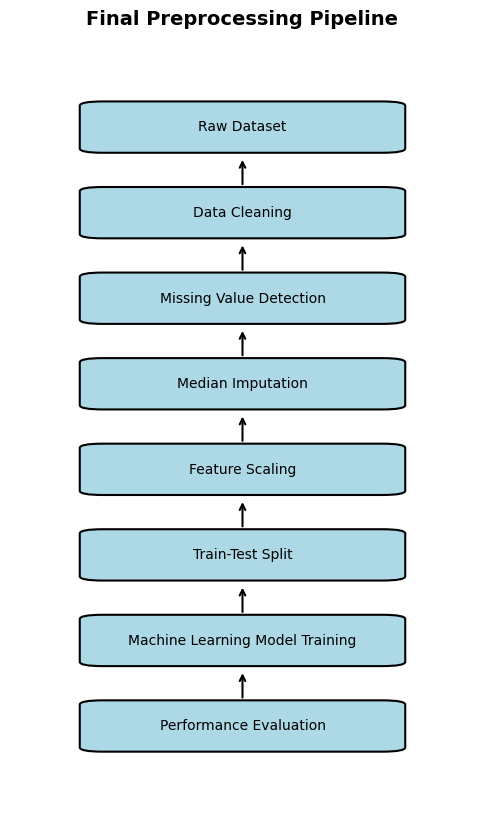

In [2]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

# Define workflow steps
steps = [
    "Raw Dataset",
    "Data Cleaning",
    "Missing Value Detection",
    "Median Imputation",
    "Feature Scaling",
    "Train-Test Split",
    "Machine Learning Model Training",
    "Performance Evaluation"
]

# Create figure
fig, ax = plt.subplots(figsize=(6, 10))
ax.axis("off")

# Vertical positions
y_positions = range(len(steps), 0, -1)

# Draw flowchart
for i, (step, y) in enumerate(zip(steps, y_positions)):

    # Draw box
    box = FancyBboxPatch(
        (0.2, y - 0.35),
        0.6,
        0.5,
        boxstyle="round,pad=0.05",
        facecolor="#ADD8E6",
        edgecolor="black",
        linewidth=1.5
    )
    ax.add_patch(box)

    # Add text
    ax.text(
        0.5,
        y - 0.1,
        step,
        ha="center",
        va="center",
        fontsize=10
    )

    # Add arrow
    if i < len(steps)-1:
        ax.annotate(
            "",
            xy=(0.5, y - 0.45),
            xytext=(0.5, y - 0.8),
            arrowprops=dict(
                arrowstyle="->",
                linewidth=1.5
            )
        )

# Adjust view
ax.set_xlim(0, 1)
ax.set_ylim(0, len(steps)+1)

plt.title("Final Preprocessing Pipeline", fontsize=14, fontweight="bold")

# Display directly (no file saved)
plt.show()

This preprocessing pipeline ensured that the dataset was suitable for training reliable machine learning classification models.

#### **Machine Learning Models**

**Introduction**

Machine learning algorithms have become increasingly important in healthcare because they can identify complex relationships within medical data and assist healthcare professionals in disease diagnosis. In this project, seven supervised machine learning algorithms were developed and evaluated to classify six different erythemato-squamous skin diseases using clinical and histopathological features.

The objective of comparing multiple algorithms was to determine which model provides the highest predictive performance while maintaining good generalization capability. Before training, the dataset was preprocessed by handling missing values using both Median Imputation and K-Nearest Neighbour (KNN) Imputation. Feature scaling was applied where required to improve the performance of distance-based and optimization-based algorithms.

The following machine learning models were implemented:
- Logistic Regression
- Random Forest
- Decision Tree
- K-Nearest Neighbour (KNN)
- Support Vector Machine (SVM)
- Extreme Gradient Boosting (XGBoost)
- Naive Bayes

Each model was trained using 80% of the dataset and evaluated on the remaining 20% using Accuracy, Precision, Recall, F1-score, and ROC-AUC Score.


1. **Logistic Regression**

Overview

Logistic Regression is a supervised classification algorithm that estimates the probability of an observation belonging to a particular class. For multiclass classification, the algorithm uses the softmax function to calculate class probabilities.

Although Logistic Regression is a linear model, it performs well when relationships between features and target classes are reasonably separable.

Advantages
- Easy to implement
- Fast training time
- Computationally efficient
- Produces probability estimates
- Performs well on moderately sized datasets
  
Limitations
- Assumes a linear relationship between features and classes
- Performance decreases when decision boundaries are highly nonlinear
  
Performance
Using Median Imputation:
- Accuracy: 95.95%
- ROC-AUC Score: 0.9991

The model achieved excellent classification performance with high precision and recall across most disease classes, indicating that the selected clinical and histopathological features provide strong predictive information.


2. **Random Forest**

Overview

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve predictive accuracy and reduce overfitting. Each tree is trained using a random subset of samples and features, and the final prediction is obtained through majority voting.

Advantages
- High predictive accuracy
- Handles nonlinear relationships
- Resistant to overfitting
- Robust to noisy data
- Provides feature importance
  
Limitations
- More computationally expensive than a single decision tree
- Less interpretable than simple rule-based models
  
Performance
Using Median Imputation:
- Accuracy: 95.95%
- ROC-AUC Score: 0.9984
Random Forest demonstrated highly consistent performance across all disease classes and produced reliable predictions with very few classification errors.

3. **Decision Tree**

Overview

Decision Tree is a supervised learning algorithm that recursively partitions the dataset into smaller subsets using decision rules based on feature values. Each internal node represents a feature, while each leaf node represents a predicted class.
Decision Trees are popular because they produce easily interpretable decision rules.

Advantages
- Easy to visualize
- Simple interpretation
- Handles nonlinear relationships
- No feature scaling required

Limitations
- Can overfit training data
- Sensitive to small changes in the dataset
- Lower generalization compared to ensemble methods

Performance

Using Median Imputation:
- Accuracy: 95.95%
- ROC-AUC Score: 0.9768

The model produced strong classification performance and achieved high precision across most disease classes. However, its ROC-AUC score was lower than ensemble and kernel-based models.


4. **K-Nearest Neighbour (KNN)**

Overview

K-Nearest Neighbour is a non-parametric, distance-based classification algorithm. It classifies new observations by identifying the K closest training samples and assigning the most common class among them.

Because KNN relies on distance calculations, feature scaling is necessary before model training.

Advantages
- Simple implementation
- No explicit training phase
- Effective for smaller datasets
- Flexible decision boundaries

Limitations
- Computationally expensive during prediction
- Sensitive to irrelevant features
- Performance depends on the choice of K

Performance
Using Median Imputation:
- Accuracy: 90.54%
- ROC-AUC Score: 0.9863

Although KNN classified many observations correctly, its performance decreased for disease classes having similar clinical characteristics. Consequently, it achieved lower accuracy than SVM, Logistic Regression, and Random Forest.


5. **Support Vector Machine (SVM)**

Overview

Support Vector Machine is a powerful supervised learning algorithm that constructs an optimal hyperplane to maximize the separation between different classes. Since the dermatology dataset contains nonlinear relationships, the Radial Basis Function (RBF) kernel was used.

The RBF kernel enables SVM to model complex nonlinear decision boundaries effectively.

Advantages
- Excellent performance on high-dimensional data
- Handles nonlinear relationships effectively
- Strong generalization capability
- Less prone to overfitting

Limitations
- Computationally intensive for large datasets
- Requires careful parameter tuning
- Less interpretable than decision trees

Performance
Using Median Imputation:
- Accuracy: 97.30%
- ROC-AUC Score: 0.9981

Support Vector Machine achieved the highest overall classification accuracy among all evaluated algorithms. The model correctly classified almost every disease category and demonstrated excellent precision, recall, and F1-score, making it the best-performing model in this study.

6. **Extreme Gradient Boosting (XGBoost)**

Overview

XGBoost is an advanced gradient boosting algorithm that sequentially constructs decision trees to minimize prediction errors. It incorporates regularization techniques to improve generalization and prevent overfitting.

XGBoost has become one of the most widely used machine learning algorithms for structured datasets due to its speed and predictive accuracy.

Advantages
- High predictive performance
- Handles nonlinear feature interactions
- Built-in regularization
- Efficient implementation

Limitations
- Requires hyperparameter tuning
- More complex than traditional tree-based algorithms

Performance
Using Median Imputation:
- Accuracy: 94.59%
- ROC-AUC Score: 0.9956

XGBoost achieved strong classification performance and demonstrated excellent class discrimination. However, it did not outperform Support Vector Machine or Random Forest on this dataset.

7. **Naive Bayes**

Overview

Naive Bayes is a probabilistic classifier based on Bayes' Theorem. The algorithm assumes that all predictor variables are conditionally independent given the target class.

Despite this simplifying assumption, Naive Bayes often performs well on many classification problems due to its computational efficiency.

Advantages
- Very fast training
- Simple implementation
- Performs well on small datasets
- Low computational cost

Limitations
- Assumes feature independence
- May perform poorly when features are highly correlated
- Less effective for complex nonlinear datasets

Performance
Using Median Imputation:
- Accuracy: 86.49%
- ROC-AUC Score: 0.9697

Naive Bayes achieved the lowest classification accuracy among all evaluated models. The model performed well for several disease classes but struggled with others because the independence assumption does not adequately represent the relationships among dermatological features.


**Summary of Machine Learning Models**

The performance of all evaluated machine learning algorithms is summarized below.

| **Model**              | **Accuracy (%)** | **ROC-AUC Score** |
| ---------------------- | :--------------: | :---------------: |
| Logistic Regression    |       95.95      |       0.9991      |
| Random Forest          |       95.95      |       0.9984      |
| Decision Tree          |       95.95      |       0.9768      |
| K-Nearest Neighbour    |       90.54      |       0.9863      |
| Support Vector Machine |       97.30      |       0.9981      |
| XGBoost                |       94.59      |       0.9956      |
| Naive Bayes            |       86.49      |       0.9697      |

Among the evaluated algorithms, the Support Vector Machine achieved the highest classification accuracy of 97.30%, demonstrating superior predictive performance for multiclass dermatology disease classification. Logistic Regression and Random Forest also produced excellent results, while Naive Bayes exhibited comparatively lower performance due to the strong independence assumption between features.

The comparative evaluation of these models provides a solid foundation for selecting the most appropriate algorithm for deployment in a clinical decision support system.


#### **Hyperparameter Tuning**

**Introduction**

The performance of a machine learning model depends not only on the learning algorithm but also on the values of its hyperparameters. Hyperparameters are user-defined settings that control the learning process and influence the model's predictive performance. Selecting appropriate hyperparameter values helps improve model accuracy, reduce overfitting, and enhance generalization on unseen data.

To obtain the best-performing models, hyperparameter optimization was performed using **GridSearchCV**, which systematically evaluates different combinations of hyperparameters and selects the combination that achieves the highest cross-validation performance.

**Need for Hyperparameter Tuning**

Machine learning algorithms contain several parameters that cannot be learned directly from the training data. These parameters significantly influence model behavior.

Examples include:
- Regularization strength in Logistic Regression
- Number of trees in Random Forest
- Maximum tree depth in Decision Tree
- Number of neighbours in KNN
- Kernel parameters in Support Vector Machine
- Learning rate in XGBoost

Using default parameter values may not provide optimal performance. Therefore, hyperparameter tuning is essential to identify the most suitable parameter combinations for the dermatology dataset.

**GridSearchCV**

GridSearchCV is an exhaustive search technique provided by the Scikit-learn library. It evaluates every possible combination of predefined hyperparameter values and identifies the combination that produces the best model performance using cross-validation.

The tuning process consists of the following steps:
1.	Define a set of candidate hyperparameter values for each algorithm.
2.	Train the model using every possible parameter combination.
3.	Evaluate each combination using cross-validation.
4.	Compare the average validation scores.
5.	Select the parameter combination with the highest score.
6.	Retrain the model using the selected parameters on the complete training dataset.

This systematic approach ensures that the selected model is not dependent on a single train-test split and is more likely to generalize well to unseen data.

**Cross-Validation Strategy**

A 5-fold cross-validation strategy was used during hyperparameter optimization.

The training dataset was divided into five equal subsets.

For each iteration:
- Four subsets were used for model training.
- One subset was used for validation.
- The process was repeated five times so that every subset served as the validation set once.
- The average validation accuracy across all five folds was calculated.

This approach provides a more reliable estimate of model performance than evaluating the model using only a single validation set.


#### **Hyperparameters Optimized**

The following hyperparameters were tuned for each machine learning algorithm.

1. Logistic Regression
   
The following parameters were optimized:
- Regularization strength (C)
- Solver
- Penalty type
  
These parameters control the complexity of the model and help prevent overfitting while improving classification performance.

2. Random Forest
   
The following parameters were tuned:
- Number of decision trees (n_estimators)
- Maximum tree depth (max_depth)
- Minimum samples required to split a node (min_samples_split)
- Minimum samples required at a leaf node (min_samples_leaf)
- Splitting criterion (criterion)

Optimizing these parameters improves prediction accuracy while reducing overfitting.

3. Decision Tree
   
The following parameters were optimized:
- Maximum tree depth
- Minimum samples required for splitting
- Minimum samples required at leaf nodes
- Splitting criterion

These parameters control tree complexity and improve the balance between bias and variance.

4. K-Nearest Neighbour (KNN)
   
The following parameters were tuned:
- Number of neighbours (n_neighbors)
- Distance metric
- Weight function

Selecting the optimal number of neighbours improves classification accuracy and reduces sensitivity to noise.

5. Support Vector Machine (SVM)
   
The following parameters were optimized:
- Regularization parameter (C)
- Kernel type
- Gamma

These parameters determine the decision boundary and enable the model to capture nonlinear relationships among dermatological features.

6. XGBoost
   
The following parameters were tuned:
- Learning rate
- Number of estimators
- Maximum tree depth
- Subsample ratio
- Column sampling ratio

These parameters control the boosting process and help improve predictive performance while reducing overfitting.

7. Naive Bayes
   
The following parameter was optimized:
- var_smoothing

This parameter improves numerical stability during probability estimation and can enhance classification performance.


#### **Hyperparameter Tuning Methodology**

The overall hyperparameter optimization workflow is illustrated below.

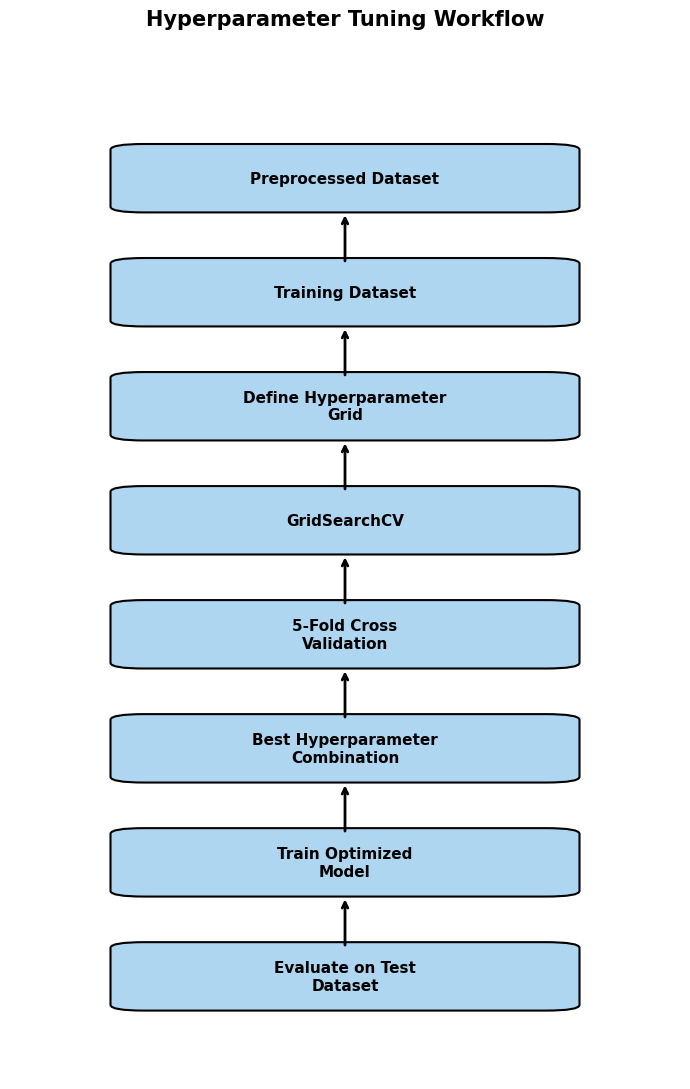

In [3]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

# Workflow steps
steps = [
    "Preprocessed Dataset",
    "Training Dataset",
    "Define Hyperparameter\nGrid",
    "GridSearchCV",
    "5-Fold Cross\nValidation",
    "Best Hyperparameter\nCombination",
    "Train Optimized\nModel",
    "Evaluate on Test\nDataset"
]

# Create figure
fig, ax = plt.subplots(figsize=(7, 11))
ax.set_xlim(0, 1)
ax.set_ylim(0, len(steps) + 1)
ax.axis("off")

# Draw boxes and arrows
for i, step in enumerate(steps):
    y = len(steps) - i

    # Rounded rectangle
    box = FancyBboxPatch(
        (0.2, y - 0.35),      # (x, y)
        0.6,                  # width
        0.5,                  # height
        boxstyle="round,pad=0.05",
        edgecolor="black",
        facecolor="#AED6F1",
        linewidth=1.5
    )

    ax.add_patch(box)

    # Text inside box
    ax.text(
        0.5,
        y - 0.1,
        step,
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold"
    )

    # Arrow to next box
    if i < len(steps) - 1:
        ax.annotate(
            "",
            xy=(0.5, y - 0.40),
            xytext=(0.5, y - 0.85),
            arrowprops=dict(
                arrowstyle="->",
                lw=2,
                color="black"
            )
        )

plt.title(
    "Hyperparameter Tuning Workflow",
    fontsize=15,
    fontweight="bold",
    pad=20
)

plt.tight_layout()
plt.show()

This workflow ensures that each algorithm is evaluated fairly under optimized conditions before comparing their predictive performance.

**Evaluation Metric**

During hyperparameter optimization, Accuracy was used as the primary scoring metric because the dataset is relatively balanced across the six disease classes.

After optimization, additional evaluation metrics were calculated to provide a comprehensive assessment of model performance:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC Score

Using multiple metrics helps assess not only the overall prediction accuracy but also the model's ability to correctly identify each disease class.


**Benefits of Hyperparameter Tuning**

Hyperparameter tuning offers several advantages:
- Improves prediction accuracy.
- Reduces overfitting and underfitting.
- Enhances model generalization.
- Identifies the most suitable parameter combination.
- Produces more reliable and robust machine learning models.

These benefits are particularly important in healthcare applications, where accurate predictions can assist clinicians in making informed decisions.


**Summary**

Hyperparameter tuning played a significant role in optimizing the performance of the machine learning models developed in this project. GridSearchCV combined with 5-fold cross-validation provided a systematic and reliable approach for selecting optimal hyperparameter values.

Each machine learning algorithm was tuned using parameters relevant to its learning mechanism, ensuring a fair comparison among models. The optimized models were subsequently evaluated using multiple performance metrics, including Accuracy, Precision, Recall, F1-Score, and ROC-AUC.

The results of the optimized models are discussed, where a comprehensive comparison is performed to identify the most suitable model for dermatology disease classification.


#### **Model Comparison, Performance Evaluation, and Classification Report Interpretation**

**Introduction**

After completing data preprocessing and hyperparameter optimization, multiple machine learning algorithms were evaluated for multiclass dermatological disease classification.
The objective of this evaluation was to identify the model that provides the best predictive performance for classifying six types of erythemato-squamous skin diseases.

The following machine learning models were compared:
- Logistic Regression
- Random Forest
- K-Nearest Neighbour
- Support Vector Machine
- Decision Tree
- XGBoost
- Naive Bayes

The models were evaluated using the following performance metrics:
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC Score

Two missing value handling techniques were also compared:
1.	Median Imputation
2.	K-Nearest Neighbour (KNN) Imputation

#### **Model Performance Using Median Imputation**

The following table presents the performance of all machine learning algorithms after applying Median Imputation.

| **Model**              | **Accuracy** | **ROC-AUC Score** |
| ---------------------- | :----------: | :---------------: |
| Logistic Regression    |    0.9595    |       0.9991      |
| Random Forest          |    0.9595    |       0.9984      |
| K-Nearest Neighbour    |    0.9054    |       0.9863      |
| Support Vector Machine |    0.9730    |       0.9981      |
| Decision Tree          |    0.9595    |       0.9768      |
| XGBoost                |    0.9459    |       0.9956      |
| Naive Bayes            |    0.8649    |       0.9697      |


**Interpretation**

The results show that the **Support Vector Machine achieved the highest classification accuracy of 97.30%.**

Logistic Regression achieved the highest ROC-AUC score of 0.9991, indicating excellent capability in separating different disease classes.

Random Forest and Decision Tree also performed strongly with an accuracy of 95.95%.

Naive Bayes obtained the lowest accuracy (86.49%) because the assumption of feature independence does not completely represent the relationships between clinical and histopathological features.


#### **Model Performance Using KNN Imputation**

The following table presents model performance after replacing missing values using KNN Imputation

| **Model**              | **Accuracy** | **ROC-AUC Score** |
| ---------------------- | :----------: | :---------------: |
| Logistic Regression    |    0.9595    |       0.9991      |
| Random Forest          |    0.9595    |       0.9985      |
| K-Nearest Neighbour    |    0.9054    |       0.9991      |
| Support Vector Machine |    0.9730    |       0.9981      |
| Decision Tree          |    0.9595    |       0.9768      |
| XGBoost                |    0.9459    |       0.9953      |
| Naive Bayes            |    0.8649    |       0.9653      |


**Interpretation**
  
The performance obtained after KNN Imputation was almost identical to Median Imputation.

No significant improvement in accuracy was observed after applying KNN Imputation.

Therefore, Median Imputation was preferred because:
- It is computationally simpler.
- It requires less processing time.
- It provides equivalent prediction performance.
- It is more suitable for practical deployment.


#### **Overall Model Comparison**

The overall ranking of models based on accuracy is shown below:

| **Rank** | **Model**              | **Accuracy** |
| :------: | ---------------------- | :----------: |
|     1    | Support Vector Machine |  **97.30%**  |
|     2    | Logistic Regression    |    95.95%    |
|     3    | Random Forest          |    95.95%    |
|     4    | Decision Tree          |    95.95%    |
|     5    | XGBoost                |    94.59%    |
|     6    | K-Nearest Neighbour    |    90.54%    |
|     7    | Naive Bayes            |    86.49%    |


**Support Vector Machine achieved the best overall classification accuracy.**

The reason for its superior performance is that the RBF kernel can create nonlinear decision boundaries, which is useful because different skin diseases often have overlapping clinical symptoms.

Although Logistic Regression achieved a slightly higher ROC-AUC score, SVM provided better overall classification accuracy and stronger balance between precision and recall.


#### **Classification Report Analysis**

Classification reports were generated for each model to evaluate class-wise performance.
    
The evaluation metrics include:
    
**Precision**
    
Precision represents the proportion of correctly predicted positive samples among all samples predicted as positive.
A higher precision indicates fewer false positive predictions.

**Recall**

Recall measures how effectively the model identifies actual disease cases.
A higher recall indicates fewer missed disease cases.

**F1-score**

F1-score represents the balance between precision and recall.
It is particularly useful for medical classification problems where both false positives and false negatives are important.




**Support Vector Machine Classification Report**

**SVM (Median Imputation)**

| **Disease Class** | **Precision** | **Recall** | **F1-score** | **Support** |
| ----------------- | :-----------: | :--------: | :----------: | :---------: |
| Class 1           |      1.00     |    1.00    |     1.00     |      23     |
| Class 2           |      1.00     |    0.83    |     0.91     |      12     |
| Class 3           |      1.00     |    1.00    |     1.00     |      15     |
| Class 4           |      0.83     |    1.00    |     0.91     |      10     |
| Class 5           |      1.00     |    1.00    |     1.00     |      10     |
| Class 6           |      1.00     |    1.00    |     1.00     |      4      |

Overall Performance:
- Accuracy: 0.97
- Macro F1-score: 0.97
- Weighted F1-score: 0.97

**Interpretation**

The Support Vector Machine demonstrated excellent performance across all disease categories.

The model achieved perfect classification for Classes 1, 3, 5, and 6.

For Class 2, recall was slightly lower (0.83), indicating that some samples from this category were confused with other disease classes.

For Class 4, recall reached 1.00, meaning all actual cases were successfully identified.

The high weighted F1-score of 0.97 confirms that SVM provides a strong balance between correctly identifying diseases and avoiding incorrect classifications.






**Random Forest Classification Report**

**Random Forest (Median Imputation)**

| **Disease Class** | **Precision** | **Recall** | **F1-score** |
| ----------------- | :-----------: | :--------: | :----------: |
| Class 1           |      1.00     |    1.00    |     1.00     |
| Class 2           |      0.91     |    0.83    |     0.87     |
| Class 3           |      1.00     |    1.00    |     1.00     |
| Class 4           |      0.82     |    0.90    |     0.86     |
| Class 5           |      1.00     |    1.00    |     1.00     |
| Class 6           |      1.00     |    1.00    |     1.00     |

Overall:
- Accuracy: 0.96
- Weighted F1-score: 0.96
  
**Interpretation**

Random Forest showed consistent performance and correctly classified most disease categories.

However, performance for Class 4 was slightly lower compared with SVM due to similarities between disease characteristics.




**Logistic Regression Classification Report**

**Logistic Regression (Median Imputation)**

| **Disease Class** | **Precision** | **Recall** | **F1-score** |
| ----------------- | :-----------: | :--------: | :----------: |
| Class 1           |      1.00     |    1.00    |     1.00     |
| Class 2           |      1.00     |    0.83    |     0.91     |
| Class 3           |      1.00     |    0.93    |     0.97     |
| Class 4           |      0.77     |    1.00    |     0.87     |
| Class 5           |      1.00     |    1.00    |     1.00     |
| Class 6           |      1.00     |    1.00    |     1.00     |

Overall:
- Accuracy: 0.96
- Weighted F1-score: 0.96

**Interpretation**

Logistic Regression produced strong results, showing that the selected features have good predictive capability.
However, its linear decision boundary limited performance compared with the nonlinear SVM model.



**XGBoost Classification Report**

**XGBoost (Median Imputation)**

| **Disease Class** | **Precision** | **Recall** | **F1-score** |
| ----------------- | :-----------: | :--------: | :----------: |
| Class 1           |      1.00     |    1.00    |     1.00     |
| Class 2           |      0.91     |    0.83    |     0.87     |
| Class 3           |      1.00     |    0.93    |     0.97     |
| Class 4           |      0.82     |    0.90    |     0.86     |
| Class 5           |      0.91     |    1.00    |     0.95     |
| Class 6           |      1.00     |    1.00    |     1.00     |

Overall:
- Accuracy: 0.95
- Weighted F1-score: 0.95

**Interpretation**

XGBoost performed well and successfully classified most disease categories. However, it did not achieve the same accuracy as SVM due to the relatively small dataset size.


**KNN Classification Report**

**KNN (Median Imputation)**

Overall Performance:
- Accuracy: 0.91
- Weighted F1-score: 0.91
- 
**Interpretation**
  
KNN achieved moderate performance.
The model performed well for some classes but struggled with diseases having similar feature patterns because classification depends heavily on neighbouring samples.


**Naive Bayes Classification Report**

**Naive Bayes (Median Imputation)**

Overall Performance:
- Accuracy: 0.86
- Weighted F1-score: 0.85
    
**Interpretation**
    
Naive Bayes achieved the lowest performance among all evaluated models.
Although it correctly classified several disease classes, it showed difficulty distinguishing classes with correlated clinical and histopathological features.


**Final Model Selection**

Based on the complete evaluation, the Support Vector Machine model was selected as the final production model.

The selection was based on:
- Highest accuracy: 97.30%
- Excellent ROC-AUC score: 0.9981
- Highest weighted F1-score: 0.97
- Strong performance across all disease classes
- Stable performance with both imputation methods
- 
The final model can serve as a reliable clinical decision support tool for assisting dermatologists in early skin disease classification.

However, clinical validation with larger and diverse patient datasets is recommended before real-world deployment.


#### **Suggestions to Doctors**

Machine learning models can serve as effective Clinical Decision Support Systems (CDSS) by assisting dermatologists in the early identification of skin diseases. Based on the findings of this study, the following recommendations are proposed:

**Early Clinical Assessment**

Doctors should carefully examine important clinical features such as erythema, scaling, itching, scalp involvement, knee and elbow involvement, Koebner phenomenon, and family history during the initial consultation. These attributes contribute significantly to accurate disease classification.

**Complete Patient Data Collection**

The Age attribute in the dataset contained missing values, highlighting the importance of maintaining complete patient records. Accurate demographic and clinical information improves the quality of machine learning predictions and reduces diagnostic uncertainty.

**Use AI as a Decision Support Tool**

The developed Support Vector Machine (SVM) model achieved an accuracy of 97.30%, demonstrating its potential to assist dermatologists in predicting skin diseases. Such systems can provide rapid preliminary assessments, especially in primary healthcare settings where dermatology specialists may not be readily available.

**Confirm Diagnosis in Complex Cases**

Many erythemato-squamous diseases exhibit similar clinical symptoms. Therefore, machine learning predictions should be combined with histopathological examination, laboratory investigations, and clinical expertise before confirming the final diagnosis.

**Continuous Model Updating**

Hospitals and healthcare institutions should periodically retrain the machine learning model using newly collected patient data. Regular updates help maintain model performance and improve its ability to adapt to changing disease patterns.

**Human Supervision**

Artificial intelligence should complement rather than replace medical professionals. Final treatment decisions should always be made by qualified dermatologists after considering the patient's complete clinical history and examination findings.

#### **Challenges Faced and Solutions**

Several challenges were encountered during the implementation of this project. Appropriate techniques were adopted to address each challenge effectively.

1. **Missing Values in the Dataset**

**Problem**
The Age attribute contained missing values represented by the symbol ("?"), making the dataset unsuitable for direct model training.

**Solution**
Two missing value imputation techniques were applied:
- Median Imputation
- K-Nearest Neighbour (KNN) Imputation

**Reason**
Median Imputation is simple, computationally efficient, and less sensitive to outliers, while KNN Imputation estimates missing values using information from similar samples. Both methods produced almost identical classification performance.

2. **Small Dataset Size**

**Problem**
The dataset contains only 366 patient records, which may increase the risk of overfitting and reduce model generalizability.

**Solution**
An 80:20 stratified train-test split was used.

**Reason**
Stratified sampling ensures that each disease class maintains approximately the same proportion in both the training and testing datasets, resulting in a more reliable evaluation.

3. **Feature Scaling**

**Problem**
Distance-based algorithms such as Support Vector Machine and K-Nearest Neighbour are sensitive to differences in feature scales.
    
**Solution**
StandardScaler was applied before training Logistic Regression, Support Vector Machine, and K-Nearest Neighbour models.
    
**Reason**
Feature scaling improves optimization efficiency and ensures that no feature dominates the learning process due to larger numerical values.


4. **Model Selection**

**Problem**
Different machine learning algorithms produced different prediction performances.

**Solution**
Seven classification algorithms were evaluated using multiple performance metrics, including Accuracy, Precision, Recall, F1-score, and ROC-AUC.

**Reason**
Using multiple evaluation metrics provides a comprehensive assessment of model performance and helps identify the most suitable model for deployment.



5. **Similarity Between Disease Classes**

**Problem**
Many erythemato-squamous skin diseases share similar clinical and histopathological characteristics, making multiclass classification difficult.
    
**Solution**
Multiple machine learning algorithms capable of capturing complex decision boundaries were evaluated.
    
**Reason**
The Support Vector Machine with an RBF kernel demonstrated the best ability to distinguish between overlapping disease classes.


#### **Limitations**

Although the proposed system achieved excellent predictive performance, several limitations remain.
    
1.	The dataset contains only 366 patient records, which limits the diversity of training samples.
2.	The model was developed using structured clinical and histopathological attributes only. Dermatological images were not included.
3.	External validation using patient data from different hospitals or geographical regions was not performed.
4.	The model predicts only the six skin diseases included in the dataset and cannot identify diseases outside these categories.
5.	The system has not been deployed in a real clinical environment; therefore, real-world performance may differ.
6.	Machine learning predictions should support clinical decision-making and should not replace professional medical diagnosis.


#### **Future Scope**

Several improvements can be made to enhance the effectiveness of this study.
    
- Increase the dataset size by collecting patient records from multiple hospitals and healthcare institutions.
- Integrate dermoscopic and clinical skin images with structured patient information to improve diagnostic accuracy.
- Apply Explainable Artificial Intelligence (XAI) techniques such as SHAP and LIME to improve model interpretability.
- Investigate deep learning models, including Convolutional Neural Networks (CNNs), for image-based skin disease diagnosis.
- Develop a web-based or mobile application that allows healthcare professionals to obtain predictions in real time.
- Perform external validation using independent datasets collected from different populations before clinical deployment.


#### **Production Model Deployment**

For this skin disease classification model, batch learning is more suitable than online learning for production deployment.

**Recommended Approach: Batch Learning (with periodic retraining)**

Our current model (SVM with 97.30% accuracy) is trained on a fixed historical dataset containing clinical and histopathological attributes. In a healthcare environment, the model should generally be deployed as a batch learning system, where new verified patient records are collected periodically and the model is retrained at scheduled intervals.

**Why Batch Learning is Better for This Project**

1. Medical data requires validation before training
   
In healthcare, new patient diagnoses should not immediately update the model because:
- A dermatologist must confirm the diagnosis.
- Incorrect labels can reduce model performance. 
- Medical data requires quality checks before being used.

Batch learning allows only verified cases to be included during retraining.

**Example**

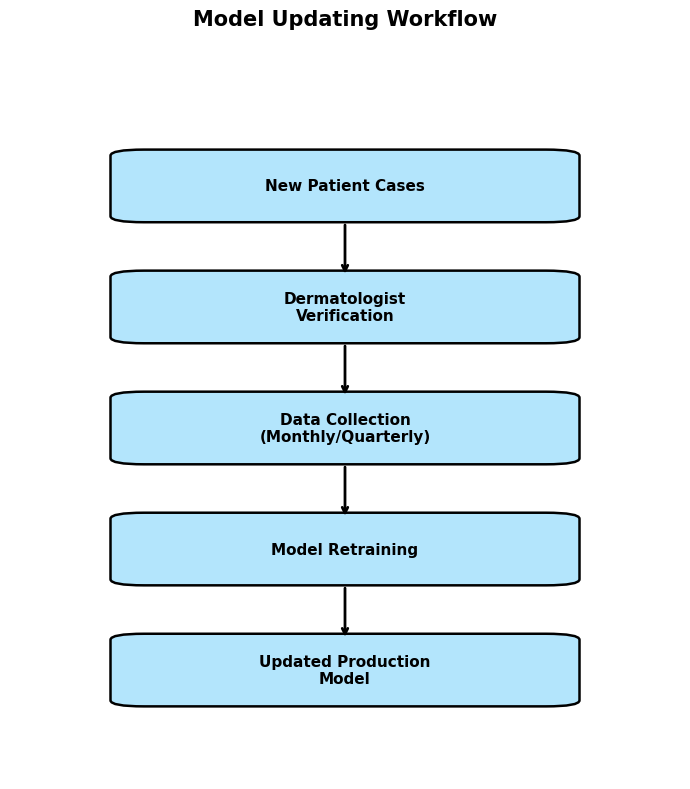

In [4]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

# Workflow steps
steps = [
    "New Patient Cases",
    "Dermatologist\nVerification",
    "Data Collection\n(Monthly/Quarterly)",
    "Model Retraining",
    "Updated Production\nModel"
]

# Create figure
fig, ax = plt.subplots(figsize=(7, 8))
ax.set_xlim(0, 1)
ax.set_ylim(0, len(steps) + 1)
ax.axis("off")

# Draw flowchart
for i, step in enumerate(steps):
    y = len(steps) - i

    # Draw rounded box
    box = FancyBboxPatch(
        (0.2, y - 0.35),      # x, y
        0.6,                  # width
        0.5,                  # height
        boxstyle="round,pad=0.05",
        facecolor="#B3E5FC",
        edgecolor="black",
        linewidth=1.8
    )
    ax.add_patch(box)

    # Add text
    ax.text(
        0.5,
        y - 0.1,
        step,
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold"
    )

    # Draw arrow
    if i < len(steps) - 1:
        ax.annotate(
            "",
            xy=(0.5, y - 0.40),
            xytext=(0.5, y - 0.85),
            arrowprops=dict(
                arrowstyle="<-",
                lw=2,
                color="black"
            )
        )

# Title
plt.title(
    "Model Updating Workflow",
    fontsize=15,
    fontweight="bold",
    pad=20
)

plt.tight_layout()
plt.show()

**The disease patterns do not change rapidly**

Skin diseases generally do not change their biological characteristics every day. Therefore, continuous model updates are not necessary.
A practical approach could be:
- Monthly retraining for frequently changing environments 
- Quarterly or yearly retraining for stable clinical settings

**Dataset size is small**

The given dataset contains:
- 366 patient records 
- 34 features 
- 6 disease classes 

Online learning is usually beneficial when:
- Data arrives continuously 
- Dataset is extremely large 
- Patterns change rapidly

For this project, online learning may introduce unnecessary risks because a small number of incorrect new samples could negatively affect the model.

**Better regulatory control**

Healthcare AI systems require:
- Traceability 
- Model versioning 
- Performance monitoring 
- Validation before deployment 
Batch learning provides better control because every model update can be tested before release.

**Comparison: Batch Learning vs Online Learning for This Project**

| **Criteria**                   | **Batch Learning**       | **Online Learning**    |
| ------------------------------ | ------------------------ | ---------------------- |
| Training method                | Periodic retraining      | Continuous updating    |
| Suitable for medical diagnosis | Yes                      | Limited                |
| Data requirement               | Historical verified data | Continuous data stream |
| Control over updates           | High                     | Low                    |
| Risk of incorrect updates      | Low                      | Higher                 |
| Regulatory compliance          | Easier                   | More difficult         |
| Suitable for current dataset   | Yes                      | No                     |

Recommended Production Architecture
For this project, the deployment architecture can be:

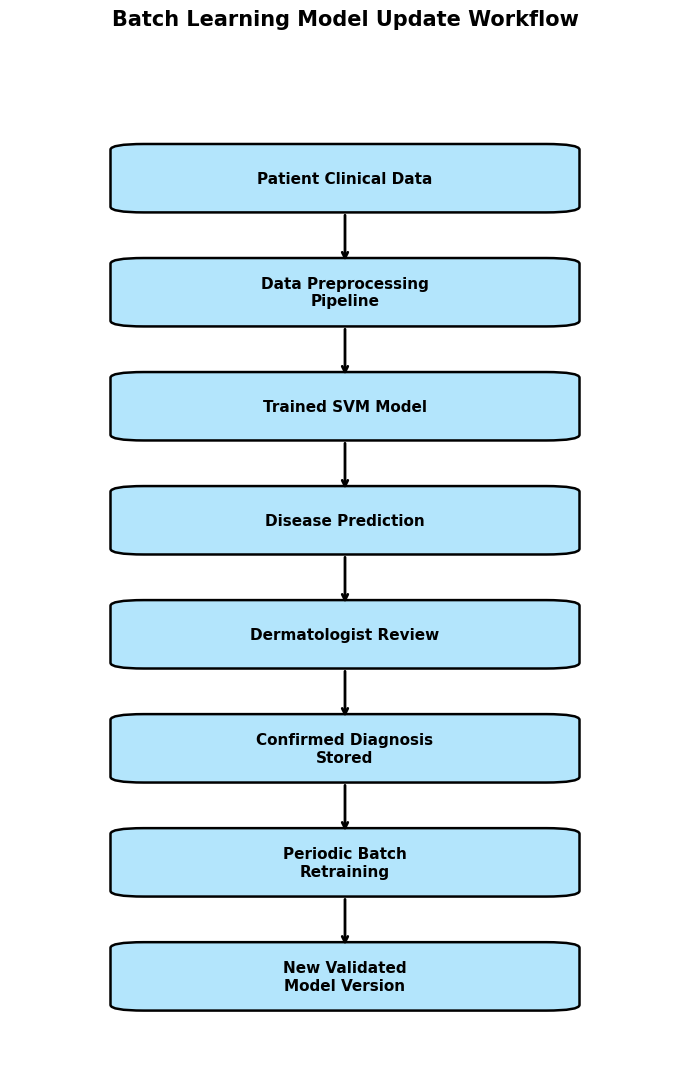

In [5]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

# Workflow steps
steps = [
    "Patient Clinical Data",
    "Data Preprocessing\nPipeline",
    "Trained SVM Model",
    "Disease Prediction",
    "Dermatologist Review",
    "Confirmed Diagnosis\nStored",
    "Periodic Batch\nRetraining",
    "New Validated\nModel Version"
]

# Create figure
fig, ax = plt.subplots(figsize=(7, 11))
ax.set_xlim(0, 1)
ax.set_ylim(0, len(steps) + 1)
ax.axis("off")

# Draw boxes and arrows
for i, step in enumerate(steps):
    y = len(steps) - i

    # Rounded rectangle
    box = FancyBboxPatch(
        (0.2, y - 0.35),      # x, y
        0.6,                  # width
        0.5,                  # height
        boxstyle="round,pad=0.05",
        edgecolor="black",
        facecolor="#B3E5FC",
        linewidth=1.8
    )
    ax.add_patch(box)

    # Text inside the box
    ax.text(
        0.5,
        y - 0.1,
        step,
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold"
    )

    # Arrow
    if i < len(steps) - 1:
        ax.annotate(
            "",
            xy=(0.5, y - 0.40),
            xytext=(0.5, y - 0.85),
            arrowprops=dict(
                arrowstyle="<-",
                lw=2,
                color="black"
            )
        )

# Title
plt.title(
    "Batch Learning Model Update Workflow",
    fontsize=15,
    fontweight="bold",
    pad=20
)

plt.tight_layout()
plt.show()

**Strategy for Production Deployment**

For production deployment of the dermatology disease classification system, batch learning is considered more appropriate than online learning.
The developed model should be deployed using a periodic retraining strategy, where newly collected and dermatologist-validated patient records are accumulated over time and used to retrain the model at scheduled intervals.

Batch learning is preferred because healthcare data requires careful validation before being introduced into the training process. Continuous updates through online learning may introduce errors if newly collected patient records contain incorrect labels or noisy information.

Additionally, dermatological disease patterns are relatively stable and do not require real-time model updates. Therefore, periodic batch retraining provides better control, reliability, and compliance with healthcare requirements.

A practical deployment approach would involve monitoring model performance, collecting verified clinical cases, retraining the model periodically, and validating the updated model before replacing the existing production version.

**Conclusion** Choose Batch Learning with periodic retraining as the production strategy. It is the safer and more realistic approach for a healthcare machine learning system.


Step 1: Save the Trained Model

Step 2: Create a Prediction API
A common production approach is to create an API using Python frameworks.
FastAPI is commonly preferred for ML deployment because it is fast and provides automatic API documentation.

Step 3: Create a User Interface
A doctor-friendly interface can be developed using:
Advantages:
- Very easy deployment 
- No frontend coding required 
- Suitable for ML demonstrations

Step 4: Containerize the Application
For professional deployment, package the application using Docker.
Architecture:

Docker Container
├── FastAPI Application
├── ML Model
├── Preprocessing Pipeline
├── Dependencies
└── Prediction Service



Step 5: Deploy on Cloud

Possible deployment platforms:
Beginner-friendly
- Streamlit Community Cloud 
- Render official website 
Production-level
- Amazon Web Services (AWS) 
- Microsoft Azure 
- Google Cloud Platform

A healthcare organization would typically use:


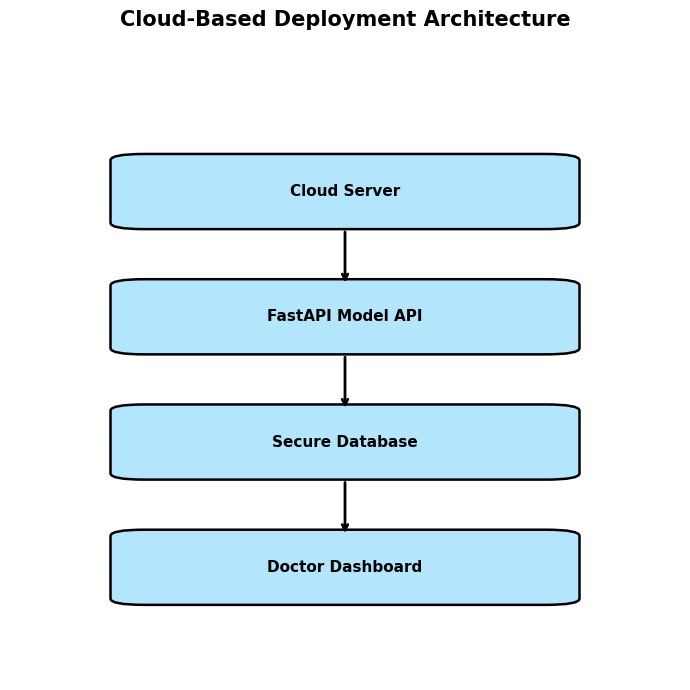

In [6]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

# Workflow steps
steps = [
    "Cloud Server",
    "FastAPI Model API",
    "Secure Database",
    "Doctor Dashboard"
]

# Create figure
fig, ax = plt.subplots(figsize=(7, 7))
ax.set_xlim(0, 1)
ax.set_ylim(0, len(steps) + 1)
ax.axis("off")

# Draw boxes and arrows
for i, step in enumerate(steps):
    y = len(steps) - i

    # Draw rounded rectangle
    box = FancyBboxPatch(
        (0.2, y - 0.35),      # x, y
        0.6,                  # width
        0.5,                  # height
        boxstyle="round,pad=0.05",
        edgecolor="black",
        facecolor="#B3E5FC",
        linewidth=1.8
    )
    ax.add_patch(box)

    # Add text
    ax.text(
        0.5,
        y - 0.1,
        step,
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold"
    )

    # Draw arrow
    if i < len(steps) - 1:
        ax.annotate(
            "",
            xy=(0.5, y - 0.40),
            xytext=(0.5, y - 0.85),
            arrowprops=dict(
                arrowstyle="<-",
                lw=2,
                color="black"
            )
        )

# Title
plt.title(
    "Cloud-Based Deployment Architecture",
    fontsize=15,
    fontweight="bold",
    pad=20
)

plt.tight_layout()
plt.show()

Step 6: Monitor the Model After Deployment

After deployment, monitor:
Model Performance
Track:
- Accuracy 
- Recall 
- False negatives
- Prediction confidence

Data Drift
Check whether new patient data differs from training data.

Retraining Strategy

Use batch learning:

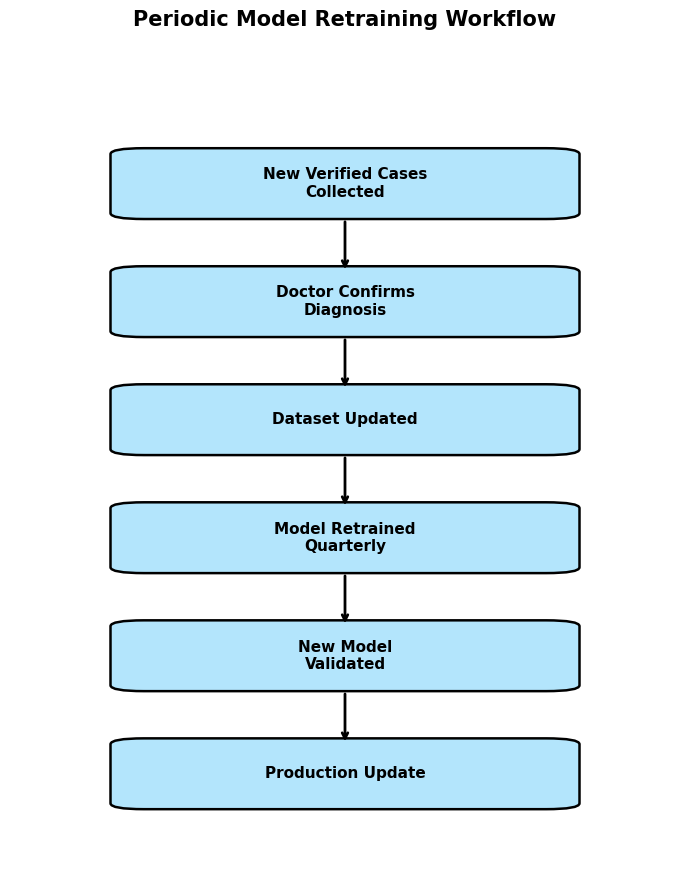

In [7]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

# Workflow steps
steps = [
    "New Verified Cases\nCollected",
    "Doctor Confirms\nDiagnosis",
    "Dataset Updated",
    "Model Retrained\nQuarterly",
    "New Model\nValidated",
    "Production Update"
]

# Create figure
fig, ax = plt.subplots(figsize=(7, 9))
ax.set_xlim(0, 1)
ax.set_ylim(0, len(steps) + 1)
ax.axis("off")

# Draw boxes and arrows
for i, step in enumerate(steps):
    y = len(steps) - i

    # Rounded rectangle
    box = FancyBboxPatch(
        (0.2, y - 0.35),      # x, y
        0.6,                  # width
        0.5,                  # height
        boxstyle="round,pad=0.05",
        facecolor="#B3E5FC",
        edgecolor="black",
        linewidth=1.8
    )
    ax.add_patch(box)

    # Box text
    ax.text(
        0.5,
        y - 0.1,
        step,
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold"
    )

    # Arrow to next box
    if i < len(steps) - 1:
        ax.annotate(
            "",
            xy=(0.5, y - 0.40),
            xytext=(0.5, y - 0.85),
            arrowprops=dict(
                arrowstyle="<-",
                lw=2,
                color="black"
            )
        )

# Title
plt.title(
    "Periodic Model Retraining Workflow",
    fontsize=15,
    fontweight="bold",
    pad=20
)

plt.tight_layout()
plt.show()

**Recommended Deployment Stack for this Project**

| **Component**     | **Recommended Technology**           |
| ----------------- | ------------------------------------ |
| Model             | SVM with RBF Kernel                  |
| Model Storage     | Joblib                               |
| Backend API       | FastAPI                              |
| Frontend          | Streamlit                            |
| Database          | PostgreSQL / MongoDB                 |
| Container         | Docker                               |
| Deployment        | AWS / Azure / Render                 |
| Learning Strategy | Batch Learning                       |
| Retraining        | Periodic validation-based retraining |


#### **Final Conclusion**

This project successfully developed and evaluated machine learning models for the multiclass classification of dermatological diseases using clinical and histopathological attributes.

During data preprocessing, missing values in the Age attribute were handled using both Median Imputation and K-Nearest Neighbour (KNN) Imputation. Experimental results showed that both approaches produced nearly identical predictive performance. Considering its simplicity, computational efficiency, and comparable accuracy, Median Imputation was selected as the preferred preprocessing technique.

Seven machine learning algorithms—Logistic Regression, Random Forest, Decision Tree, K-Nearest Neighbour, Support Vector Machine, XGBoost, and Naive Bayes—were trained and evaluated using Accuracy, Precision, Recall, F1-score, and ROC-AUC.

Among all evaluated models, the Support Vector Machine (SVM) achieved the best overall performance with an accuracy of 97.30% and a ROC-AUC score of 0.9981. The model demonstrated excellent precision, recall, and F1-score across all six disease classes, making it the most suitable candidate for deployment as a clinical decision support system.

The comparative analysis also showed that more complex imputation techniques did not significantly improve predictive performance over Median Imputation. This finding suggests that simpler preprocessing methods can be sufficient when dealing with limited missing values.

Overall, the results demonstrate that machine learning can effectively assist dermatologists by providing fast, consistent, and accurate predictions. While these models are not intended to replace clinical expertise, they can significantly enhance early diagnosis, reduce diagnostic variability, and support informed clinical decision-making.

#### **References**

1. Pedregosa, F., Varoquaux, G., Gramfort, A., et al. (2011). Scikit-learn: Machine Learning in Python. Journal of Machine Learning Research, 12, 2825–2830

2. XGBOOST - https://www.geeksforgeeks.org/machine-learning/xgboost

3. Cortes, C., & Vapnik, V. (1995). Support-Vector Networks. Machine Learning, 20(3), 273–297.

4. Géron, A. (2022). Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow (3rd ed.). O'Reilly Media.

5. Matplotlib - https://matplotlib.org/stable/tutorials/index

6. FancyBboxPatch - https://matplotlib.org/stable/api/_as_gen/matplotlib.patches.FancyBboxPatch.html
